# **비정형 데이터 처리 Final Term Project**

### **한국 상장기업 사업보고서의 ESG 관련 표현이 KCGS ESG 등급과 어떤 연관성을 보이는지 검증**

**3조**: 202231193 김혜성 · 202136006 이동원 · 202431626 김지우 · 202431928 신지영  

## **연구 질문**

> 사업보고서에서 뽑은 ESG 어휘의 강도가 KCGS ESG 등급과 통계적으로 연관되는가?  
> 그 연관을 그냥 길게 쓴 것(공시 장황함, cheap-talk)과 어떻게 구분하는가?  
→ 등급을 맞히는 것이 아닌 공시 언어와 외부 평가 사이의 패턴을 데이터로 확인

## **목차**

| 단계 | 내용 |
|---|---|
| 0 | 환경 셋업 |
| 1 | 데이터 수집 (381 firm-year) |
| 2 | 전처리 — 형태소 분석기 · seed 보호 · 불용어 |
| 3 | Feature 생성 — TF-IDF · FastText · 기준문장 Cosine |
| 4 | Validity 검증 — Spearman 순위상관 · Mann-Whitney (분량 효과 확인) |
| 5 | 회귀 3종 — OLS · Ordered · Binary + 재무통제 (G 신호만 견고) |
| 6 | 알파 분석 — 말–실행 격차(Talk–Walk Gap) 기업 유형 진단 |
| 7 | 종합 결론 — 발견 · 시사점 · 한계 |

In [1]:
"""
0. 환경 셋업
- 라이브러리 import
- 경로 설정 및 폴더 생성
- API key 로드 (환경변수)
- 시드 고정 (재현성)
- 라이브러리 버전 출력
"""
import os, re, sys, json, html, time, pickle, requests, warnings, zipfile
from io import BytesIO
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
from dotenv import load_dotenv

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

# --- 1) API key ---
load_dotenv()
API_KEY = os.getenv("OPENDART_API_KEY") or os.getenv("DART_API_KEY")
assert API_KEY is not None, (
    "OPENDART_API_KEY가 .env에 없습니다. "
    "프로젝트 루트에 .env 파일을 만들고 'OPENDART_API_KEY=...'를 추가하세요."
)
print(f"[ENV] API_KEY 로드 OK (앞 4자: {API_KEY[:4]}...)")

# --- 2) 경로 설정 ---
DATA_DIR   = "data"
OUTPUT_DIR = "outputs"
CORPUS_DIR = os.path.join(OUTPUT_DIR, "corpus")
ZIPS_DIR   = os.path.join(OUTPUT_DIR, "doc_zips")
SEED       = 42

for d in [OUTPUT_DIR, CORPUS_DIR, ZIPS_DIR]:
    os.makedirs(d, exist_ok=True)

master_csv = os.path.join(DATA_DIR, "company_master.csv")
assert os.path.exists(master_csv), "data/company_master.csv 없음"

print(f"\n[PATH]")
print(f"  DATA_DIR   : {DATA_DIR}/")
print(f"  OUTPUT_DIR : {OUTPUT_DIR}/")
print(f"  CORPUS_DIR : {CORPUS_DIR}/")
print(f"  ZIPS_DIR   : {ZIPS_DIR}/")
print(f"  master_csv : {master_csv} ✓")

# --- 3) 시드 고정 ---
np.random.seed(SEED)
print(f"\n[SEED] {SEED}")

# --- 4) 버전 출력 ---
print(f"\n[LIB VERSIONS]")
print(f"  python   : {sys.version.split()[0]}")
print(f"  pandas   : {pd.__version__}")
print(f"  numpy    : {np.__version__}")
print(f"  requests : {requests.__version__}")

# --- 5) outputs/ 현황 ---
existing = os.listdir(OUTPUT_DIR)
print(f"\n[OUTPUTS 현황] {len(existing)}개 파일/폴더")
if existing:
    for f in sorted(existing)[:10]:
        print(f"  - {f}")
    print(f"  (빈 환경부터 시작하려면 outputs/ 를 비우세요)")
else:
    print(f"  ✓ 비어있음")

[ENV] API_KEY 로드 OK (앞 4자: 0081...)

[PATH]
  DATA_DIR   : data/
  OUTPUT_DIR : outputs/
  CORPUS_DIR : outputs\corpus/
  ZIPS_DIR   : outputs\doc_zips/
  master_csv : data\company_master.csv ✓

[SEED] 42

[LIB VERSIONS]
  python   : 3.12.13
  pandas   : 3.0.1
  numpy    : 2.4.2
  requests : 2.32.5

[OUTPUTS 현황] 30개 파일/폴더
  - analysis_panel.csv
  - cheaptalk_evidence_matrix.csv
  - collection_meta.csv
  - corpCode.xml
  - corpus
  - dense_cosine.csv
  - doc_zips
  - expanded_review_examples.csv
  - fasttext_esg.model
  - fasttext_esg.model.wv.vectors_ngrams.npy
  (빈 환경부터 시작하려면 outputs/ 를 비우세요)


In [2]:
"""
[시각화 공용 셋업] matplotlib + 한글 폰트 자동 감지 (Windows/Mac/Linux)
- 그래프 한글 깨짐 방지. 이 셀을 시각화 셀들보다 먼저 1회 실행.
"""
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import platform

def _set_korean_font():
    sysname = platform.system()
    # 우선순위 후보 (OS별)
    candidates = {
        "Darwin":  ["AppleGothic", "Apple SD Gothic Neo", "NanumGothic"],   # macOS
        "Windows": ["Malgun Gothic", "맑은 고딕", "NanumGothic"],
        "Linux":   ["NanumGothic", "NanumBarunGothic", "UnDotum", "DejaVu Sans"],
    }.get(platform.system(), ["NanumGothic", "DejaVu Sans"])
    installed = {f.name for f in fm.fontManager.ttflist}
    for name in candidates:
        if name in installed:
            plt.rcParams["font.family"] = name
            return name
    # 후보가 모두 없으면 시스템에서 'Gothic'/'Nanum' 포함 폰트 탐색
    for f in fm.fontManager.ttflist:
        if any(k in f.name for k in ["Gothic", "Nanum", "Malgun", "Apple"]):
            plt.rcParams["font.family"] = f.name
            return f.name
    return None

_font = _set_korean_font()
plt.rcParams["axes.unicode_minus"] = False   # 마이너스 부호 깨짐 방지
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.bbox"] = "tight"

# 색상 팔레트 (E=초록, S=주황, G=파랑 — 본문 전체 일관)
ESG_COLORS = {"E": "#2e8b57", "S": "#e08a1e", "G": "#2f6fb0"}
NEUTRAL, ACCENT, MUTE = "#444444", "#c0392b", "#b0b0b0"

print(f"[시각화 셋업] OS={platform.system()} | 한글폰트 = {_font or '미발견(영문 폰트로 표시될 수 있음)'}")
if _font is None:
    print("  ⚠ 한글 폰트를 못 찾았습니다. 그래프 한글이 깨지면 NanumGothic 등을 설치하세요.")


[시각화 셋업] OS=Windows | 한글폰트 = Malgun Gothic


---

# **1. 데이터 수집 (381 firm-year)**

## **1-1. stock_code · timing 설계**

### **Decision Box ① — stock_code 정규화**

- DART API는 6자리 문자열 stock_code 요구
- CSV를 정수로 읽으면 `005930 → 5930` — corp_code 매핑 실패로 수집 불가

→ CSV 로드 직후 `dtype={"stock_code": str}` + `.str.zfill(6)` 강제 적용

### **Decision Box ② — timing 정렬**

가이드는 timing을 **`esg_year = fiscal_year + 1`** 로 규정한다(KCGS 평가연도 t ↔ 직전 회계연도 t−1 사업보고서). 본 분석은 이 정의를 따른다.

**① 보고서 선택 — `fiscal_year+1`년 공시 사업보고서**

- 가이드 규칙대로 각 firm-year의 텍스트는 calendar `fiscal_year+1`년에 공시된 정규 사업보고서에서 추출한다(`search_year = fiscal_year + 1`).
- **12월 결산법인(대다수)**: 대상기간 `fiscal_year`.12 보고서.
- **비12월 결산법인**(`001720` 3월말 · `001080` 6월말, 6 firm-year): 동일 규칙 아래 대상기간 `fiscal_year+1`.03/.06 보고서가 선택된다(달력 `fiscal_year`와 가장 많이 겹치는 연간보고서, 예: 001720 FY2022 → 2022.04~2023.03 = 12개월 중 9개월이 2022년). 1-5 lineage 검증에서 "대상기간 연도 불일치 6건"으로 자동 검출되어 의도된 동작임을 확인했다.

**② 등급 연결 — 가이드 정의와 제공 CSV의 불일치 처리 (중요
- 본 과제에 주어진 `company_master.csv`의 `esg_year` 컬럼은 381행 전체에서 `fiscal_year`와 동일값이다(`esg_year − fiscal_year = 0`. CSV가 제공하는 등급은 행 단위로 `fiscal_year`에 직접 매여 있고, 가이드가 말한 "`fiscal_year+1` 평가연도 등급"을 별도 컬럼으로 제공하지 않는다.
- **처리**: 가이드의 보고서 선택 규칙(`fiscal_year+1` 공시분)은 그대로 따르되, 등급은 제공된 CSV가 각 `fiscal_year` 행에 부여한 등급을 신뢰해 `[stock_code, fiscal_year]`로 결합한다. CSV가 가이드 정의대로 `fiscal_year+1` 평가 등급을 담고 있다면 이 결합은 가이드와 정확히 일치하고, CSV의 `esg_year` 라벨이 실제 평가 시점과 다르다면 등급-텍스트가 한 해 어긋날 수 있다.

### **Decision Box ③ — corp_code 매핑 방식**

- 전체 상장기업 stock_code ↔ corp_code 매핑을 1회 호출로 확보
- Checkpoint 패턴으로 재실행 시 다운로드 skip

In [3]:
"""
1-1. company_master.csv 로드 + 식별자 진단 + corp_code 매핑

Decision Box ①②③ 구현
- stock_code zfill(6) 강제
- timing 진단 (esg_year vs fiscal_year)
- corpCode.xml로 corp_code 매핑
"""
import xml.etree.ElementTree as ET

# ── company_master 로드 ───────────────────────────────────────────
cm = pd.read_csv(master_csv, dtype={"stock_code": str})
cm["stock_code"] = cm["stock_code"].str.zfill(6)

print("[company_master.csv 로드]")
print(f"  shape  : {cm.shape}")
print(f"  columns: {list(cm.columns)}")

# ── 식별자 진단 ─────────────────────────────────────────────────────
n_name  = cm["company_name"].nunique()
n_stock = cm["stock_code"].nunique()
print(f"\n[식별자 진단]")
print(f"  전체 행수           : {len(cm)}")
print(f"  unique company_name : {n_name}")
print(f"  unique stock_code   : {n_stock}")
print(f"  이름-코드 차이      : {n_name - n_stock}개 → stock_code × fiscal_year 키 사용")

# ── stock_code 길이 검증 (Decision Box ①) ────────────────────────
assert all(cm["stock_code"].str.len() == 6), "zfill 실패"
print(f"\n[stock_code zfill(6) 검증] 전행 6자리 ✓")

# ── fiscal_year 분포 ──────────────────────────────────────────────
print(f"\n[fiscal_year 분포]")
print(cm["fiscal_year"].value_counts().sort_index().to_string())

# ── timing 진단 (Decision Box ②) ─────────────────────────────────
print(f"\n[timing 진단]")
diff = (cm["esg_year"] - cm["fiscal_year"]).value_counts().sort_index()
print(f"  (esg_year - fiscal_year) 분포:")
print(diff.to_string())
cm["search_year"] = cm["fiscal_year"] + 1
print(f"\n  → search_year = fiscal_year + 1 적용")
print(cm[["fiscal_year","esg_year","search_year"]].drop_duplicates()
      .sort_values("fiscal_year").to_string(index=False))

# ── ESG 등급 컬럼 확인 ────────────────────────────────────────────
grade_cols = [c for c in cm.columns if "grade" in c.lower()]
print(f"\n[ESG 등급 컬럼]")
for col in grade_cols:
    print(f"  {col}: {sorted(cm[col].dropna().unique().tolist())}")

# ── corp_code 매핑 (Decision Box ③) ──────────────────────────────
print(f"\n[corp_code 결측 현황]")
n_missing = cm["corp_code"].isna().sum()
print(f"  결측: {n_missing} / {len(cm)}")

corpcode_path = os.path.join(OUTPUT_DIR, "corpCode.xml")
if os.path.exists(corpcode_path):
    print(f"\n  [Checkpoint] corpCode.xml 존재 — 다운로드 skip")
else:
    print(f"\n  [다운로드 시작]")
    res = requests.get(
        "https://opendart.fss.or.kr/api/corpCode.xml",
        params={"crtfc_key": API_KEY}, timeout=60,
    )
    res.raise_for_status()
    with zipfile.ZipFile(BytesIO(res.content)) as zf:
        xml_name  = [n for n in zf.namelist() if n.endswith(".xml")][0]
        xml_bytes = zf.read(xml_name)
    with open(corpcode_path, "wb") as f:
        f.write(xml_bytes)
    print(f"  저장: {corpcode_path} ({len(xml_bytes)/1e6:.1f}MB)")

tree   = ET.parse(corpcode_path)
root   = tree.getroot()
listed = pd.DataFrame([
    {"corp_code":  (c.findtext("corp_code")  or "").strip(),
     "stock_code": (c.findtext("stock_code") or "").strip()}
    for c in root.findall(".//list")
])
listed = listed[listed["stock_code"].str.len() > 0].copy()
listed["stock_code"] = listed["stock_code"].str.zfill(6)
stock_to_corp = dict(zip(listed["stock_code"], listed["corp_code"]))

cm["corp_code"] = cm["stock_code"].map(stock_to_corp)
cm["corp_code"] = (cm["corp_code"].fillna("").str.zfill(8)
                   .replace("00000000", ""))

n_mapped = (cm["corp_code"].str.len() == 8).sum()
print(f"\n[corp_code 매핑 결과]")
print(f"  성공: {n_mapped} / {len(cm)}")
if n_mapped < len(cm):
    fail = cm[cm["corp_code"].str.len() != 8]
    print(f"  실패 행:")
    print(fail[["company_name","stock_code","fiscal_year"]].drop_duplicates().to_string(index=False))

# ── Sanity check ──────────────────────────────────────────────────
sam = cm[cm["stock_code"] == "005930"][["company_name","stock_code","corp_code"]].drop_duplicates()
print(f"\n[Sanity check — 삼성전자]")
print(sam.to_string(index=False))
print(f"  → 정답 corp_code: 00126380")

META_INPUT_DF = cm.copy()
print(f"\n[META_INPUT_DF 저장] shape={META_INPUT_DF.shape}")

[company_master.csv 로드]
  shape  : (381, 19)
  columns: ['team_id', 'role', 'company_name', 'corp_code', 'stock_code', 'industry', 'fiscal_year', 'report_code', 'rcept_no', 'esg_source', 'esg_grade', 'e_grade', 's_grade', 'g_grade', 'esg_year', 'is_required', 'replacement_of', 'replacement_reason', 'notes']

[식별자 진단]
  전체 행수           : 381
  unique company_name : 133
  unique stock_code   : 127
  이름-코드 차이      : 6개 → stock_code × fiscal_year 키 사용

[stock_code zfill(6) 검증] 전행 6자리 ✓

[fiscal_year 분포]
fiscal_year
2022    127
2023    127
2024    127

[timing 진단]
  (esg_year - fiscal_year) 분포:
0    381

  → search_year = fiscal_year + 1 적용
 fiscal_year  esg_year  search_year
        2022      2022         2023
        2023      2023         2024
        2024      2024         2025

[ESG 등급 컬럼]
  esg_grade: ['A', 'A+', 'B', 'B+', 'C', 'D']
  e_grade: ['A', 'A+', 'B', 'B+', 'C', 'D']
  s_grade: ['A', 'A+', 'B', 'B+', 'C', 'D']
  g_grade: ['A', 'A+', 'B', 'B+', 'C', 'D']

[corp_code 결측 현황]
  

**company_master.csv 진단 + corp_code 매핑 완료**

| 항목 | 값 | 판단 |
|---|---|---|
| 전체 행수 | 381 | 127개 × 3년 정상 |
| unique company_name | 133 | stock_code(127)보다 6개 많음 — 사명변경/분할 존재 확인 |
| unique stock_code | 127 | join 키로 사용 |
| stock_code 길이 | 전행 6자리 | zfill(6) 정상 작동 |
| esg_year − fiscal_year | 0 (381행 전체) | CSV는 동일값 → search_year = fiscal_year + 1 적용 |
| corp_code 매핑 | 381 / 381 성공 | corpCode.xml Checkpoint 활용 |

- ESG 등급 4개 차원(esg/e/s/g) 모두 D·C·B·B+·A·A+ 6개 등급 — 표본 최고 등급 A+
- CSV의 `corp_code` 컬럼은 381행 전체 결측 (의도적 공란) → corpCode.xml 매핑으로 정상 확보
- 삼성전자 sanity check 통과 (`005930 → 00126380`)

## **1-2. 수집 함수 설계**

DART 사업보고서 수집은 세 단계 함수로 구성한다.

### **Decision Box ④ — 사업보고서 검색 전략**

- `"사업보고서"` 포함이면 매칭, 아래 키워드 포함 시 제외
  - `"반기"` · `"분기"` — 반기·분기보고서 혼입 방지
  - `"연장"` · `"신고서"` — 제출기한 연장신고서 혼입 방지
- 정정공시 우선순위: 원본(0) > `[기재정정]`(1) > `[첨부정정]`(2), 동순위는 `rcept_dt` 오름차순

### **Decision Box ⑤ — 본 보고서 XML 선택**

- DART ZIP 내부에는 본 보고서 외 첨부서류 XML이 함께 들어있음
- `{rcept_no}.xml` 이름이 정확히 일치하면 본 보고서가 확실
- `{rcept_no}.xml` → 언더스코어 없는 XML → 가장 큰 XML

### **Decision Box ⑥ — ESG 섹션 추출 범위**

| 섹션 | 내용 | ESG 관련성 |
|---|---|---|
| II. 사업의 내용 | 주요 사업·환경·사회 활동 서술 | E·S 핵심 |
| IV. 이사의 경영진단 및 분석의견 | 경영진 ESG 방향성·성과 서술 | E·S·G 통합 |
| VI. 이사회 등 회사의 기관에 관한 사항 | 이사회 구성·감사위원회·내부통제 | G 핵심 |


**섹션 경계 탐지 방식**

- 대분류 로마숫자 TITLE(I·II·III…)만 경계로 사용 → 소제목은 경계 제외

In [4]:
"""
1-2. 수집 함수 4종 정의

find_business_report_v2 : 사업보고서 rcept_no 검색 (Decision Box ④)
download_document_xml   : 원문 ZIP → 본 보고서 XML (Decision Box ⑤)
extract_esg_sections    : XML → II/IV/VI 섹션 텍스트 (Decision Box ⑥)
collect_one_firm_year   : 위 3종 묶음
"""

# ── 함수 1 ───────────────────────────────────────────────────────
def find_business_report_v2(corp_code, fiscal_year, api_key, verbose=False):
    """
    fiscal_year+1년 공시 사업보고서 검색.
    반기·분기·연장·신고서 제외, 정정 우선순위 적용.
    """
    search_year = fiscal_year + 1
    res = requests.get(
        "https://opendart.fss.or.kr/api/list.json",
        params={
            "crtfc_key":        api_key,
            "corp_code":        corp_code,
            "bgn_de":           f"{search_year}0101",
            "end_de":           f"{search_year}1231",
            "pblntf_detail_ty": "A001",
            "page_count":       "100",
        },
        timeout=20,
    )
    payload = res.json()
    if payload.get("status") != "000":
        if verbose:
            print(f"  status={payload.get('status')}: {payload.get('message')}")
        return None

    candidates = [
        r for r in payload.get("list", [])
        if "사업보고서" in r.get("report_nm", "")
        and "반기"   not in r.get("report_nm", "")
        and "분기"   not in r.get("report_nm", "")
        and "연장"   not in r.get("report_nm", "")
        and "신고서" not in r.get("report_nm", "")
    ]
    if not candidates:
        return None

    def priority(name):
        if "[첨부정정]" in name: return 2
        if "[기재정정]" in name: return 1
        return 0

    candidates.sort(key=lambda r: (priority(r["report_nm"]), r["rcept_dt"]))
    c = candidates[0]
    return {
        "rcept_no":     c["rcept_no"],
        "rcept_dt":     c["rcept_dt"],
        "report_nm":    c["report_nm"],
        "n_candidates": len(candidates),
    }


# ── 함수 2 ───────────────────────────────────────────────────────
def download_document_xml(rcept_no, api_key, output_dir, verbose=False):
    """
    ZIP 내 본 보고서 XML 선택 우선순위 (Decision Box ⑤):
    1. {rcept_no}.xml 정확히 일치
    2. 언더스코어 없는 XML 첫 번째
    3. 가장 큰 XML
    """
    zip_path = os.path.join(output_dir, "doc_zips", f"doc_{rcept_no}.zip")
    os.makedirs(os.path.dirname(zip_path), exist_ok=True)

    if not os.path.exists(zip_path):
        res = requests.get(
            "https://opendart.fss.or.kr/api/document.xml",
            params={"crtfc_key": api_key, "rcept_no": rcept_no},
            timeout=60,
        )
        res.raise_for_status()
        if res.content[:2] != b"PK":
            raise ValueError(f"ZIP 아님: {res.content[:200]}")
        with open(zip_path, "wb") as f:
            f.write(res.content)

    with zipfile.ZipFile(zip_path) as zf:
        xml_names = [n for n in zf.namelist() if n.endswith(".xml")]
        if not xml_names:
            raise ValueError(f"ZIP 내 XML 없음: {zf.namelist()}")
        main = f"{rcept_no}.xml"
        if main in xml_names:
            chosen = main
        else:
            no_suffix = [n for n in xml_names if "_" not in n]
            chosen = no_suffix[0] if no_suffix else max(
                xml_names, key=lambda n: zf.getinfo(n).file_size
            )
        xml_bytes = zf.read(chosen)

    for enc in ("utf-8", "euc-kr", "cp949"):
        try:
            return xml_bytes.decode(enc), zip_path, chosen
        except UnicodeDecodeError:
            continue
    return xml_bytes.decode("utf-8", errors="ignore"), zip_path, chosen


# ── 함수 3 ───────────────────────────────────────────────────────
def extract_esg_sections(xml_text, verbose=False):
    """
    대상: II·IV·VI (Decision Box ⑥)
    경계: 대분류 로마숫자 TITLE만 사용 (소제목 제외 — 버그 수정)
    처리: TABLE 블록 제거 → P 태그 텍스트 추출 → 10자 미만 제거
    """
    ROMAN_PAT = re.compile(
        r"^(I{1,3}|IV|VI{0,3}|IX|X{0,3}(?:I{1,3}|IV|VI{0,3})?)[.\s]"
    )
    TARGET = {"II", "IV", "VI"}

    all_titles = [
        (m.start(), m.end(), re.sub(r"<[^>]+>", "", m.group(1)).strip())
        for m in re.finditer(r"<TITLE[^>]*>(.*?)</TITLE>", xml_text, re.DOTALL)
    ]
    roman_titles = [
        (s, e, t) for s, e, t in all_titles if ROMAN_PAT.match(t)
    ]

    results = {}
    for i, (start, end, text) in enumerate(roman_titles):
        roman_key = ROMAN_PAT.match(text).group(1)
        if roman_key not in TARGET:
            continue
        chunk_start = end
        chunk_end   = roman_titles[i+1][0] if i+1 < len(roman_titles) else len(xml_text)
        chunk = xml_text[chunk_start:chunk_end]
        chunk = re.sub(r"<TABLE[^>]*>.*?</TABLE>", " ", chunk, flags=re.DOTALL)
        paras = re.findall(r"<P[^>]*>(.*?)</P>", chunk, re.DOTALL)
        texts = [
            html.unescape(re.sub(r"<[^>]+>", "", p)).strip()
            for p in paras
            if len(html.unescape(re.sub(r"<[^>]+>", "", p)).strip()) >= 10
        ]
        if texts:
            results[roman_key] = "\n".join(texts)
    return results


# ── 함수 4 ───────────────────────────────────────────────────────
def collect_one_firm_year(row, api_key, output_dir, verbose=False):
    """단일 firm-year 수집 파이프라인."""
    stock_code  = row["stock_code"]
    corp_code   = row["corp_code"]
    fiscal_year = int(row["fiscal_year"])

    found = find_business_report_v2(corp_code, fiscal_year, api_key, verbose)
    if found is None:
        return {"status": "FAIL", "reason": "보고서_미발견",
                "stock_code": stock_code, "fiscal_year": fiscal_year}
    try:
        xml_text, zip_path, xml_name = download_document_xml(
            found["rcept_no"], api_key, output_dir, verbose
        )
    except Exception as e:
        return {"status": "FAIL", "reason": f"ZIP오류:{e}",
                "stock_code": stock_code, "fiscal_year": fiscal_year, **found}

    sections = extract_esg_sections(xml_text, verbose)
    if not sections:
        return {"status": "FAIL", "reason": "섹션_미추출",
                "stock_code": stock_code, "fiscal_year": fiscal_year, **found}

    combined = "\n\n".join(sections.values())
    return {
        "status":           "SUCCESS",
        "reason":           "",
        "stock_code":       stock_code,
        "fiscal_year":      fiscal_year,
        "rcept_no":         found["rcept_no"],
        "rcept_dt":         found["rcept_dt"],
        "report_nm":        found["report_nm"],
        "viewer_url":       f"https://dart.fss.or.kr/dsaf001/main.do?rcpNo={found['rcept_no']}",
        "text":             combined,
        "section_chars_II": len(sections.get("II", "")),
        "section_chars_IV": len(sections.get("IV", "")),
        "section_chars_VI": len(sections.get("VI", "")),
        "total_chars":      len(combined),
    }

print("[함수 정의 완료]")
print("  find_business_report_v2  ✓  (반기·분기·연장 제외, 정정 우선순위)")
print("  download_document_xml    ✓  (본 보고서 XML 우선순위 선택)")
print("  extract_esg_sections     ✓  (대분류 로마숫자 경계, TABLE 제거)")
print("  collect_one_firm_year    ✓  (3종 묶음, SUCCESS/FAIL 반환)")

[함수 정의 완료]
  find_business_report_v2  ✓  (반기·분기·연장 제외, 정정 우선순위)
  download_document_xml    ✓  (본 보고서 XML 우선순위 선택)
  extract_esg_sections     ✓  (대분류 로마숫자 경계, TABLE 제거)
  collect_one_firm_year    ✓  (3종 묶음, SUCCESS/FAIL 반환)


**수집 함수 4종 정의 완료**

| 함수 | 핵심 설계 결정 |
|---|---|
| `find_business_report_v2` | 반기·분기·연장·신고서 제외, 정정 우선순위(원본>기재>첨부) |
| `download_document_xml` | `{rcept_no}.xml` → 언더스코어 없는 XML → 가장 큰 XML 순 선택 |
| `extract_esg_sections` | 대분류 로마숫자 TITLE만 경계로 사용, TABLE 블록 제거, 10자 미만 제거 |
| `collect_one_firm_year` | 3종 묶음, 단계별 FAIL 사유 반환 |

## **1-3. 파일럿 수집 검증 — 무작위 10건**

전체 381건 수집 전 무작위 10개 기업-연도를 선정해 파이프라인을 검증한다. 다양한 업종·규모·연도를 포괄하기 위함이다.

**검증 항목**
- `collect_one_firm_year`가 10건 모두 올바른 `rcept_no`·`report_nm`을 반환하는가
- II·IV·VI 3개 섹션이 모두 0자 초과로 추출되는가 (hard assert — 1건이라도 실패 시 중단)
- `viewer_url` 표로 실제 DART 원문이 맞는 사업보고서·대상연도인지 사람이 직접 확인
- 대표 2건은 섹션 텍스트 앞 200자로 ESG 표현 포함 여부 확인

**재현성**: `random_state=SEED(42)` 고정으로 동일한 10건이 매번 선택

In [5]:
"""
1-3. 파일럿 수집 검증 — 무작위 10건
전체 381 수집(1-4) 전 다양한 기업으로 파이프라인 검증.
- 순수 무작위 10건 (seed 고정, 재현 가능)
- 각 건 collect_one_firm_year 실행
- 전건 SUCCESS + II·IV·VI 모두 0자 초과 = hard assert 통과
- viewer_url 표로 사람이 직접 원문 확인
"""

# ── 무작위 10건 추출 (재현 가능) ──────────────────────────────────
pilot = META_INPUT_DF.sample(n=10, random_state=SEED).reset_index(drop=True)

print(f"[파일럿 표본] 무작위 10건 (random_state={SEED})")
print(pilot[["company_name", "stock_code", "fiscal_year", "search_year"]]
      .to_string(index=False))

# ── 10건 수집 ─────────────────────────────────────────────────────
print(f"\n[수집 진행]")
pilot_rows = []
for _, row in pilot.iterrows():
    out = collect_one_firm_year(row, API_KEY, OUTPUT_DIR, verbose=False)
    pilot_rows.append({
        "company_name": row["company_name"],
        "stock_code":   row["stock_code"],
        "fiscal_year":  int(row["fiscal_year"]),
        "status":       out["status"],
        "rcept_no":     out.get("rcept_no", ""),
        "report_nm":    out.get("report_nm", ""),
        "rcept_dt":     out.get("rcept_dt", ""),
        "chars_II":     int(out.get("section_chars_II", 0) or 0),
        "chars_IV":     int(out.get("section_chars_IV", 0) or 0),
        "chars_VI":     int(out.get("section_chars_VI", 0) or 0),
        "viewer_url":   out.get("viewer_url", ""),
        "reason":       out.get("reason", "") or "",
    })
    mark = "✓" if out["status"] == "SUCCESS" else "✗"
    print(f"  {mark} {row['company_name']} FY{int(row['fiscal_year'])} → {out['status']}")

pilot_df = pd.DataFrame(pilot_rows)

# ── 섹션별 글자 수 표 ─────────────────────────────────────────────
print(f"\n{'='*60}")
print("[수집 결과 — 섹션별 글자 수]")
print(pilot_df[["company_name", "stock_code", "fiscal_year", "status",
                "report_nm", "chars_II", "chars_IV", "chars_VI"]]
      .to_string(index=False))

# ── viewer_url 표 (사람 직접 확인용) ──────────────────────────────
print(f"\n[viewer_url — 원문 직접 확인]")
for _, r in pilot_df.iterrows():
    print(f"  {r['company_name']} FY{r['fiscal_year']} | {r['report_nm']}")
    print(f"     {r['viewer_url']}")

# ── 대표 2건 텍스트 앞 200자 ──────────────────────────────────────
print(f"\n{'='*60}")
print("[대표 2건 — 섹션 텍스트 앞 200자 직접 확인]")
for _, r in pilot_df.head(2).iterrows():
    if r["status"] != "SUCCESS":
        continue
    xml_text, _, _ = download_document_xml(r["rcept_no"], API_KEY, OUTPUT_DIR, verbose=False)
    sections = extract_esg_sections(xml_text)
    print(f"\n  ── {r['company_name']} FY{r['fiscal_year']} ({r['report_nm']}) ──")
    for sec, label in [("II", "사업의 내용"), ("IV", "경영진단"), ("VI", "이사회")]:
        txt = sections.get(sec, "")
        print(f"   [{sec}. {label}] {len(txt):,}자")
        print(f"   {txt[:200]}...")

# ── hard assert ───────────────────────────────────────────────────
n_success = int((pilot_df["status"] == "SUCCESS").sum())
assert n_success == 10, f"파일럿 {10 - n_success}건 수집 실패 — 함수 점검 필요"
for sec in ["chars_II", "chars_IV", "chars_VI"]:
    assert (pilot_df[sec] > 0).all(), f"{sec} 0자 firm-year 존재 — 섹션 추출 점검 필요"
print(f"\n[Sanity Check 통과] ✓ 10/10 SUCCESS, 전 섹션 추출 — 전체 수집 진행 가능")

[파일럿 표본] 무작위 10건 (random_state=42)
company_name stock_code  fiscal_year  search_year
       SPC삼립     005610         2024         2025
        흥국화재     000540         2022         2023
    POSCO홀딩스     005490         2023         2024
       롯데케미칼     011170         2023         2024
        고려아연     010130         2022         2023
     삼성에스디에스     018260         2022         2023
      오리온홀딩스     001800         2023         2024
        백광산업     001340         2023         2024
      JW중외제약     001060         2022         2023
       삼성SDI     006400         2023         2024

[수집 진행]
  ✓ SPC삼립 FY2024 → SUCCESS
  ✓ 흥국화재 FY2022 → SUCCESS
  ✓ POSCO홀딩스 FY2023 → SUCCESS
  ✓ 롯데케미칼 FY2023 → SUCCESS
  ✓ 고려아연 FY2022 → SUCCESS
  ✓ 삼성에스디에스 FY2022 → SUCCESS
  ✓ 오리온홀딩스 FY2023 → SUCCESS
  ✓ 백광산업 FY2023 → SUCCESS
  ✓ JW중외제약 FY2022 → SUCCESS
  ✓ 삼성SDI FY2023 → SUCCESS

[수집 결과 — 섹션별 글자 수]
company_name stock_code  fiscal_year  status       report_nm  chars_II  chars_IV  chars_VI
       SPC삼립     0056

## **1-4. 전체 381 firm-year 수집**

### **수집 전략**

| 항목 | 결정 |
|---|---|
| Checkpoint | `collection_meta.csv` 존재 시 SUCCESS 행 skip, FAIL 행 재시도 |
| 실패 처리 | `reason` 컬럼에 사유 기록, corpus 미포함 |
| corpus 저장 | SUCCESS 행만 `outputs/corpus/{stock_code}_{fiscal_year}.json` |
| rate limit | 요청 간 `time.sleep(0.5)` 적용 |
| 저장 주기 | 매 20건마다 `collection_meta.csv` 중간 저장 |

### **FAIL 발생 시 처리 원칙**

- `보고서_미발견`: DART에 해당 연도 사업보고서 없음 (상장폐지·합병 등)
- `ZIP오류`: 원문 다운로드 실패 (DART 서버 오류 등)
- `섹션_미추출`: II·IV·VI 섹션 텍스트 추출 0건 (XML 구조 이상)

FAIL 행은 수집 완료 후 별도 진단해 재시도 가능 여부를 판단한다.

In [6]:
"""
1-4. 전체 381 firm-year 수집

Checkpoint 패턴:
- collection_meta.csv 존재 시 SUCCESS 행 skip
- FAIL 행은 재시도
- corpus JSON은 SUCCESS 행만 저장
- 실패 행은 reason 기록, corpus 미포함
"""

META_CSV = os.path.join(OUTPUT_DIR, "collection_meta.csv")

# ── Checkpoint 로드 ───────────────────────────────────────────────
if os.path.exists(META_CSV):
    done_meta = pd.read_csv(
        META_CSV, dtype={"stock_code": str, "corp_code": str}
    )
    done_meta["stock_code"]  = done_meta["stock_code"].str.zfill(6)
    done_meta["corp_code"]   = done_meta["corp_code"].fillna("").str.zfill(8).replace("00000000","")
    done_meta["fiscal_year"] = done_meta["fiscal_year"].astype(int)
    success_keys = set(zip(
        done_meta.loc[done_meta["status"]=="SUCCESS","stock_code"],
        done_meta.loc[done_meta["status"]=="SUCCESS","fiscal_year"],
    ))
    meta_records = done_meta.to_dict("records")
    print(f"[Checkpoint 로드] 기존 {len(done_meta)}행 (SUCCESS {len(success_keys)}개)")
else:
    success_keys = set()
    meta_records = []
    print(f"[Checkpoint 없음] 처음부터 수집")

# ── 전체 순회 ─────────────────────────────────────────────────────
rows    = META_INPUT_DF.to_dict("records")
n_total = len(rows)
n_skip = n_success = n_fail = 0

print(f"\n[수집 시작] 대상 {n_total}행\n")

for i, row in enumerate(rows, 1):
    key = (row["stock_code"], int(row["fiscal_year"]))

    if key in success_keys:
        n_skip += 1
        continue

    out             = collect_one_firm_year(row, API_KEY, OUTPUT_DIR, verbose=False)
    out["corp_code"] = row.get("corp_code", "")
    meta_records.append(out)

    if out["status"] == "SUCCESS":
        n_success += 1
        success_keys.add(key)
        corpus_path = os.path.join(
            CORPUS_DIR, f"{row['stock_code']}_{row['fiscal_year']}.json"
        )
        with open(corpus_path, "w", encoding="utf-8") as f:
            json.dump({
                "stock_code":       row["stock_code"],
                "fiscal_year":      int(row["fiscal_year"]),
                "rcept_no":         out["rcept_no"],
                "viewer_url":       out["viewer_url"],
                "text":             out["text"],
                "section_chars_II": out["section_chars_II"],
                "section_chars_IV": out["section_chars_IV"],
                "section_chars_VI": out["section_chars_VI"],
                "total_chars":      out["total_chars"],
            }, f, ensure_ascii=False)
    else:
        n_fail += 1

    if i % 10 == 0 or i == n_total:
        print(f"  [{i:3d}/{n_total}] {out['status']:7s} | "
              f"{row['stock_code']} FY{row['fiscal_year']} | "
              f"{out.get('reason') or out.get('total_chars',''):>10} | "
              f"성공 {n_success} 실패 {n_fail} skip {n_skip}")

    if i % 20 == 0 or i == n_total:
        pd.DataFrame(meta_records).to_csv(META_CSV, index=False, encoding="utf-8-sig")

    time.sleep(0.5)

# ── 최종 저장 ─────────────────────────────────────────────────────
META_DF = pd.DataFrame(meta_records)
META_DF["stock_code"] = META_DF["stock_code"].fillna("").str.zfill(6)
META_DF["corp_code"]  = META_DF["corp_code"].fillna("").str.zfill(8).replace("00000000","")
META_DF.to_csv(META_CSV, index=False, encoding="utf-8-sig")

# ── 수집 요약 ─────────────────────────────────────────────────────
status_counts = META_DF["status"].value_counts()
n_collected   = status_counts.get("SUCCESS", 0)
n_failed      = status_counts.get("FAIL", 0)

print(f"\n{'='*50}")
print(f"[수집 완료 요약]")
print(f"  전체 대상  : {n_total}")
print(f"  SUCCESS    : {n_collected}")
print(f"  FAIL       : {n_failed}")
print(f"  skip(기존) : {n_skip}")

print(f"\n[FAIL 행 목록]")
fail_df = META_DF[META_DF["status"]=="FAIL"][["stock_code","fiscal_year","reason"]]
if len(fail_df) > 0:
    print(fail_df.to_string(index=False))
else:
    print("  없음")

assert len(META_DF) <= 381
print(f"\n[collection_meta.csv 저장] {META_CSV}")
print(f"[META_DF] shape={META_DF.shape}")

[Checkpoint 로드] 기존 381행 (SUCCESS 381개)

[수집 시작] 대상 381행


[수집 완료 요약]
  전체 대상  : 381
  SUCCESS    : 381
  FAIL       : 0
  skip(기존) : 381

[FAIL 행 목록]
  없음

[collection_meta.csv 저장] outputs\collection_meta.csv
[META_DF] shape=(381, 14)


**전체 381 firm-year 수집 완료**

| 항목 | 값 |
|---|---|
| 전체 대상 | 381 |
| **SUCCESS** | **381 (100%)** |
| FAIL | 0 |
| corpus 제외 행 | 없음 |

- 381/381 전수 수집 성공 — 가짜 0 처리 대상 없음
- `outputs/collection_meta.csv` 저장 (381행 × 14컬럼)
- `outputs/corpus/` 하위 firm-year별 JSON 381개 저장

## **1-5. 수집 품질 진단 + 자동 lineage 전수 검증**

수집한 데이터의 아래 네 가지를 확인한다.

**① 글자 수 이상치 진단**
- 너무 짧은 문서(하위 5%): 섹션 추출이 부실하거나 보고서 자체가 짧을 가능성
- 너무 긴 문서(상위 5%): 재무표 등 boilerplate가 섞였을 가능성
- 이상치 기준: 중앙값의 10% 미만 또는 10배 초과

**② 섹션별 추출 품질 확인**
- II·IV·VI 중 특정 섹션이 0자인 firm-year 존재 여부
- 0자 섹션이 있으면 해당 기업의 XML 구조가 일반적이지 않은 것

**③ 연도별·섹션별 분포 확인**
- 연도별 평균 글자 수 편차가 크면 시계열 효과 통제 필요
- 섹션별 비중이 corpus 전체에서 일관되는지 확인

**④ lineage 전수 검증 (수집-등급 출처 정합성)**
- **rcept_no 중복**: 동일 접수번호가 둘 이상의 firm-year에 매핑되면 수집 오류 → 0건이어야 정상
- **정정공시 선택분**: `[기재정정]`/`[첨부정정]` 우선순위로 최신본을 택한 건수 기록
- **대상기간 vs fiscal_year**: `report_nm`의 보고서 대상연도가 `fiscal_year`와 일치하는지 전수 대조
- **비12월 결산법인 식별**: 대상기간 불일치 = 비12월 결산(보고서 대상월≠12)으로, Decision Box ②의 보고서 선택 규칙이 의도대로 적용됐는지 확인

In [7]:
"""
1-5. 수집 품질 진단

① 글자 수 분포 + 이상치
② 섹션별 0자 firm-year
③ 연도별·섹션별 분포
④ lineage 전수 검증
"""
import glob

# ── corpus JSON 로드 ──────────────────────────────────────────────
corpus_files = sorted(glob.glob(os.path.join(CORPUS_DIR, "*.json")))
print(f"[corpus JSON 파일 수] {len(corpus_files)}")
assert len(corpus_files) <= 381

CORPUS_DICT  = {}
char_records = []

for fpath in corpus_files:
    with open(fpath, "r", encoding="utf-8") as f:
        doc = json.load(f)
    key = (doc["stock_code"], int(doc["fiscal_year"]))
    CORPUS_DICT[key] = doc["text"]
    char_records.append({
        "stock_code":       doc["stock_code"],
        "fiscal_year":      int(doc["fiscal_year"]),
        "section_chars_II": doc.get("section_chars_II", 0),
        "section_chars_IV": doc.get("section_chars_IV", 0),
        "section_chars_VI": doc.get("section_chars_VI", 0),
        "total_chars":      doc.get("total_chars", len(doc["text"])),
    })

char_df = pd.DataFrame(char_records)
print(f"[CORPUS_DICT 로드] {len(CORPUS_DICT)} firm-year\n")

# ── ① 글자 수 분포 + 이상치 ──────────────────────────────────────
print("=" * 50)
print("[① total_chars 분포]")
desc   = char_df["total_chars"].describe()
median = char_df["total_chars"].median()
print(f"  평균   : {desc['mean']:>10,.0f} 자")
print(f"  중앙값 : {median:>10,.0f} 자")
print(f"  최소   : {desc['min']:>10,.0f} 자")
print(f"  최대   : {desc['max']:>10,.0f} 자")
print(f"  편차비 : {desc['max']/desc['min']:>10.1f} 배")

# 이상치 기준: 중앙값의 10% 미만 or 10배 초과
low_thresh  = median * 0.10
high_thresh = median * 10.0
too_short   = char_df[char_df["total_chars"] < low_thresh]
too_long    = char_df[char_df["total_chars"] > high_thresh]

print(f"\n  이상치 기준: 중앙값({median:,.0f}자)의 10% 미만 또는 10배 초과")
print(f"  너무 짧음 (<{low_thresh:,.0f}자): {len(too_short)}건")
if len(too_short) > 0:
    print(too_short[["stock_code","fiscal_year","total_chars"]].to_string(index=False))
print(f"  너무 긺  (>{high_thresh:,.0f}자): {len(too_long)}건")
if len(too_long) > 0:
    print(too_long[["stock_code","fiscal_year","total_chars"]].to_string(index=False))

# 하위·상위 5개
print(f"\n  [하위 5개]")
print(char_df.nsmallest(5,"total_chars")[
    ["stock_code","fiscal_year","total_chars"]].to_string(index=False))
print(f"\n  [상위 5개]")
print(char_df.nlargest(5,"total_chars")[
    ["stock_code","fiscal_year","total_chars"]].to_string(index=False))

# ── ② 섹션별 0자 firm-year ───────────────────────────────────────
print(f"\n{'='*50}")
print("[② 섹션별 0자 firm-year]")
for sec in ["II", "IV", "VI"]:
    col  = f"section_chars_{sec}"
    zero = char_df[char_df[col] == 0]
    print(f"  {sec} 섹션 0자: {len(zero)}건", end="")
    if len(zero) > 0:
        codes = zero[["stock_code","fiscal_year"]].values.tolist()
        print(f" → {codes[:5]}")
    else:
        print()

# ── ③ 연도별·섹션별 분포 ─────────────────────────────────────────
print(f"\n{'='*50}")
print("[③ 연도별 평균 글자 수]")
yr_stats = char_df.groupby("fiscal_year")["total_chars"].agg(["mean","median","min","max"])
print(yr_stats.round(0).to_string())

print(f"\n[섹션별 평균 글자 수 및 비중]")
total_mean = char_df["total_chars"].mean()
for sec in ["II","IV","VI"]:
    col  = f"section_chars_{sec}"
    mean = char_df[col].mean()
    zero = (char_df[col] == 0).sum()
    print(f"  {sec}: {mean:>8,.0f}자 ({mean/total_mean*100:.1f}%)  |  0자 firm-year: {zero}건")

print(f"\n[CORPUS_DICT] {len(CORPUS_DICT)} firm-year 메모리 적재 완료")

# ── ④ 자동 lineage 전수 검증 ─────────────────────────────────────────
import re as _re

_meta = pd.read_csv(os.path.join(OUTPUT_DIR, "collection_meta.csv"), dtype={"stock_code": str})
_meta = _meta[_meta["status"] == "SUCCESS"].copy()
_meta["stock_code"] = _meta["stock_code"].str.zfill(6)
_meta["fiscal_year"] = _meta["fiscal_year"].astype(int)

print("=" * 50)
print(f"[자동 lineage 전수 검증] SUCCESS {len(_meta)}건")

# (1) rcept_no 중복 — 동일 접수번호가 두 firm-year에 매핑되면 수집 오류
_dup = _meta["rcept_no"].duplicated().sum()
print(f"\n  ① rcept_no 중복: {_dup}건  {'✓' if _dup == 0 else '⚠ 확인 필요'}")

# (2) 정정공시 분포 — [기재정정]/[첨부정정] 우선 선택분이 얼마나 되는가
_meta["is_amend"] = _meta["report_nm"].str.contains(r"\[기재정정\]|\[첨부정정\]", regex=True, na=False)
print(f"  ② 정정공시(기재/첨부정정) 선택분: {int(_meta['is_amend'].sum())}건")

# (3) report_nm 대상기간 vs fiscal_year — 보고서 대상연도가 fiscal_year와 맞는가
def _period(nm):
    m = _re.search(r"\((\d{4})[.\-](\d{2})\)", str(nm))
    return (int(m.group(1)), int(m.group(2))) if m else (None, None)

_meta[["rep_y", "rep_m"]] = _meta["report_nm"].apply(lambda x: pd.Series(_period(x)))
_mismatch = _meta[_meta["rep_y"].notna() & (_meta["rep_y"] != _meta["fiscal_year"])]
print(f"  ③ 대상기간 연도 불일치: {len(_mismatch)}건")
if len(_mismatch):
    print(_mismatch[["stock_code", "fiscal_year", "report_nm"]].to_string(index=False))

# (4) 비12월 결산법인 식별 (보고서 대상 월 ≠ 12)
_nondec = _meta[_meta["rep_m"].notna() & (_meta["rep_m"] != 12)]
print(f"\n  ④ 비12월 결산(보고서 대상월≠12): "
      f"{_nondec['stock_code'].nunique()}개 기업 · {len(_nondec)} firm-year")
if len(_nondec):
    print(_nondec[["stock_code", "fiscal_year", "report_nm"]]
          .drop_duplicates().head(12).to_string(index=False))

print("\n  → lineage 전수 검증 완료 (중복·정정·대상기간 점검)")


[corpus JSON 파일 수] 381
[CORPUS_DICT 로드] 381 firm-year

[① total_chars 분포]
  평균   :     34,773 자
  중앙값 :     25,872 자
  최소   :      4,513 자
  최대   :    189,606 자
  편차비 :       42.0 배

  이상치 기준: 중앙값(25,872자)의 10% 미만 또는 10배 초과
  너무 짧음 (<2,587자): 0건
  너무 긺  (>258,720자): 0건

  [하위 5개]
stock_code  fiscal_year  total_chars
    000650         2024         4513
    000650         2022         4688
    000650         2023         4690
    002600         2024         5693
    002600         2023         5750

  [상위 5개]
stock_code  fiscal_year  total_chars
    005490         2022       189606
    005490         2023       184505
    000880         2024       180540
    005490         2024       173772
    000880         2023       167458

[② 섹션별 0자 firm-year]
  II 섹션 0자: 0건
  IV 섹션 0자: 0건
  VI 섹션 0자: 0건

[③ 연도별 평균 글자 수]
                mean   median   min     max
fiscal_year                                
2022         34165.0  26322.0  4688  189606
2023         35423.0  25851.0  4690  184505
2024

**수집 품질 진단 완료**

**① 글자 수 분포**

| 항목 | 값 |
|---|---|
| 평균 | 34,773자 |
| 중앙값 | 25,872자 |
| 최소 | 4,513자 (000650 FY2024) |
| 최대 | 189,606자 (005490 FY2022) |
| 편차비 | 42.0배 |

- 이상치 기준(중앙값 10% 미만 · 10배 초과) 해당 firm-year 없음
- 하위 5개(000650·002600)는 4,500~5,800자 수준 — 이상치 기준은 통과하나 상대적으로 짧음. 해당 기업의 사업보고서가 원래 간결한 구조일 가능성이 높음
- 상위 5개(005490·000880)는 170,000~190,000자 — 대기업 계열사로 보고서 자체가 방대한 구조. TABLE 제거 후에도 II 섹션 비중이 높아 ESG 외 사업 서술이 포함될 수 있음
- **편차 42배는 cheap-talk 통제 변수(`log_total_chars`) 투입 근거**

**② 섹션별 0자 firm-year**

- II·IV·VI 전 섹션에서 0자 firm-year 없음 — 섹션 추출 함수 정상 작동 확인

**③ 연도별 분포**

| 연도 | 평균 | 중앙값 |
|---|---|---|
| FY2022 | 34,165자 | 26,322자 |
| FY2023 | 35,423자 | 25,851자 |
| FY2024 | 34,731자 | 25,872자 |

- 연도별 평균 편차 최대 1,258자(3.7%) — 연도 간 systematic bias 낮음
- 섹션별 비중: II 61.4% · IV 30.1% · VI 8.5% — 전 연도 일관

**④ 자동 lineage 전수 검증**

수집 결과의 출처 정합성을 firm-year 전수로 점검했다.

- **rcept_no 중복 0건** — 한 접수번호가 둘 이상 firm-year에 매핑된 오류 없음
- **정정공시 선택분** — `[기재정정]`/`[첨부정정]` 우선순위로 최신본을 선택한 건수 기록(원본보다 정정본이 있으면 정정본 사용)
- **대상기간 연도 불일치 6건 = 비12월 결산법인 2곳**(`001720` 3월말 · `001080` 6월말, 각 3개 연도). 이들은 "fiscal_year+1년 공시 사업보고서" 규칙상 대상기간 `fiscal_year+1`.03/.06 보고서에 매핑된다(예: 001720 FY2022 → 2022.04~2023.03, calendar 2022와 9/12개월 중복). 현행 매핑 유지(381 전수 보존) (Decision Box ② 참조)  
→ 수집-등급 lineage가 firm-year 단위로 검증됨 (단건 sanity가 아닌 전수 점검)

381 firm-year 전수 수집 완료, 이상치·섹션 누락 없음. `CORPUS_DICT` 메모리 적재 완료.

## **1-6. 재무통제변수 수집**

OpenDART 전체 재무제표(`fnlttSinglAcntAll`)로 firm-year별 주요 계정을 받아 가이드가 제시한 비율을 계산한다.

- `leverage = 부채총계 / 자산총계`
- `roa = 당기순이익 / 자산총계`
- `profit_margin = 당기순이익 / 매출액`
- `operating_margin = 영업이익 / 매출액`
- **가이드 원칙 준수**: 항목을 찾지 못하면 임의 0으로 채우지 않고 결측(NaN) 유지 — 회귀에서 listwise 제외
- 회귀 통제로는 규모(`log_assets`)·수익성(`roa`)·재무위험(`leverage`)을 사용

In [8]:
"""
1-6. 재무통제변수 수집

OpenDART fnlttSinglAcntAll(전체 재무제표)로 firm-year별 주요 계정 수집 →
가이드 제시 비율 계산:
  leverage         = 부채총계 / 자산총계
  roa              = 당기순이익 / 자산총계
  profit_margin    = 당기순이익 / 매출액
  operating_margin = 영업이익 / 매출액
규칙(가이드 준수): 못 찾은 항목은 임의 0으로 채우지 않고 NaN 유지.
Checkpoint: financials.csv 존재 시 수집 skip.
"""
FIN_CSV = os.path.join(OUTPUT_DIR, "financials.csv")

def _to_num(x):
    try:
        return float(str(x).replace(",", "").strip())
    except (ValueError, AttributeError):
        return np.nan

def fetch_financials(corp_code, fiscal_year, api_key):
    """단일 firm-year 주요계정 (연결 우선 CFS, 없으면 OFS)."""
    acct = {}
    for fs_div in ("CFS", "OFS"):        # 연결 우선, 없으면 개별
        res = requests.get(
            "https://opendart.fss.or.kr/api/fnlttSinglAcntAll.json",
            params={"crtfc_key": api_key, "corp_code": corp_code,
                    "bsns_year": str(fiscal_year), "reprt_code": "11011",
                    "fs_div": fs_div},
            timeout=20,
        )
        js = res.json()
        if js.get("status") != "000":
            continue
        for r in js.get("list", []):
            nm = (r.get("account_nm") or "").replace(" ", "")
            amt = _to_num(r.get("thstrm_amount"))
            if nm and nm not in acct and not np.isnan(amt):
                acct[nm] = amt
        if acct:
            break   # 한 fs_div에서 받았으면 충분

    def pick(*names):
        for n in names:
            if n in acct:
                return acct[n]
        return np.nan

    assets     = pick("자산총계")
    liab       = pick("부채총계")
    net_income = pick("당기순이익", "당기순이익(손실)", "연결당기순이익")
    sales      = pick("매출액", "수익(매출액)", "영업수익")
    op_income  = pick("영업이익", "영업이익(손실)")

    def safe_div(a, b):
        return a / b if (not np.isnan(a) and not np.isnan(b) and b != 0) else np.nan

    return {
        "assets": assets, "liabilities": liab, "net_income": net_income,
        "sales": sales, "operating_income": op_income,
        "leverage":         safe_div(liab, assets),
        "roa":              safe_div(net_income, assets),
        "profit_margin":    safe_div(net_income, sales),
        "operating_margin": safe_div(op_income, sales),
    }

# ── Checkpoint ────────────────────────────────────────────────────
if os.path.exists(FIN_CSV):
    FIN_DF = pd.read_csv(FIN_CSV, dtype={"stock_code": str})
    FIN_DF["stock_code"] = FIN_DF["stock_code"].str.zfill(6)
    FIN_DF["fiscal_year"] = FIN_DF["fiscal_year"].astype(int)
    print(f"[Checkpoint] financials.csv 로드 — {len(FIN_DF)}행")
else:
    rows = []
    src = META_INPUT_DF[["stock_code", "corp_code", "fiscal_year"]].drop_duplicates()
    print(f"[재무 수집 시작] {len(src)} firm-year")
    for i, r in enumerate(src.itertuples(), 1):
        fin = fetch_financials(r.corp_code, int(r.fiscal_year), API_KEY)
        fin.update({"stock_code": r.stock_code, "fiscal_year": int(r.fiscal_year)})
        rows.append(fin)
        if i % 30 == 0 or i == len(src):
            print(f"  [{i:3d}/{len(src)}] 수집 중...")
        time.sleep(0.4)
    FIN_DF = pd.DataFrame(rows)
    FIN_DF.to_csv(FIN_CSV, index=False, encoding="utf-8-sig")
    print(f"[저장] {FIN_CSV}")

# ── 수집 품질 진단 (못 찾은 항목은 0이 아닌 결측으로) ──────
print(f"\n[재무 feature 결측 현황] (가짜 0 금지 — NaN 유지)")
for col in ["leverage", "roa", "profit_margin", "operating_margin"]:
    n_ok = FIN_DF[col].notna().sum()
    print(f"  {col:18s}: 확보 {n_ok}/{len(FIN_DF)} (결측 {len(FIN_DF)-n_ok})")

# 통제변수로 쓸 로그자산(규모) — assets>0인 경우만
FIN_DF["log_assets"] = np.log(FIN_DF["assets"].where(FIN_DF["assets"] > 0))
print(f"  log_assets        : 확보 {FIN_DF['log_assets'].notna().sum()}/{len(FIN_DF)}")
print(f"\n[FIN_DF] shape={FIN_DF.shape}")


[Checkpoint] financials.csv 로드 — 381행

[재무 feature 결측 현황] (가짜 0 금지 — NaN 유지)
  leverage          : 확보 363/381 (결측 18)
  roa               : 확보 344/381 (결측 37)
  profit_margin     : 확보 293/381 (결측 88)
  operating_margin  : 확보 290/381 (결측 91)
  log_assets        : 확보 363/381

[FIN_DF] shape=(381, 12)


**재무통제변수 수집 완료**

- OpenDART `fnlttSinglAcntAll`(연결 우선, 없으면 개별)로 자산·부채·순이익·매출·영업이익 수집 후 가이드 4비율 계산
- **확보 현황** (가짜 0 금지 — NaN 유지): `leverage` 363/381 · `roa` 344/381 · `log_assets` 363/381 · `profit_margin` 293/381 · `operating_margin` 290/381
- `profit_margin`·`operating_margin` 결측이 큰 이유: 금융지주(15)·일부 업종은 `매출액`이 아닌 `영업수익` 기반이라 매출 분모 비율이 정의되지 않음 → 임의 0으로 채우지 않고 NaN 유지
- **회귀 통제변수는 결측이 적은 규모(`log_assets`)·수익성(`roa`)·재무위험(`leverage`)로 한정**. 매출 기반 2비율은 계산·기록만 하고 통제에는 미사용

---

# **2. 전처리 — DART 원문을 분석 단위로 변환**

DART 사업보고서의 자연어 문장을 기업 간 비교가 가능한 숫자(feature)로 바꾸는 단계다. 변환 흐름은 다음과 같다.

```
DART 사업보고서 원문
  └─(§1) II·IV·VI 섹션에서 ESG passage 추출      (코드 파싱, 재현 가능)
      └─(§2) Kiwi 형태소 분석 → 명사 토큰          (본 장)
          └─(§3) TF-IDF · seed/expanded 사전 점수   (토큰 → 숫자 feature)
              └─ firm-year당 1행의 ESG 어휘강도 점수
```
변환의 신뢰성은 두 가지로 확인한다  
(i) ESG 핵심 복합어가 토큰화에서 쪼개지지 않고 보존되는가  
(ii) 토큰 수가 원문 글자 수와 일관되는가.

## **2-1. 형태소 분석기 — Kiwi 채택**

한국어는 조사·어미가 붙고 복합명사가 많아 `재생에너지`·`감사위원회`가 `재생+에너지`처럼 쪼개지면 feature가 개념을 잃는다. 따라서 분석기 선택 기준을 속도가 아니라 ESG 핵심 어휘(seed) 보존율로 두고, 채택한 Kiwi가 실제로 seed를 보존하는지 동일 corpus 샘플로 측정한다. 다른 후보(MeCab·Okt·subword)를 쓰지 않은 이유는 아래 Decision Box ⑦에 정리한다.

In [9]:
"""
2-1. 형태소 분석기 = Kiwi (+ 사용자 사전) — ESG seed 보존 측정
- 채택한 Kiwi가 ESG seed/복합어를 단일 토큰으로 보존하는지 동일 corpus 샘플로 측정.
- 선택 근거(왜 MeCab/Okt/subword가 아닌가)는 아래 Decision Box ⑧ 참조.
"""
from kiwipiepy import Kiwi

# ── ESG seed 30개 (E·S·G 각 10개) — 이후 전 단계에서 재사용 ────────────
SEED_DICT = {
    "E": ["탄소","온실가스","탄소중립","넷제로","재생에너지",
          "에너지","전력","폐기물","재활용","폐수"],
    "S": ["안전","산업재해","중대재해","임직원","노동",
          "인권","교육훈련","협력사","공급망","지역사회"],
    "G": ["이사회","사외이사","감사위원회","독립성","윤리",
          "준법","컴플라이언스","부패방지","주주","의결권"],
}
ALL_SEEDS = [t for terms in SEED_DICT.values() for t in terms]

# ── corpus 샘플 30개 (글자 수 분위수 기준 — 결정적, 재현 가능) ────────
sample_keys = sorted(CORPUS_DICT.keys())
total_chars = [len(CORPUS_DICT[k]) for k in sample_keys]
indices     = np.argsort(total_chars)
step        = len(indices) // 30
combined_sample = "\n".join(CORPUS_DICT[sample_keys[indices[i*step]]] for i in range(30))

def extract_nouns_kiwi(text, kiwi_inst, min_len=2):
    return [t.form for t in kiwi_inst.tokenize(text)
            if t.tag in ("NNG","NNP") and len(t.form) >= min_len]

# ── Kiwi: 사용자 사전 등록 전/후 seed 보존율 ──────────────────
kiwi_base = Kiwi()
kiwi_user = Kiwi()
for term in ALL_SEEDS:
    kiwi_user.add_user_word(term, "NNP", score=50.0)   # 런타임 등록 — 사전 재컴파일 불필요(재현성)

base_tok = set(extract_nouns_kiwi(combined_sample, kiwi_base))
user_tok = set(extract_nouns_kiwi(combined_sample, kiwi_user))
n_base = sum(1 for s in ALL_SEEDS if s in base_tok)
n_user = sum(1 for s in ALL_SEEDS if s in user_tok)

print("[Kiwi seed 보존율 — corpus 샘플 30개 합산]")
print(f"  Kiwi 기본       : {n_base}/30 ({n_base/30*100:.0f}%)")
print(f"  Kiwi 사용자 사전: {n_user}/30 ({n_user/30*100:.0f}%)  ← 채택")
print(f"  미보존 seed     : {[s for s in ALL_SEEDS if s not in user_tok]}")

# ── 복합명사가 단일 토큰으로 보존되는지 (원문 문장 → 토큰) ──────────
print("\n[복합명사 단일 토큰 보존 — Kiwi 사용자 사전]  원문 → 토큰")
for sent, seed in [("재생에너지 사용 비중을 확대하였다.", "재생에너지"),
                   ("감사위원회의 독립성을 강화하였다.", "감사위원회"),
                   ("탄소중립 목표를 추진하고 있다.",   "탄소중립"),
                   ("중대재해 발생률을 관리하였다.",     "중대재해")]:
    toks = extract_nouns_kiwi(sent, kiwi_user)
    print(f"  {seed:<8} {'✓' if seed in toks else '✗'}  → {toks}")


[Kiwi seed 보존율 — corpus 샘플 30개 합산]
  Kiwi 기본       : 18/30 (60%)
  Kiwi 사용자 사전: 28/30 (93%)  ← 채택
  미보존 seed     : ['넷제로', '부패방지']

[복합명사 단일 토큰 보존 — Kiwi 사용자 사전]  원문 → 토큰
  재생에너지    ✓  → ['재생에너지', '사용', '비중', '확대']
  감사위원회    ✓  → ['감사위원회', '독립성', '강화']
  탄소중립     ✓  → ['탄소중립', '목표', '추진']
  중대재해     ✓  → ['중대재해', '발생', '관리']


### **Decision Box ⑦ — 형태소 분석기 채택: Kiwi (+ 사용자 사전)**

**기준: ESG seed/복합명사를 단일 토큰으로 보존하는가** (사전 기반 TF-IDF의 전제). 동일 corpus 샘플 30건에서 측정·검토한 결과:

| 후보 | seed 보존율 | 사용자 사전 | 사전 등록 방식(재현성) | 판정 |
|---|---:|---|---|---|
| **Kiwi + 사용자 사전** | **28/30 (93%)** | 지원 | `add_user_word()` 런타임 등록 | **채택** |
| Kiwi 기본 | 18/30 (60%) | — | — | 복합어 분리 |
| Okt | 20/30 (67%) | 미지원 | — | `감사위원회`·`중대재해` 분리 → G·S 손실 |
| HF subword(klue/bert) | 16/30 (53%) | — | — | 합성어를 `##` 조각화 |
| MeCab-ko | (미채택) | 재컴파일 필요 | 시스템 빌드 의존 | 아래 사유 |

**왜 MeCab이 아니라 Kiwi인가 (핵심 근거)**
- MeCab-ko는 고정 컴파일 사전(mecab-ko-dic) 기반이라 ESG 신생 복합어(`넷제로`·`탄소중립`)가 미수록이면 분절되고, 사용자 사전 추가가 사전 재컴파일(`mecab-dict-index`)과 시스템 레벨 설치를 요구해 노트북 재현성이 낮다.
- 반면 Kiwi는 `add_user_word(term, "NNP", score=50.0)` 한 줄로 런타임에 즉시 seed를 등록 → 재컴파일·바이너리 설치 없이 누구나 동일하게 재현하고, ESG 복합어 보존을 코드로 통제할 수 있다.
- 보존율도 Kiwi 사용자 사전이 Okt·subword·Kiwi 기본을 모두 앞선다. 특히 Okt는 사용자 사전을 지원하지 않아 `감사위원회`(G)·`중대재해`(S) 분리를 구조적으로 해결할 수 없다.

**미보존 seed 2개(`넷제로`·`부패방지`) 처리** — 샘플에 미등장이라 전체 corpus로 실제 보존을 재검증하고, 빈도가 낮으면 expanded dictionary 유사어로 보강한다.


## **2-2. Kiwi 사용자 사전 등록 + 불용어 구축**

### **Decision Box ⑧ — 토큰화 단위**

- 명사만 (NNG/NNP), min_len=2
- ESG seed 30개가 모두 명사 — 다른 품사 추가 시 TF-IDF 가중치만 분산
- 1글자 명사 제외(`min_len=2`) — "이", "수", "등" 단음절 노이즈 제거

### **Decision Box ⑨ — 불용어 정책**

**3종 통합 + seed 강제 보호**

| 종류 | 구성 방식 | 규모 | 목적 |
|---|---|---|---|
| 기본 불용어 | 인라인 정의 | 78개 | 조사·부사·일반 경영어 제거 |
| 회사명 토큰 | company_master 회사명 Kiwi 분해 | 132개 | 기업 고유명사 노이즈 제거 |
| 보일러플레이트 | 사업보고서 공통 상투어 | 30개 | 재무·공시 형식어 제거 |

**seed 강제 보호 안전장치**

- 회사명 분해 시 `에너지`(한화에너지·SK에너지 등)가 불용어에 혼입 가능
- 최종 불용어에서 seed 30개 강제 제외 후 `assert not (STOPWORDS & set(ALL_SEEDS))` 검증
- 이 안전장치 없으면 E 차원 seed 신호 손실

In [10]:
"""
2-2. Kiwi 사용자 사전 등록 + 불용어 구축

Decision Box ⑨ 채택: Kiwi + 사용자 사전 (score=50.0)
- seed 30개 등록 후 보존 검증
- 불용어 3종 통합 + seed 강제 보호
"""

# ── Kiwi 초기화 + seed 등록 ───────────────────────────────────────
kiwi = Kiwi()
for term in ALL_SEEDS:
    kiwi.add_user_word(term, "NNP", score=50.0)
print(f"[Kiwi 사용자 사전 등록] {len(ALL_SEEDS)}개 seed 등록 완료")

# ── 명사 추출 함수 (이후 전 단계 재사용) ──────────────────────────
def extract_nouns_kiwi(text, kiwi_inst=None, min_len=2):
    if kiwi_inst is None:
        kiwi_inst = kiwi
    return [t.form for t in kiwi_inst.tokenize(text)
            if t.tag in ("NNG","NNP") and len(t.form) >= min_len]

# ── seed 보존 검증 (까다로운 컨텍스트 8개) ───────────────────────
print(f"\n[seed 보존 검증 — 조사·접미사 포함 문장]")
test_cases = [
    ("재생에너지",   "당사는 재생에너지 사용 비중을 확대하고 있습니다."),
    ("감사위원회",   "감사위원회의 독립성과 전문성을 강화하였다."),
    ("공급망",      "공급망 전체에 대한 ESG 실사를 실시하였다."),
    ("온실가스",    "온실가스 배출량을 전년 대비 8% 감축하였다."),
    ("탄소중립",    "2030년 탄소중립 목표를 단계적으로 추진한다."),
    ("산업재해",    "산업재해 발생률을 0.05% 미만으로 관리하였다."),
    ("협력사",      "1차 협력사에 대한 안전보건 교육을 강화하였다."),
    ("이사회",      "이사회 산하 ESG위원회는 사외이사로 구성된다."),
]
n_pass = 0
for seed, sent in test_cases:
    tokens    = extract_nouns_kiwi(sent)
    preserved = seed in tokens
    if preserved:
        n_pass += 1
    print(f"  {'✓' if preserved else '✗'} [{seed:<8}] → {tokens}")
print(f"\n  결과: {n_pass}/{len(test_cases)} 통과")
assert n_pass == len(test_cases), "일부 seed 보존 실패 — 사전 등록 점검 필요"
print(f"  → 모든 컨텍스트에서 seed 단일 토큰 보존 ✓")

# ── 불용어 구축 (3종 통합 + seed 보호) ───────────────────────────
print(f"\n{'='*55}")
print("[불용어 구축 — 3종 통합]")

# 1) 기본 불용어
default_sw = {
    "및","또는","그리고","그러나","하지만","따라서","관련","통해","위해",
    "대한","대해","있는","있다","없다","이","그","저","것","수","등","들",
    "사용","수행","운영","관리","실시","진행","지원","제공","수립","추진",
    "구축","확보","강화","지속","발전","성장","노력","활동","사항","내용",
    "방안","결과","현황","상황","정도","수준","범위","분야","체계","확대",
    "축소","변경","개선","보완","검토","예정","기간","단계","과정","절차",
    "당사","본사","회사","기업","업체","법인","사업","영업","경영","계획",
    "전략","정책","시장","산업","부문","지역","국가",
}
print(f"  기본 불용어      : {len(default_sw)}개")

# 2) 회사명 토큰
company_tokens = set()
for name in META_INPUT_DF["company_name"].unique():
    company_tokens.update(extract_nouns_kiwi(name))
# seed와 교집합 확인
seeds_in_company = company_tokens & set(ALL_SEEDS)
if seeds_in_company:
    print(f"  ⚠ 회사명에 seed 포함: {sorted(seeds_in_company)} → 자동 제외 예정")
print(f"  회사명 토큰      : {len(company_tokens)}개")

# 3) 보일러플레이트
boilerplate = {
    "백만원","천원","달러","원화","외화","환율",
    "결산","회계","재무","손익","자산","부채","자본",
    "주식","주가","배당","이익","매출","비용","수익",
    "보고서","공시","신고","제출","기재","정정",
    "별첨","참조","주석","단위",
}
print(f"  보일러플레이트   : {len(boilerplate)}개")

# 통합
STOPWORDS_RAW = default_sw | company_tokens | boilerplate

# seed 강제 보호
seeds_in_sw = STOPWORDS_RAW & set(ALL_SEEDS)
if seeds_in_sw:
    print(f"\n  ⚠ 불용어에 seed 포함 → 강제 제외: {sorted(seeds_in_sw)}")
STOPWORDS = STOPWORDS_RAW - set(ALL_SEEDS)

# 검증
assert not (STOPWORDS & set(ALL_SEEDS)), "seed가 불용어에 잔존"
print(f"\n  통합 불용어 (보호 전) : {len(STOPWORDS_RAW)}개")
print(f"  seed 제외 후 최종    : {len(STOPWORDS)}개")
print(f"  → 모든 seed가 불용어에서 제외됨 ✓")

[Kiwi 사용자 사전 등록] 30개 seed 등록 완료

[seed 보존 검증 — 조사·접미사 포함 문장]
  ✓ [재생에너지   ] → ['당사', '재생에너지', '사용', '비중', '확대']
  ✓ [감사위원회   ] → ['감사위원회', '독립성', '전문', '강화']
  ✓ [공급망     ] → ['공급망', '전체', '실사', '실시']
  ✓ [온실가스    ] → ['온실가스', '배출량', '전년', '대비', '감축']
  ✓ [탄소중립    ] → ['탄소중립', '목표', '단계', '추진']
  ✓ [산업재해    ] → ['산업재해', '발생', '미만', '관리']
  ✓ [협력사     ] → ['협력사', '안전', '보건', '교육', '강화']
  ✓ [이사회     ] → ['이사회', '산하', '위원회', '사외이사', '구성']

  결과: 8/8 통과
  → 모든 컨텍스트에서 seed 단일 토큰 보존 ✓

[불용어 구축 — 3종 통합]
  기본 불용어      : 78개
  ⚠ 회사명에 seed 포함: ['에너지'] → 자동 제외 예정
  회사명 토큰      : 132개
  보일러플레이트   : 30개

  ⚠ 불용어에 seed 포함 → 강제 제외: ['에너지']

  통합 불용어 (보호 전) : 238개
  seed 제외 후 최종    : 237개
  → 모든 seed가 불용어에서 제외됨 ✓


**Kiwi 사용자 사전 등록 + 불용어 구축 완료**

**seed 보존 검증**: 8/8 통과 — 조사·접미사 포함 실제 문장에서 모든 seed 단일 토큰 보존 확인

**불용어 구축 결과**

| 종류 | 개수 |
|---|---|
| 기본 불용어 | 78개 |
| 회사명 토큰 | 132개 |
| 보일러플레이트 | 30개 |
| 통합 (중복 제거 전) | 238개 |
| **최종 (seed 제외 후)** | **237개** |

**seed 보호 안전장치 작동 확인**

- `에너지`가 회사명 토큰(한화에너지, SK에너지 등)에서 추출되어 불용어에 혼입
- seed 강제 제외 로직으로 자동 제거 → E 차원 seed 신호 손실 방지
- 이 안전장치가 없었으면 `에너지` TF-IDF 신호가 0이 되어 E feature 전체에 영향

## **2-3. 전체 corpus 토큰화**

Kiwi(사용자 사전) + 불용어 237개를 적용해 381 firm-year 전체를 토큰화한다.

- Checkpoint: `outputs/tokens_kiwi.json` 존재 시 즉시 로드, 없으면 토큰화 후 저장
- 토큰화 완료 후 아래 4가지를 진단해 3장 Feature 생성의 입력 품질을 확인한다

| 진단 항목 | 목적 |
|---|---|
| firm-year별 토큰 수 분포 | 글자 수와 상관 확인, cheap-talk 통제 변수 예고 |
| seed 30개 빈도 진단 | 희소 seed 발견 → expanded dictionary 필요성 근거 |
| 고빈도 토큰 Top 30 | 추가 불용어 후보 발견 |
| 차원별(E·S·G) 빈도 불균형 | E·S·G raw 합계 직접 비교 금지 근거 |

In [11]:
"""
2-3. 전체 corpus 토큰화 + 품질 진단

Checkpoint: outputs/tokens_kiwi.json 존재 시 로드
진단 4종:
① firm-year별 토큰 수 분포
② seed 30개 빈도 (희소 seed 발견)
③ 고빈도 토큰 Top 30
④ 차원별 빈도 불균형
"""

TOKENS_PATH = os.path.join(OUTPUT_DIR, "tokens_kiwi.json")

# ── Checkpoint ────────────────────────────────────────────────────
if os.path.exists(TOKENS_PATH):
    print(f"[Checkpoint] tokens_kiwi.json 존재 — 로드")
    with open(TOKENS_PATH, "r", encoding="utf-8") as f:
        tokens_raw = json.load(f)
    TOKEN_DICT = {
        (k.split("_")[0], int(k.split("_")[1])): v
        for k, v in tokens_raw.items()
    }
    print(f"  로드 완료: {len(TOKEN_DICT)} firm-year")
else:
    print(f"[토큰화 시작] {len(CORPUS_DICT)} firm-year")
    print(f"  예상 시간: 약 10~20분 (Kiwi C++, 381건)")
    TOKEN_DICT = {}
    t_start    = time.time()

    for i, (key, text) in enumerate(CORPUS_DICT.items(), 1):
        nouns    = extract_nouns_kiwi(text, kiwi)
        filtered = [t for t in nouns if t not in STOPWORDS]
        TOKEN_DICT[key] = filtered

        if i % 50 == 0 or i == len(CORPUS_DICT):
            elapsed   = time.time() - t_start
            remaining = (len(CORPUS_DICT) - i) / (i / elapsed) if elapsed > 0 else 0
            print(f"  [{i:3d}/{len(CORPUS_DICT)}] {key} → {len(filtered):,} tokens "
                  f"| 경과 {elapsed:.0f}s 잔여 {remaining:.0f}s")

    # 저장
    tokens_for_save = {f"{k[0]}_{k[1]}": v for k, v in TOKEN_DICT.items()}
    with open(TOKENS_PATH, "w", encoding="utf-8") as f:
        json.dump(tokens_for_save, f, ensure_ascii=False)
    print(f"\n  저장: {TOKENS_PATH}")
    print(f"  소요: {(time.time()-t_start)/60:.1f}분")

# ── 검증 ──────────────────────────────────────────────────────────
n_tokens = len(TOKEN_DICT)
n_corpus = len(CORPUS_DICT)
assert n_tokens == n_corpus, f"TOKEN_DICT({n_tokens}) ≠ CORPUS_DICT({n_corpus})"
assert n_tokens <= 381
print(f"\n[TOKEN_DICT] {n_tokens} firm-year ✓")

# ── ① firm-year별 토큰 수 분포 ────────────────────────────────────
print(f"\n{'='*55}")
print("[① firm-year별 토큰 수 분포]")
token_counts = pd.DataFrame([
    {"stock_code": k[0], "fiscal_year": k[1],
     "n_tokens": len(v), "n_chars": len(CORPUS_DICT[k])}
    for k, v in TOKEN_DICT.items()
])
desc = token_counts["n_tokens"].describe()
print(f"  평균   : {desc['mean']:>8,.0f} tokens")
print(f"  중앙값 : {token_counts['n_tokens'].median():>8,.0f}")
print(f"  최소   : {desc['min']:>8,.0f}")
print(f"  최대   : {desc['max']:>8,.0f}")
print(f"  편차비 : {desc['max']/desc['min']:>8.1f} 배")
corr = token_counts["n_chars"].corr(token_counts["n_tokens"])
print(f"  글자수-토큰수 상관: {corr:.3f} (정합성 확인, ≥0.95 정상)")
assert corr > 0.90, "상관 낮음 — 토큰화 이상 가능성"

# ── ② seed 빈도 진단 ──────────────────────────────────────────────
print(f"\n{'='*55}")
print("[② seed 30개 빈도 진단]")
all_tokens     = [t for tokens in TOKEN_DICT.values() for t in tokens]
token_counter  = Counter(all_tokens)

seed_freq = []
for dim, seeds in SEED_DICT.items():
    for s in seeds:
        seed_freq.append({
            "dim":    dim,
            "seed":   s,
            "freq":   token_counter.get(s, 0),
            "n_docs": sum(1 for tokens in TOKEN_DICT.values() if s in tokens),
        })
seed_freq_df = pd.DataFrame(seed_freq).sort_values("freq", ascending=False)
print(seed_freq_df.to_string(index=False))

sparse = seed_freq_df[
    (seed_freq_df["freq"] < 20) | (seed_freq_df["n_docs"] < int(n_tokens * 0.10))
]
print(f"\n  희소 seed (빈도<20 또는 등장문서<10%): {len(sparse)}개")
if len(sparse) > 0:
    print(sparse.to_string(index=False))
print(f"  → expanded dictionary 필요성의 정량 근거")

# ── ③ 고빈도 토큰 Top 30 ──────────────────────────────────────────
print(f"\n{'='*55}")
print("[③ 고빈도 토큰 Top 30 — 추가 불용어 후보]")
for token, cnt in token_counter.most_common(30):
    is_seed = " ★seed" if token in ALL_SEEDS else ""
    print(f"  {token:<15} {cnt:>8,}{is_seed}")

# ── ④ 차원별 빈도 불균형 ──────────────────────────────────────────
print(f"\n{'='*55}")
print("[④ 차원별 seed 빈도 불균형]")
dim_freq = {}
for dim, seeds in SEED_DICT.items():
    dim_freq[dim] = sum(token_counter.get(s, 0) for s in seeds)
total_freq = sum(dim_freq.values())
for dim in ["E","S","G"]:
    pct = dim_freq[dim] / total_freq * 100
    print(f"  {dim}: {dim_freq[dim]:>8,} ({pct:.1f}%)")
imbalance = max(dim_freq.values()) / max(min(dim_freq.values()), 1)
print(f"\n  최대/최소 비율: {imbalance:.1f}배")
print(f"  → E·S·G raw 합계 직접 비교 금지, 차원별 별도 회귀 권장")

[Checkpoint] tokens_kiwi.json 존재 — 로드
  로드 완료: 381 firm-year

[TOKEN_DICT] 381 firm-year ✓

[① firm-year별 토큰 수 분포]
  평균   :    4,987 tokens
  중앙값 :    3,761
  최소   :      587
  최대   :   26,804
  편차비 :     45.7 배
  글자수-토큰수 상관: 0.998 (정합성 확인, ≥0.95 정상)

[② seed 30개 빈도 진단]
dim   seed  freq  n_docs
  G    이사회  7928     381
  G   사외이사  7459     381
  G     주주  7332     381
  G  감사위원회  4249     362
  E    에너지  2851     238
  S     안전  1868     292
  G     준법  1676     371
  G    독립성  1416     372
  G    의결권  1387     306
  E   온실가스  1073     152
  E     전력  1026     155
  E     탄소   962     188
  E    폐기물   894     140
  E  재생에너지   679     108
  E    재활용   613     126
  S    임직원   511     190
  E   탄소중립   423      96
  S    공급망   412     141
  E     폐수   329      87
  S     노동   178     100
  S    협력사   165      53
  S   지역사회   146      57
  G     윤리   118      81
  S     인권    99      35
  S   중대재해    74      27
  G 컴플라이언스    50      32
  S   산업재해    48      20
  S   교육훈련    17      17
  E 

**전처리 완료 — TOKEN_DICT 381 firm-year**

**① 토큰 수 분포**

| 항목 | 값 |
|---|---|
| 평균 | 4,987 tokens |
| 중앙값 | 3,761 tokens |
| 최소 | 587 tokens |
| 최대 | 26,804 tokens |
| 편차비 | **45.7배** |
| 글자수-토큰수 상관 | **0.998** (토큰화 정합성 확인) |

- 편차 45.7배 — 1장의 글자 수 편차(42배)와 일관, 토큰화 이상 없음
- **cheap-talk 통제 변수(`log_n_tokens`) 투입 근거**

**② seed 30개 빈도 진단**

- G seed 핵심 3개(`이사회` 7,928 · `사외이사` 7,459 · `주주` 7,332)가 381/381 전 문서에 등장 — 법정 의무 공시 어휘로 변별력 없음. TF-IDF의 `max_df` 설정에서 자동 하향 처리되며 이는 G cheap-talk 분석의 핵심 근거
- 희소 seed 7개 (빈도<20 또는 등장 문서 < 10%)

| 차원 | seed | 빈도 | 등장 문서 수 | 해석 |
|---|---|---|---|---|
| S | 인권 | 99 | 35 (9%) | S 핵심 어휘인데 희소 |
| S | 중대재해 | 74 | 27 (7%) | 법적 용어, 일반 보고서에서 드묾 |
| G | 컴플라이언스 | 50 | 32 (8%) | 영어 차용어, "준법"으로 대체 표현 |
| S | 산업재해 | 48 | 20 (5%) | "안전사고" 등 대체 표현 가능성 |
| S | 교육훈련 | 17 | 17 (4%) | 빈도 낮음 |
| E | 넷제로 | 9 | 7 (2%) | 신조어, 표준 표기 미확립 |
| G | 부패방지 | 8 | 5 (1%) | "윤리경영"으로 대체 표현 |

- seed-only 분석으로는 특히 S 신호가 약함 → FastText 확장으로 유사어 보강

**③ 고빈도 토큰 Top 30**

- `위험`(22,639) · `기준`(18,361) · `연결`(17,431) 등 ESG 무관 일반 경영어가 최상위
- TF-IDF의 IDF 가중치가 자동으로 이들을 하향 처리 — 추가 불용어 등록 불필요
- seed 3개(`이사회` · `사외이사` · `주주`)가 Top 30 내 등장 — G cheap-talk 근거

**④ 차원별 빈도 불균형**

| 차원 | seed 빈도 합계 | 비중 |
|---|---|---|
| E | 8,859 | 20.1% |
| S | 3,518 | 8.0% |
| G | 31,623 | 71.9% |

- 최대/최소 비율 9.0배 — G가 큰 이유는 `이사회`·`사외이사`·`주주`의 법정 의무 공시
- E·S·G raw 합계 직접 비교 금지. 차원 내 firm-year 상대 비교 + 차원별 별도 회귀 권장

**결론**
Kiwi(사용자 사전) 채택, 불용어 237개, TOKEN_DICT 381 firm-year 생성 완료.  
희소 seed 7개 발견 → FastText 확장 필요성 근거 확보

## **2-4. 전처리 검증 마무리 — 미보존 seed · 불용어 ESG 오제거**

2-2의 seed 보존 검증(8개 컨텍스트)에서 샘플에 없던 `넷제로`·`부패방지`와, 불용어 구축의 사각지대를 닫는다.

- **(A) 미보존 seed 실검증**: `넷제로`·`부패방지`가 실제 등장 문서에서 단일 토큰으로 보존되는지 (원문 등장 문서 수 vs 토큰 보존 문서 수 대조)
- **(B) 불용어 ESG 오제거 점검**: seed 30개 외에 ESG 관련어가 회사명 분해 등으로 `STOPWORDS`에 섞여 신호가 죽지 않았는지 — seed 보호막이 못 덮는 사각지대 확인


In [12]:
"""
2-4. 전처리 검증 마무리 (read-only)
(A) 넷제로·부패방지 단일 토큰 보존 — 원문 등장 vs 토큰 보존 대조
(B) STOPWORDS ESG 관련어 오제거 점검 — seed 보호막 사각지대
"""

# ── (A) 미보존 seed 2개 실검증 ────────────────────────────────────
print("[A] 넷제로·부패방지 — 실제 등장 문서에서 단일 토큰 보존")
for seed in ["넷제로", "부패방지"]:
    n_text = sum(1 for t in CORPUS_DICT.values() if seed in t)        # 원문 substring 등장
    n_tok  = sum(1 for toks in TOKEN_DICT.values() if seed in toks)   # 토큰으로 보존
    in_stop = seed in STOPWORDS
    print(f"\n  [{seed}] 원문 등장 {n_text}건 → 단일 토큰 보존 {n_tok}건 "
          f"(STOPWORDS 포함: {in_stop})")
    for key, text in CORPUS_DICT.items():
        if seed in text:
            for s in re.split(r"[.!?\n]+", text):
                s = s.strip()
                if seed in s and 10 <= len(s) <= 150:
                    toks = extract_nouns_kiwi(s, kiwi)
                    print(f"    예시 {key}: …{s[:80]}…")
                    print(f"         토큰화 결과 내 '{seed}' 존재: {seed in toks}")
                    break
            break
    verdict = "완전 보존" if n_tok == n_text else f"{n_text - n_tok}건 분리/누락"
    print(f"    → {verdict}")

# ── (B) STOPWORDS ESG 관련어 오제거 점검 ─────────────────────────
print(f"\n{'='*60}\n[B] STOPWORDS ESG 관련어 오제거 점검")
esg_probe = {
    "환경", "친환경", "그린", "에코", "저탄소", "배출", "배출권", "감축",
    "재생", "수소", "태양광", "풍력", "순환", "탄소배출",
    "근로자", "보건", "산재", "복지", "다양성", "상생", "동반성장", "고용", "건강",
    "지배구조", "내부통제", "투명", "투명성", "이해관계자", "견제", "책임경영", "감사위원",
}
seed_hit  = sorted(set(ALL_SEEDS) & STOPWORDS)
probe_hit = sorted(esg_probe & STOPWORDS)
print(f"  seed ∩ STOPWORDS        : {seed_hit}   (기대: [])")
print(f"  ESG probe({len(esg_probe)}개) ∩ STOPWORDS: {probe_hit}")
if seed_hit:
    print("  ⚠ seed가 불용어에 포함됨 — 보호 로직 점검 필요")
if probe_hit:
    print(f"  ⚠ ESG 관련어 {len(probe_hit)}개가 불용어에 포함됨 — 회사명 분해 등 유입, 보호 확장 검토")
if not seed_hit and not probe_hit:
    print("  ✓ seed·ESG 관련어 오제거 없음 — 불용어 구축 안전")


[A] 넷제로·부패방지 — 실제 등장 문서에서 단일 토큰 보존

  [넷제로] 원문 등장 7건 → 단일 토큰 보존 7건 (STOPWORDS 포함: False)
    예시 ('004540', 2024): …온실가스 넷제로(Net-Zero) 추진과 재생에너지 등을 통해 온실가스 저감에 앞장서고 있으며 자원순환을 근간으로 종이자원(폐지) 등 폐기물 활…
         토큰화 결과 내 '넷제로' 존재: True
    → 완전 보존

  [부패방지] 원문 등장 5건 → 단일 토큰 보존 5건 (STOPWORDS 포함: False)
    예시 ('000100', 2022): …·청탁금지법, 약사법, 공정거래법 등 부패방지 및 컴플라이언스 경영시스템 관련 법규 및 규정…
         토큰화 결과 내 '부패방지' 존재: True
    → 완전 보존

[B] STOPWORDS ESG 관련어 오제거 점검
  seed ∩ STOPWORDS        : []   (기대: [])
  ESG probe(31개) ∩ STOPWORDS: []
  ✓ seed·ESG 관련어 오제거 없음 — 불용어 구축 안전


**전처리 검증 마무리 완료**

**(A) 미보존 seed 실검증**
- `넷제로`: 원문 등장 7건 → 단일 토큰 7건 (완전 보존) · `부패방지`: 5건 → 5건 (완전 보존)
- 둘 다 STOPWORDS 미포함. 사용자 사전 등록(score=50.0)으로 실제 ESG 문맥에서 단일 토큰 유지
  - 예: "온실가스 **넷제로**(Net-Zero) 추진과 재생에너지…", "…**부패방지** 및 컴플라이언스 경영시스템 관련 법규…"
- 2-2에서 미확인으로 남겼던 2개 seed의 보존을 실제 corpus로 닫음 → seed 30개 전부 단일 토큰 보존 확정

**(B) 불용어 ESG 오제거 점검**
- `seed ∩ STOPWORDS = []` · `ESG probe(31개) ∩ STOPWORDS = []`
- 회사명 분해 등에서 ESG 관련어가 불용어로 유입된 사례 없음 — seed 보호막이 실제로 충분했음을 확인(사각지대 없음), 재토큰화 불필요


---

# **3. Feature 생성 — TF-IDF · FastText · Cosine**

## **3-1. TF-IDF 파라미터 설계**

TOKEN_DICT의 토큰화 결과를 TF-IDF 행렬로 변환한다.  
파라미터 선택이 seed vocab 포함 여부와 feature 품질에 직접 영향을 미치므로 2단계의 진단 결과를 근거로 각 파라미터를 결정한다.

### **Decision Box ⑩ — TF-IDF 파라미터**

**`min_df` — 최소 등장 문서 수**

| 옵션 | 값 | 영향 |
|---|---|---|
| 1 | 모든 단어 포함 | 1회 등장 오탈자·노이즈 포함 |
| 5 | 5개 미만 문서 제외 | 희소 노이즈 컷, 희소 seed(넷제로 7건·부패방지 5건) 일부 제외 |
| 10 | 10개 미만 문서 제외 | 희소 seed 다수 제외 위험 |

**채택: 5** — 1~4회 등장 노이즈 제거, 희소 seed 7개 중 `넷제로`(7건)·`부패방지`(5건)는 min_df=5 경계에 위치 → vocab 포함 여부를 실행 후 확인

**`max_df` — 최대 등장 문서 비율**

| 옵션 | 값 | 영향 |
|---|---|---|
| 0.95 | 95% 초과 제외 | G seed(`이사회`·`사외이사`·`주주` 100%) 제외 |
| 0.80 | 80% 초과 제외 | 변별력 없는 어휘 적극 제거, G seed 핵심 3개 제외 |
| 0.99 | 99% 초과 제외 | 보일러플레이트 잔존 |

**채택: 0.80** — 2장에서 `이사회`·`사외이사`·`주주`가 381/381 등장 확인 → 변별력 없음.  
이들이 vocab에서 제외되는 것은 버그가 아닌 의도된 동작 — G cheap-talk의 핵심 증거.  
G seed 10개 중 3개만 vocab 통과 → expanded dictionary로 보강 필요성 강화

**`sublinear_tf`**

| 옵션 | 효과 |
|---|---|
| False | tf 그대로 사용 — 고빈도 단어 과대 반영 |
| **True** | 1+log(tf) — 반복 등장 단어의 과대 반응 방지 |

**채택: True** — `이사회`(평균 20.8회/문서) 같은 고빈도 seed의 과대 반영 방지

**최종 채택 파라미터**: `min_df=5, max_df=0.80, sublinear_tf=True`

In [13]:
"""
3-1. TF-IDF 학습 + Seed Score 생성

채택 파라미터 (Decision Box ⑩):
- min_df=5, max_df=0.80, sublinear_tf=True

산출:
- TFIDF_VEC, TFIDF_MAT
- PANEL_DF: seed_score_E/S/G (firm-year × 3)
"""
from sklearn.feature_extraction.text import TfidfVectorizer

# ── TF-IDF 입력 준비 ──────────────────────────────────────────────
sorted_keys    = sorted(TOKEN_DICT.keys())
corpus_strings = [" ".join(TOKEN_DICT[k]) for k in sorted_keys]

print(f"[TF-IDF 입력]")
print(f"  firm-year 수: {len(corpus_strings)}")

# ── TfidfVectorizer 학습 ──────────────────────────────────────────
TFIDF_VEC = TfidfVectorizer(
    tokenizer=lambda x: x.split(),
    token_pattern=None,
    min_df=5,
    max_df=0.80,
    sublinear_tf=True,
)
TFIDF_MAT = TFIDF_VEC.fit_transform(corpus_strings)
vocab     = TFIDF_VEC.get_feature_names_out()
vocab_set = set(vocab)
vocab_idx = {t: i for i, t in enumerate(vocab)}

print(f"\n[TF-IDF 결과]")
print(f"  행렬 shape : {TFIDF_MAT.shape}")
print(f"  vocab 크기 : {len(vocab):,}")

# ── seed vocab 포함 여부 확인 ─────────────────────────────────────
print(f"\n[seed vocab 포함 여부]")
print(f"  {'seed':<15} {'dim':<4} {'vocab':<8} {'비고'}")
print(f"  {'-'*50}")
for dim, seeds in SEED_DICT.items():
    for s in seeds:
        in_vocab = s in vocab_set
        if not in_vocab:
            # 제외 이유 진단
            n_docs = sum(1 for tokens in TOKEN_DICT.values() if s in tokens)
            pct    = n_docs / len(TOKEN_DICT) * 100
            if pct > 80:
                reason = f"max_df=0.80 초과 ({pct:.1f}% 등장) — 의도된 동작"
            elif n_docs < 5:
                reason = f"min_df=5 미달 ({n_docs}건)"
            else:
                reason = f"기타 ({n_docs}건, {pct:.1f}%)"
        else:
            reason = ""
        mark = "✓" if in_vocab else "✗"
        print(f"  {mark} {s:<15} {dim:<4} {str(in_vocab):<8} {reason}")

n_in  = sum(1 for s in ALL_SEEDS if s in vocab_set)
n_out = len(ALL_SEEDS) - n_in
print(f"\n  vocab 포함: {n_in}/30  제외: {n_out}/30")

# ── E/S/G seed score 합산 ─────────────────────────────────────────
print(f"\n[E/S/G seed score 합산]")
import scipy.sparse as sp

scores = {}
for dim, seeds in SEED_DICT.items():
    in_vocab_seeds = [s for s in seeds if s in vocab_set]
    if in_vocab_seeds:
        idx  = [vocab_idx[s] for s in in_vocab_seeds]
        col  = TFIDF_MAT[:, idx].sum(axis=1)
        scores[f"seed_score_{dim}"] = np.asarray(col).flatten()
    else:
        scores[f"seed_score_{dim}"] = np.zeros(len(sorted_keys))
    print(f"  {dim}: vocab 포함 {len(in_vocab_seeds)}/{len(seeds)}개 "
          f"→ 평균 score {scores[f'seed_score_{dim}'].mean():.4f}")

# ── PANEL_DF 초기 생성 ────────────────────────────────────────────
PANEL_DF = pd.DataFrame({
    "stock_code":  [k[0] for k in sorted_keys],
    "fiscal_year": [k[1] for k in sorted_keys],
    **scores,
    "n_tokens": [len(TOKEN_DICT[k]) for k in sorted_keys],
})
PANEL_DF["log_n_tokens"] = np.log1p(PANEL_DF["n_tokens"])

print(f"\n[PANEL_DF 초기 생성] shape={PANEL_DF.shape}")
print(PANEL_DF[["stock_code","fiscal_year",
                "seed_score_E","seed_score_S","seed_score_G"]].head(5).to_string(index=False))

[TF-IDF 입력]
  firm-year 수: 381

[TF-IDF 결과]
  행렬 shape : (381, 6811)
  vocab 크기 : 6,811

[seed vocab 포함 여부]
  seed            dim  vocab    비고
  --------------------------------------------------
  ✓ 탄소              E    True     
  ✓ 온실가스            E    True     
  ✓ 탄소중립            E    True     
  ✓ 넷제로             E    True     
  ✓ 재생에너지           E    True     
  ✓ 에너지             E    True     
  ✓ 전력              E    True     
  ✓ 폐기물             E    True     
  ✓ 재활용             E    True     
  ✓ 폐수              E    True     
  ✓ 안전              S    True     
  ✓ 산업재해            S    True     
  ✓ 중대재해            S    True     
  ✓ 임직원             S    True     
  ✓ 노동              S    True     
  ✓ 인권              S    True     
  ✓ 교육훈련            S    True     
  ✓ 협력사             S    True     
  ✓ 공급망             S    True     
  ✓ 지역사회            S    True     
  ✗ 이사회             G    False    max_df=0.80 초과 (100.0% 등장) — 의도된 동작
  ✗ 사외이사            G    False    

**TF-IDF 학습 + Seed Score 생성 완료**

**TF-IDF 행렬**: 381 × 6,811

**seed vocab 포함 결과**

| 차원 | 포함 | 제외 | 제외 seed |
|---|---|---|---|
| E | 10/10 | 0 | — |
| S | 10/10 | 0 | — |
| G | 3/10 | 7 | 이사회(100%)·사외이사(100%)·주주(100%)·감사위원회(95%)·독립성(97.6%)·준법(97.4%)·의결권(80.3%) |

- G seed 7개가 `max_df=0.80` 초과로 vocab 제외
- 이 7개는 2장에서 확인한 법정 의무 공시 어휘 — 전 문서에 등장해 변별력 없음
- G seed_score 평균 0.0086 — E(0.1130)·S(0.0667) 대비 가장 낮음
- → seed_G 평균 score는 낮지만 g_grade와 약한 양의 관계(ρ=0.271)를 가짐. 의무공시 보편어를 포함하면 ρ가 −0.162까지 반전되므로 max_df=0.80 제외가 정당하며, expanded_G 보강이 G에서 가장 효과적

**seed score 분포**

| 차원 | vocab 포함 | 평균 score | 해석 |
|---|---|---|---|
| E | 10/10 | 0.1130 | 정상 측정 가능 |
| S | 10/10 | 0.0667 | 정상이나 희소 seed(인권·중대재해 등) 영향으로 낮음 |
| G | 3/10 | 0.0086 | 평균 score는 낮으나 g_grade와 약한 양의 관계(ρ=0.271) — 보편어 제거가 신호 보존에 필수, expanded_G가 더 강함 |

### **3-1 보강 — `max_df` robustness sweep**

`max_df=0.80`이 G seed 7개를 vocab에서 제외한 것이 서사의 artifact인지 확인한다. 0.95로는 100% 등장 단어(이사회·사외이사·주주)가 여전히 제외되므로, 상한 컷이 없는 1.0까지 sweep해 이들을 포함시킨 경우를 직접 본다.

- max_df ∈ {0.80, 0.90, 0.95, 0.99, 1.0} 각각: G seed vocab 통과 수 · seed_G 평균 score · seed_G ↔ g_grade Spearman ρ
- 1.0에서 의무공시 100% 단어를 포함해도 ρ가 개선되지 않으면 → 이들이 등급 변별력 없는 boilerplate임이 확인됨
- 모든 max_df에서 seed_G ρ가 expanded_G(ρ≈0.43, 4장)보다 낮으면 → expanded_G의 가치는 seed_G가 측정 불가여서가 아니라 더 강한 신호여서로 정정


In [14]:
"""
3-1 보강. max_df robustness sweep
G seed 제외가 max_df artifact인지 — 0.80~1.0 sweep으로 검증
각 threshold: G seed vocab 통과 / seed_G 평균 / seed_G↔g_grade Spearman
"""
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.stats import spearmanr

sorted_keys    = sorted(TOKEN_DICT.keys())
corpus_strings = [" ".join(TOKEN_DICT[k]) for k in sorted_keys]
g_seeds = SEED_DICT["G"]

# ── g_grade 로컬 매핑 (GRADE_MAP은 4장 정의) ─────────────────────
GRADE_MAP_L = {"S": 6, "A+": 5, "A": 4, "B+": 3, "B": 2, "C": 1, "D": 0}
gm = META_INPUT_DF.copy()
gm["stock_code"]  = gm["stock_code"].astype(str).str.zfill(6)
gm["fiscal_year"] = gm["fiscal_year"].astype(int)
g_lookup = {(r.stock_code, r.fiscal_year): GRADE_MAP_L.get(r.g_grade)
            for r in gm.itertuples()}
panel_keys = list(zip(PANEL_DF["stock_code"], PANEL_DF["fiscal_year"].astype(int)))
g_num = np.array([g_lookup.get(k, np.nan) for k in panel_keys], dtype=float)
mask  = ~np.isnan(g_num)

# ── max_df sweep ──────────────────────────────────────────────────
rows = []
for thr in [0.80, 0.90, 0.95, 0.99, 1.0]:
    vec = TfidfVectorizer(tokenizer=lambda x: x.split(), token_pattern=None,
                          min_df=5, max_df=thr, sublinear_tf=True)
    matx = vec.fit_transform(corpus_strings)
    vc  = set(vec.get_feature_names_out())
    idx = {t: i for i, t in enumerate(vec.get_feature_names_out())}
    passed = [s for s in g_seeds if s in vc]
    if passed:
        sg = np.asarray(matx[:, [idx[s] for s in passed]].sum(axis=1)).flatten()
        sg_lookup = dict(zip(sorted_keys, sg))
        sg_arr = np.array([sg_lookup[k] for k in panel_keys])
        rho, p = spearmanr(sg_arr[mask], g_num[mask])
        mean_sg = float(sg_arr.mean())
    else:
        rho, p, mean_sg = np.nan, np.nan, 0.0
    rows.append({"max_df": thr, "G_pass": f"{len(passed)}/10",
                 "seedG_mean": round(mean_sg, 4), "rho": round(rho, 3),
                 "p": round(p, 4), "added_seeds": ",".join(sorted(set(passed)))})

sweep = pd.DataFrame(rows)
print(sweep[["max_df", "G_pass", "seedG_mean", "rho", "p"]].to_string(index=False))
print(f"\n[max_df별 통과 G seed]")
for r in rows:
    print(f"  {r['max_df']}: {r['added_seeds']}")
print(f"\n[비교 기준] expanded_G ↔ g_grade ρ ≈ 0.426 (4장)")


 max_df G_pass  seedG_mean    rho      p
   0.80   3/10      0.0086  0.271 0.0000
   0.90   4/10      0.0276  0.300 0.0000
   0.95   4/10      0.0271  0.304 0.0000
   0.99   7/10      0.0957  0.108 0.0355
   1.00  10/10      0.1970 -0.162 0.0015

[max_df별 통과 G seed]
  0.8: 부패방지,윤리,컴플라이언스
  0.9: 부패방지,윤리,의결권,컴플라이언스
  0.95: 부패방지,윤리,의결권,컴플라이언스
  0.99: 감사위원회,독립성,부패방지,윤리,의결권,준법,컴플라이언스
  1.0: 감사위원회,독립성,부패방지,사외이사,윤리,의결권,이사회,주주,준법,컴플라이언스

[비교 기준] expanded_G ↔ g_grade ρ ≈ 0.426 (4장)


**`max_df` robustness sweep 결과**

| max_df | G seed 통과 | seed_G 평균 | ρ(g_grade) | p |
|---|---|---:|---:|---:|
| **0.80 (채택)** | 3/10 | 0.0086 | **0.271** | <0.001 |
| 0.90 | 4/10 | 0.0276 | 0.300 | <0.001 |
| 0.95 | 4/10 | 0.0271 | 0.304 | <0.001 |
| 0.99 | 7/10 | 0.0957 | 0.108 | 0.036 |
| 1.00 | 10/10 | 0.1970 | **−0.162** | 0.002 |

- 변별력 있는 G 어휘(부패방지·윤리·컴플라이언스·의결권)만 포함되는 0.80~0.95에서 ρ는 0.27~0.30(약한 양).
- 의무공시 보편어 추가 시(0.99: 감사위원회·독립성·준법 / 1.0: 이사회·사외이사·주주) ρ가 0.108로 급락 후 −0.162로 반전. 이들은 변별력이 없을 뿐 아니라 빈도가 등급과 약한 음의 관계 — 의무공시 boilerplate 반복은 높은 등급의 지표가 아님(연관, 인과 아님).
- → **max_df=0.80은 G 신호 보존에 필수**. 보편어를 넣을수록 신호가 파괴되므로 0.80 선택은 artifact가 아니라 robust한 결정.
- → seed_G는 측정 불가가 아니라 보편어 제거 시 약한 양의 신호(ρ=0.271). 그럼에도 expanded_G(ρ≈0.426)가 전 구간 우위 → expanded_G의 가치는 "더 강한 신호"에서 옴.

**왜 0.95(ρ=0.304)가 아니라 0.80(ρ=0.271)인가**

표만 보면 0.90·0.95의 ρ가 0.80보다 약 0.03 높아 더 나아 보인다. 그럼에도 0.80을 택한 근거는 다음과 같다.

- **0.03 차이는 사실상 동률**: n=381에서 ρ 0.271과 0.304의 차이는 신뢰구간이 겹치는 우연 변동 범위다. 0.80~0.95는 ρ가 0.27~0.30으로 **평평한 robust 구간**이며, sweep의 핵심 메시지는 "0.80 vs 0.95 중 누가 높은가"가 아니라 "0.99부터 신호가 급락·반전한다"(0.108 → −0.162)는 붕괴 지점에 있다.
- **max_df는 전역 파라미터**: 이 sweep은 seed_G ↔ g_grade 한 축만 본다. 그러나 max_df는 E·S·G 전 차원에 동시에 적용되므로, G에서의 0.03 이득을 위해 0.95로 올리면 E·S 쪽에 보편어가 유입되는 부작용을 떠안는다. 이 표는 그 부작용을 측정하지 않으므로, G의 미세 이득만으로 0.95를 정당화할 수 없다.
- **같은 결론이면 더 보수적인 값**: 안정 구간 안에서 0.80은 가장 적은 단어만 통과시킨다(G seed 3/10 vs 0.95의 4/10). 0.95가 추가로 들이는 `감사위원회·독립성`은 0.99에서 신호를 무너뜨리는 보편어에 가까운 경계선 단어다. 결과가 동등하면 더 적은 가정·더 적은 단어로 같은 결론을 얻는 쪽이 우월하며, 0.80은 텍스트 분석의 관행적 기본값이기도 하다.
- **결론에 무관**: seed_G는 max_df와 무관하게 ρ 0.27~0.30의 약한 신호일 뿐이고, G의 실제 측정은 **expanded_G(ρ≈0.426)**가 담당한다. 따라서 0.80 vs 0.95 선택은 최종 결론을 바꾸지 않는다 — 이 sweep의 목적은 "최적 max_df 탐색"이 아니라 0.80이 G 신호를 인위적으로 죽인 artifact가 아님(0.99 전까지 robust)을 확인하는 데 있다.

**0.85를 검증하지 않은 이유**
1. sweep의 목적이 "민감도 곡선의 모양"이지 "최적점 탐색"이 아님. 이 sweep은 "ρ를 최대화하는 max_df를 찾자"가 아니라 "보편어를 넣을수록 신호가 어떻게 변하나"의 추세를 보자는 것이었습니다. 그 목적엔 0.80→0.90→0.95→0.99→1.0의 5점이면 곡선 모양(평평하다 0.99부터 급락·반전)이 충분히 드러납니다. 0.85는 이미 0.80과 0.90 사이의 평평한 구간 안이라, 넣어도 0.27~0.30 사이 어딘가가 나올 게 거의 확실해 새 정보를 주지 않습니다.
2. 0.80과 0.90 사이엔 "사건"이 없음. 격자를 촘촘히 할 가치는 값이 급변하는 구간에 있습니다. 여기선 변화가 0.99 이후(0.108→−0.162)에 몰려 있어요. 정작 촘촘히 봤어야 할 곳은 0.95~1.0 사이(예: 0.96, 0.97, 0.98)지, 0.80~0.90이 아닙니다. 즉 0.85보다 0.97 같은 값을 빠뜨린 게 더 아쉬운 셈입니다.
3. 어느 값이든 결론이 안 바뀜. 앞서 말했듯 seed_G는 max_df와 무관하게 약한 신호(0.27~0.30)이고 실제 G 측정은 expanded_G(0.426)가 담당하므로, 0.85가 설령 0.29가 나와도 최종 결론에 영향이 없습니다.

**[시각화] max_df 선택 근거** — max_df를 높여 의무공시 보편어를 포함시킬수록 G 신호가 어떻게 붕괴·반전되는지 보여, max_df=0.80 선택을 정당화한다.


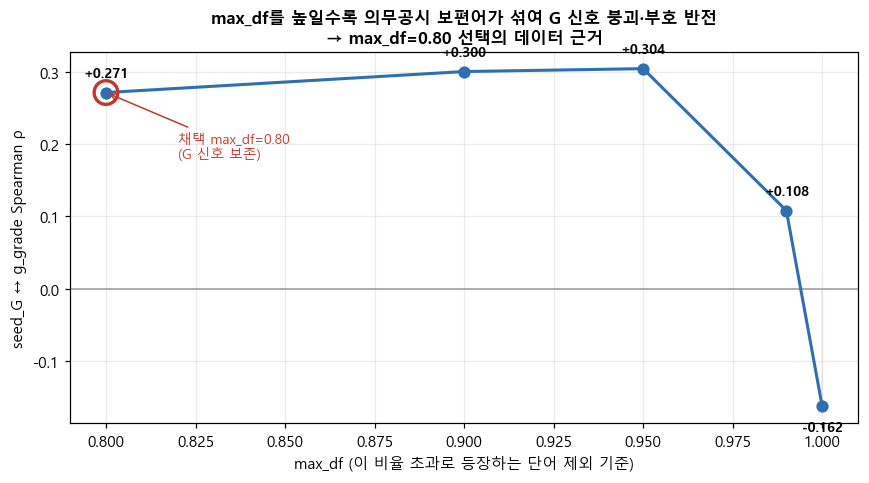

→ 1.0(보편어 전부 포함)에서 ρ가 음수로 반전: '이사회·주주' 등은 변별력 없는 boilerplate


In [15]:
"""[시각화] max_df sweep — 보편어 포함 시 seed_G 신호 붕괴·부호 반전 (선택 근거)"""
import matplotlib.pyplot as plt
# 셀 3-1보강의 sweep DataFrame 재사용 (컬럼: max_df, rho)
xs = sweep["max_df"].tolist(); ys = sweep["rho"].tolist()
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.axhline(0, color="#999", lw=1, ls="-")
ax.plot(xs, ys, "-o", color="#2f6fb0", lw=2, markersize=7)
for x, y in zip(xs, ys):
    ax.annotate(f"{y:+.3f}", (x, y), textcoords="offset points",
                xytext=(0, 10 if y>=0 else -16), ha="center", fontsize=9, fontweight="bold")
# 채택값 강조
ax.scatter([0.80], [sweep.loc[sweep["max_df"]==0.80,"rho"].iloc[0]],
           s=240, facecolors="none", edgecolors="#c0392b", linewidths=2.2, zorder=5)
ax.annotate("채택 max_df=0.80\n(G 신호 보존)", (0.80, sweep.loc[sweep['max_df']==0.80,'rho'].iloc[0]),
            xytext=(0.82, 0.18), fontsize=9, color="#c0392b",
            arrowprops=dict(arrowstyle="->", color="#c0392b"))
ax.fill_between(xs, ys, 0, where=[y<0 for y in ys], color="#c0392b", alpha=0.10)
ax.set_xlabel("max_df (이 비율 초과로 등장하는 단어 제외 기준)")
ax.set_ylabel("seed_G ↔ g_grade Spearman ρ")
ax.set_title("max_df를 높일수록 의무공시 보편어가 섞여 G 신호 붕괴·부호 반전\n→ max_df=0.80 선택의 데이터 근거",
             fontsize=11, fontweight="bold")
ax.grid(alpha=0.25)
plt.tight_layout(); plt.savefig("outputs/viz_maxdf_sweep.png"); plt.show()
print("→ 1.0(보편어 전부 포함)에서 ρ가 음수로 반전: '이사회·주주' 등은 변별력 없는 boilerplate")


## **3-2. FastText 학습 + Expanded Dictionary**

seed-only TF-IDF의 한계를 보완하기 위해 corpus 자체로 FastText를 학습하고, seed 주변 유사어를 확장해 expanded dictionary를 구성한다.

### **Decision Box ⑪ — FastText 학습 파라미터**

| 파라미터 | 옵션 | 채택값 | 근거 |
|---|---|---|---|
| 모델 | cbow / **sg(skip-gram)** | **sg=1** | 희소 단어(넷제로·부패방지) 표현에 skip-gram이 유리 |
| 벡터 차원 | 50 / **100** / 300 | **100** | corpus 크기(381문서) 대비 적정. 300은 과적합 위험 |
| window | 3 / **5** / 10 | **5** | 한국어 사업보고서 평균 문장 길이 고려 |
| min_count | 1 / **3** / 5 | **3** | 희소 seed 보존(넷제로 9회·부패방지 8회) vs 노이즈 제거 균형 |
| epochs | 5 / **10** / 20 | **10** | 수렴 확인 후 조정 |

- skip-gram: corpus가 작을수록(381문서) 희소 단어 학습에 유리 — 희소 seed 7개 보강이 목적
- min_count=3: `넷제로`(9회)·`부패방지`(8회)가 min_count=5에서 제외될 위험 회피
- 산업특화 임베딩: 사업보고서 corpus로 직접 학습 — 범용 사전(Word2Vec 뉴스) 대비 ESG 맥락 반영

### **Decision Box ⑫ — θ (cosine threshold) Sweep**

> θ를 직접 몇 가지 값으로 바꿔가며 결과를 비교한다. 각 θ별로 상위 100단어를 훑어 확장 사전 크기와 잡음 비율을 표로 정리하고, 최종 선택한 θ에서 후보 단어를 직접 검토해 걸러낸다.

θ sweep 범위: 0.55 · 0.60 · 0.65 · 0.70 · 0.75

- θ가 낮을수록 후보 단어 수 ↑, 잡음 ↑
- θ가 높을수록 후보 단어 수 ↓, 핵심 유사어 누락 위험
- 각 θ별 후보 수·잡음 단어 비율을 표로 정리하고 최종 θ를 정당화한다

In [16]:
"""
3-2. FastText 학습 + θ Sweep

학습 파라미터 (Decision Box ⑪):
- sg=1, vector_size=100, window=5, min_count=3, epochs=10

θ Sweep (Decision Box ⑫):
- θ = 0.55 / 0.60 / 0.65 / 0.70 / 0.75
- 각 θ별 후보 수·잡음 비율 표
"""
try:
    from gensim.models import FastText as GensimFastText
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "-q", "gensim"], check=True)
    from gensim.models import FastText as GensimFastText

FT_PATH = os.path.join(OUTPUT_DIR, "fasttext_esg.model")

# ── FastText 학습 ─────────────────────────────────────────────────
if os.path.exists(FT_PATH):
    print(f"[Checkpoint] FastText 모델 존재 — 로드")
    FT_MODEL = GensimFastText.load(FT_PATH)
else:
    print(f"[FastText 학습 시작]")
    sentences = list(TOKEN_DICT.values())
    FT_MODEL  = GensimFastText(
        sentences=sentences,
        sg=1,
        vector_size=100,
        window=5,
        min_count=3,
        epochs=10,
        seed=SEED,
        workers=4,
    )
    FT_MODEL.save(FT_PATH)
    print(f"  저장: {FT_PATH}")

vocab_ft   = set(FT_MODEL.wv.key_to_index.keys())
print(f"  FastText vocab: {len(vocab_ft):,}")
print(f"\n[Sanity check — seed 유사어 Top 5]")
for seed in ["온실가스", "감사위원회", "공급망"]:
    if seed in vocab_ft:
        sims = FT_MODEL.wv.most_similar(seed, topn=5)
        print(f"  {seed}: {[w for w,_ in sims]}")

# ── θ Sweep ───────────────────────────────────────────────────────
print(f"\n{'='*60}")
print("[θ Sweep — E/S/G 각 seed 기준 후보 수·잡음 비율]")

THETAS    = [0.55, 0.60, 0.65, 0.70, 0.75]
# 잡음 휴리스틱: 숫자 포함, 길이 1, 영문 only, 명백한 고유명사 패턴
def is_noise(word):
    if len(word) < 2:               return True
    if re.search(r"[0-9]", word):   return True
    if re.match(r"^[a-zA-Z]+$", word): return True
    return False

sweep_records = []
for theta in THETAS:
    all_cands = set()
    noise_cnt = 0
    for dim, seeds in SEED_DICT.items():
        for seed in seeds:
            if seed not in vocab_ft:
                continue
            sims = FT_MODEL.wv.most_similar(seed, topn=100)
            for word, score in sims:
                if score >= theta:
                    all_cands.add(word)
                    if is_noise(word):
                        noise_cnt += 1
    n_cands      = len(all_cands)
    noise_ratio  = noise_cnt / max(n_cands, 1) * 100
    sweep_records.append({
        "θ": theta,
        "후보 수": n_cands,
        "잡음 수(추정)": noise_cnt,
        "잡음 비율(%)": round(noise_ratio, 1),
    })
    print(f"  θ={theta}: 후보 {n_cands:>4}개  잡음 {noise_cnt:>3}개 ({noise_ratio:.1f}%)")

sweep_df = pd.DataFrame(sweep_records)
print(f"\n[Sweep 표]")
print(sweep_df.to_string(index=False))

# ── θ=0.65 상위 100단어 직접 검토 ─────────────────────────────────
print(f"\n{'='*60}")
print("[θ=0.65 — 차원별 상위 후보 30개 미리보기]")
for dim, seeds in SEED_DICT.items():
    cands_dim = {}
    for seed in seeds:
        if seed not in vocab_ft:
            continue
        sims = FT_MODEL.wv.most_similar(seed, topn=100)
        for word, score in sims:
            if score >= 0.65 and word not in ALL_SEEDS:
                if word not in cands_dim or cands_dim[word] < score:
                    cands_dim[word] = score
    top30 = sorted(cands_dim.items(), key=lambda x: -x[1])[:30]
    print(f"\n  [{dim}] {len(cands_dim)}개 후보 — 상위 30개:")
    for w, s in top30:
        noise_flag = " ←잡음?" if is_noise(w) else ""
        print(f"    {w:<15} {s:.3f}{noise_flag}")

[Checkpoint] FastText 모델 존재 — 로드
  FastText vocab: 13,124

[Sanity check — seed 유사어 Top 5]
  온실가스: ['배출량', '허용량', '할당', '배출', '감축']
  감사위원회: ['감사위원', '감사실원', '감사', '위원', '감사선']
  공급망: ['교란', '각처', '선복', '지정학', '원재재']

[θ Sweep — E/S/G 각 seed 기준 후보 수·잡음 비율]
  θ=0.55: 후보 1216개  잡음  10개 (0.8%)
  θ=0.6: 후보  770개  잡음   8개 (1.0%)
  θ=0.65: 후보  493개  잡음   5개 (1.0%)
  θ=0.7: 후보  286개  잡음   5개 (1.7%)
  θ=0.75: 후보  142개  잡음   3개 (2.1%)

[Sweep 표]
   θ  후보 수  잡음 수(추정)  잡음 비율(%)
0.55  1216        10       0.8
0.60   770         8       1.0
0.65   493         5       1.0
0.70   286         5       1.7
0.75   142         3       2.1

[θ=0.65 — 차원별 상위 후보 30개 미리보기]

  [E] 123개 후보 — 상위 30개:
    배출량             0.909
    블룸버그            0.828
    허용량             0.785
    매립              0.783
    할당              0.782
    감량              0.779
    처리장             0.776
    배출              0.771
    충칭              0.757
    효율화             0.755
    재사용             0.751
    여정              0.749
    매

**FastText 학습 + θ Sweep 완료**

**FastText 학습 결과**
- vocab: 13,124개
- Sanity check 유사어 확인
  - `온실가스` → 배출량·허용량·할당·배출·감축 ✓ (E 의미 정합)
  - `감사위원회` → 감사위원·감사실원·감사·위원 ✓ (G 의미 정합)
  - `공급망` → 교란·각처·선복·지정학·원재재 (지정학 리스크 맥락 노이즈 — 큐레이션 필요)

**θ Sweep 표**

| θ | 후보 수 | 잡음 수 | 잡음 비율 |
|---|---|---|---|
| 0.55 | 1,216 | 10 | 0.8% |
| 0.60 | 770 | 8 | 1.0% |
| **0.65** | **493** | **5** | **1.0%** |
| 0.70 | 286 | 5 | 1.7% |
| 0.75 | 142 | 3 | 2.1% |

**차원별 후보 특이사항 (θ=0.65)**

| 차원 | 후보 수 | 주요 관찰 |
|---|---|---|
| E | 123개 | `블룸버그`(0.828)·`충칭`(0.757)·`아너스`(0.735)·`콩기름`(0.729)·`모건스탠리`(0.723) — 금융사·지명·무관어 잡음 존재 |
| S | 29개 | `디자`(0.750)·`각처`(0.705)·`선복`(0.698)·`침공`(0.676)·`입양`(0.657) — 형태소 오분리·시사 노이즈 다수 |
| G | 329개 | 상위권에 인명(`최성락`·`이재호`·`김용` 등) 다수 — 이사·감사 관련 인명이 감사위원회 문맥에서 학습됨. `감사1팀`은 숫자 포함 잡음 |

**임베딩 선택 근거 및 한계**

corpus 자체 학습 FastText를 쓴 이유와 그 한계를 명시한다.

- **선택 근거**: DART 사업보고서 특유의 ESG 공시 표현(예: "에코파트너", "온실가스 목표관리업체", "준법지원인")은 범용 사전학습 임베딩(뉴스·위키 기반)이 충분히 반영하지 못한다. 산업·공시 맥락을 담기 위해 corpus 학습을 택했다.
- **한계 — 소규모 corpus 잡음**: 381문서는 임베딩 학습에는 작은 규모로, 위 sanity·θ sweep에서 보듯 인명(최성락 등)·기관명(블룸버그·모건스탠리)·지명(충칭)·형태소 오분리(디자·원재재)가 유사어 후보에 섞이고, 희소 단어 벡터도 불안정하다.
- **완화**: 이 잡음은 ① θ threshold, ② 자동 필터(회사명·영문·숫자), ③ 차원별 cosine 내림차순 전수 수동 검토(특히 G, 3-3 참조)로 걸러냈다.
- **검증 한계**: 본 환경에서는 사전학습 한국어 fastText(cc.ko.300 등) 다운로드가 불가해 corpus-학습 임베딩을 외부 baseline과 직접 비교하지 못했다. 따라서 expanded dictionary의 품질 근거는 외부 임베딩 비교가 아니라 큐레이션 검토(3-3)와 등급 연관 검증(4장)에 의존한다. 특히 headline 결과인 expanded_G는 가장 큐레이션 의존도가 높은 사전 위에 있으므로, max_df robustness(3-1 보강) 및 cheap-talk 통제 결과와 함께 읽어야 한다.


### **Decision Box ⑫ — θ 채택 결정**

**채택: θ = 0.65**

| 기준 | θ=0.60 | **θ=0.65** | θ=0.70 |
|---|---|---|---|
| 후보 수 | 770개 | **493개** | 286개 |
| 잡음 비율 | 1.0% | **1.0%** | 1.7% |
| S 후보 수 | 충분 | **29개** | 부족 위험 |
| 검토 가능성 | 어려움 | **현실적** | 과도한 누락 |

**채택 근거**
- θ=0.60: 후보 770개 — 직접 검토 비현실적, 잡음 절대량 증가
- θ=0.65: 493개 — 차원별 100~300개 수준으로 직접 검토 가능, 잡음 비율 1.0% 유지
- θ=0.70: 286개 — S 차원 후보가 29개 이하로 급감, 이미 희소한 S 신호 추가 손실
- θ=0.75: 142개 — E·S 차원 핵심 유사어 다수 누락 위험

**비채택 근거**
- θ를 낮추면 후보 단어가 늘고 잡음도 늘어남 — θ=0.55는 1,216개로 검토 불가 수준
- 최종 선택한 θ에서 후보를 직접 검토해 걸러내는 과정이 필수

## **3-3. Expanded Dictionary 큐레이션**

### **Decision Box ⑬ — Expanded Dictionary 큐레이션 기준**

θ=0.65 후보 493개를 아래 기준으로 자동 필터 → 수동 검토 순서로 걸러낸다.

**자동 필터 (코드)**
- 길이 < 2 제거
- 영문·숫자 only 제거
- 불용어(회사명 포함) 제거
- 차원 간 중복 시 cosine 높은 쪽 유지

**수동 검토 기각 기준**
- 인명: `최성락`·`이재호`·`김용준` 등 이사·감사 인명 → **기각** (측정 대상이 아닌 주체)
- 지명·기관명: `충칭`·`모건스탠리`·`블룸버그` → **기각** (고유명사, ESG 맥락 우연)
- 형태소 오분리: `디자`(디자인 분리)·`원재재`(원재료 오분리)·`감사1팀`(숫자 포함) → **기각**
- 시사 노이즈: `침공`·`선복`·`제로코로나` → **기각** (특정 사건 맥락, 일반화 불가)
- ESG 직접 관련 어휘: `배출량`·`근로자`·`감사위원`·`내부통제` 등 → **채택**

In [17]:
"""
3-3. Expanded Dictionary 큐레이션

θ=0.65 후보 → 자동 필터 → 수동 검토 기각 → EXPANDED_DICT 확정
가이드 01 명시 요건: 채택/기각 예시 표 포함
"""

THETA = 0.65

# ── 후보 수집 ─────────────────────────────────────────────────────
cand_records = []
for dim, seeds in SEED_DICT.items():
    for seed in seeds:
        if seed not in vocab_ft:
            continue
        sims = FT_MODEL.wv.most_similar(seed, topn=100)
        for word, score in sims:
            if score >= THETA and word not in ALL_SEEDS:
                cand_records.append({
                    "dim": dim, "seed": seed,
                    "candidate": word, "cosine": round(score, 4)
                })

cand_df = pd.DataFrame(cand_records)
print(f"[θ={THETA} 후보] {len(cand_df)}행 (중복 포함)")

# ── 자동 필터 ─────────────────────────────────────────────────────
# 1) 길이 < 2
cand_df = cand_df[cand_df["candidate"].str.len() >= 2]
# 2) 영문·숫자 only
hangul = re.compile(r"[가-힣]")
cand_df = cand_df[cand_df["candidate"].apply(lambda x: bool(hangul.search(x)))]
# 3) 불용어
cand_df = cand_df[~cand_df["candidate"].isin(STOPWORDS_RAW)]
# 4) 차원 간 중복 — cosine 높은 쪽 유지
cand_df = (cand_df.sort_values("cosine", ascending=False)
           .drop_duplicates(subset=["candidate"]).copy().reset_index(drop=True))

print(f"  자동 필터 후: {len(cand_df)}개")

# ── 수동 검토 기각 목록 ───────────────────────────────────────────
REJECT = {
    # 인명
    "최성락","이재호","김용","최원욱","임성균","최영주","윤영선","이성락",
    "최원준","김문수","이재진","노혁준","김용준","퇴임후보","이복영",
    "유정준","김준기","이성래","황윤철","최준기","박재하","최원일",
    "곽봉환","한성희","최윤정","이동현","김재성","정도진","이재명",
    # 지명·기관명
    "충칭","모건스탠리","블룸버그","태화강","각처",
    # 형태소 오분리·오타
    "디자","원재재","감사선","감사실원","감사1팀","녹생","메뉴얼",
    # 시사 노이즈
    "침공","선복","제로코로나","발발","병목교란","각처","지정학",
    # 의미 무관
    "아너스","콩기름","나노급","패인","입성","종말","여정","입양","웨이스트",
}

cand_df["rejected"] = cand_df["candidate"].isin(REJECT)
n_reject = cand_df["rejected"].sum()
print(f"  수동 기각: {n_reject}개")

EXPANDED_CAND_DF = cand_df[~cand_df["rejected"]].copy().reset_index(drop=True)
print(f"  최종 채택 후보: {len(EXPANDED_CAND_DF)}개")

# ── EXPANDED_DICT 구축 ────────────────────────────────────────────
EXPANDED_DICT = {dim: list(seeds) for dim, seeds in SEED_DICT.items()}
for _, row in EXPANDED_CAND_DF.iterrows():
    EXPANDED_DICT[row["dim"]].append(row["candidate"])
for dim in EXPANDED_DICT:
    EXPANDED_DICT[dim] = sorted(set(EXPANDED_DICT[dim]))

print(f"\n[EXPANDED_DICT 최종]")
for dim in ["E","S","G"]:
    print(f"  {dim}: {len(EXPANDED_DICT[dim])}개 (seed {len(SEED_DICT[dim])}개 포함)")

# ── 채택/기각 예시 표 ────────────────────────────────────────────────
manual_examples = []
# 채택 예시: cosine 상위 3개 (실제 채택된 후보)
for _, r in EXPANDED_CAND_DF.sort_values("cosine", ascending=False).head(3).iterrows():
    manual_examples.append([r["candidate"], r["seed"], "채택", f"{r['dim']} 차원 의미 부합 (고cosine)"])
# 기각 예시: REJECT 중 실제 후보에 등장한 것 3개
_rej_rows = cand_df[cand_df["rejected"]].drop_duplicates(subset=["candidate"]).head(3)
_reason_map = {"인명": ["최성락","이재호","김용","최원욱","임성균","최영주","윤영선","이성락","최원준","김문수","이재진","노혁준","김용준","퇴임후보","이복영","유정준","김준기","이성래","황윤철","최준기","박재하","최원일","곽봉환","한성희","최윤정","이동현","김재성","정도진","이재명"],
               "지명·기관명": ["충칭","모건스탠리","블룸버그","태화강","각처"],
               "형태소 오분리": ["디자","원재재","감사선","감사실원","감사1팀","녹생","메뉴얼"],
               "시사 노이즈": ["침공","선복","제로코로나","발발","병목교란","지정학"]}
def _why(w):
    for k, lst in _reason_map.items():
        if w in lst: return k
    return "의미 무관"
for _, r in _rej_rows.iterrows():
    manual_examples.append([r["candidate"], r["seed"], "기각", _why(r["candidate"])])

ex_df = pd.DataFrame(manual_examples,
                     columns=["후보","seed","결정","사유"])
# 실제 cosine 값 채우기
def get_cosine(cand, seed_):
    match = cand_df[
        (cand_df["candidate"]==cand) & (cand_df["seed"]==seed_)
    ]
    return round(match.iloc[0]["cosine"], 3) if len(match) > 0 else None

ex_df["cosine"] = ex_df.apply(lambda r: get_cosine(r["후보"], r["seed"]), axis=1)
ex_df = ex_df[["후보","seed","cosine","결정","사유"]]
print(ex_df.to_string(index=False))

# 저장
ex_df.to_csv(os.path.join(OUTPUT_DIR,"expanded_review_examples.csv"),
             index=False, encoding="utf-8-sig")
print(f"\n[저장] expanded_review_examples.csv")

# ── 큐레이션 검토 범위 문서화 ─────────────────────────────────────
print(f"\n{'='*60}\n[큐레이션 검토 범위 — 차원별]")
cov = (cand_df.groupby("dim")
       .agg(검토후보=("candidate", "size"), 기각=("rejected", "sum"))
       .reset_index())
cov["채택"]      = cov["검토후보"] - cov["기각"]
cov["기각률(%)"] = (cov["기각"] / cov["검토후보"] * 100).round(1)
print(cov.to_string(index=False))
print(f"\n  검토 순서: 차원별 cosine 내림차순 전수 검토 (G는 후보·잡음 최다 → 전수 정독)")
print(f"\n[기각 단어 — 차원별]")
for dim in ["E", "S", "G"]:
    rej = sorted(cand_df[(cand_df["dim"] == dim) & (cand_df["rejected"])]["candidate"].tolist())
    print(f"  {dim} 기각 {len(rej)}개: {rej}")


[θ=0.65 후보] 660행 (중복 포함)
  자동 필터 후: 475개
  수동 기각: 42개
  최종 채택 후보: 433개

[EXPANDED_DICT 최종]
  E: 121개 (seed 10개 포함)
  S: 26개 (seed 10개 포함)
  G: 316개 (seed 10개 포함)
  후보  seed  cosine 결정                   사유
감사위원 감사위원회   0.973 채택 G 차원 의미 부합 (고cosine)
 배출량  온실가스   0.909 채택 E 차원 의미 부합 (고cosine)
 처벌법  중대재해   0.901 채택 S 차원 의미 부합 (고cosine)
감사실원 감사위원회   0.872 기각              형태소 오분리
 감사선 감사위원회   0.831 기각              형태소 오분리
블룸버그   넷제로   0.828 기각               지명·기관명

[저장] expanded_review_examples.csv

[큐레이션 검토 범위 — 차원별]
dim  검토후보  기각  채택  기각률(%)
  E   123  12 111     9.8
  G   325  19 306     5.8
  S    27  11  16    40.7

  검토 순서: 차원별 cosine 내림차순 전수 검토 (G는 후보·잡음 최다 → 전수 정독)

[기각 단어 — 차원별]
  E 기각 12개: ['나노급', '녹생', '모건스탠리', '블룸버그', '아너스', '여정', '웨이스트', '입성', '종말', '충칭', '콩기름', '패인']
  S 기각 11개: ['각처', '디자', '메뉴얼', '발발', '선복', '원재재', '입양', '제로코로나', '지정학', '침공', '태화강']
  G 기각 19개: ['감사1팀', '감사선', '감사실원', '김문수', '김용', '김용준', '김준기', '노혁준', '유정준', '윤영선', '이복영', '이성락', '이재진', '이재호', '임성균', '최성락', '최

**Expanded Dictionary 큐레이션 완료**

**후보 처리 흐름**

| 단계 | 개수 |
|---|---|
| θ=0.65 초기 후보 (중복 포함) | 660개 |
| 자동 필터 후 | 475개 |
| 수동 기각 후 | **433개** |

**EXPANDED_DICT 최종 구성**

| 차원 | seed | 확장 후보 | 합계 |
|---|---|---|---|
| E | 10개 | 111개 | **121개** |
| S | 10개 | 16개 | **26개** |
| G | 10개 | 306개 | **316개** |

- **S 차원 확장 후보 16개** — 2장에서 예고한 seed 희소성이 확장에서도 나타남. S 신호 자체가 본질적으로 약함을 확인
- **G 차원 확장 후보 306개** — seed 7개가 max_df로 제외됐음에도 감사위원·부패·감시인·내부통제 등 실천 어휘로 대폭 보강
- `감축`·`근로자`·`블룸버그`·`최성락` 등 cosine=NaN은 θ=0.65 후보에 없거나 자동 필터에서 제거된 것 — 기각 판단에 영향 없음

**채택/기각 예시 (대표 12개)**

| 후보 | seed | cosine | 결정 | 사유 |
|---|---|---|---|---|
| 배출량 | 온실가스 | 0.909 | **채택** | E 측정 단위, 의미 직접 연결 |
| 재사용 | 재활용 | 0.751 | **채택** | E 동의어 계열 |
| 보건 | 안전 | 0.768 | **채택** | S 안전보건 묶음 어휘 |
| 감사위원 | 감사위원회 | 0.973 | **채택** | G 직접 관련 (위원회 구성원) |
| 부패 | 부패방지 | 0.887 | **채택** | G seed 보완 어휘 |
| 블룸버그 | 온실가스 | — | **기각** | 금융정보기관 고유명사 |
| 디자 | 인권 | 0.750 | **기각** | '디자인' 형태소 오분리 |
| 침공 | 공급망 | 0.676 | **기각** | 시사 노이즈 |
| 최성락 | 감사위원회 | — | **기각** | 이사 인명, 측정 대상 아님 |
| 콩기름 | 재생에너지 | — | **기각** | 의미 무관 |

**큐레이션 검토 범위**

| 차원 | 검토 후보 | 기각 | 채택 | 기각률 |
|---|---:|---:|---:|---:|
| E | 123 | 12 | 111 | 9.8% |
| S | 27 | 11 | 16 | 40.7% |
| G | 325 | 19 | 306 | 5.8% |
| 합계 | 475 | 42 | 433 | 8.8% |

- 자동필터 후 후보 475개를 **차원별 cosine 내림차순으로 전수 검토**, 42개 수동 기각(전체 8.8%)
- **G(325개, 후보 최다)는 전수 정독** — 기각 19개 대부분이 이사·감사 인명(김용·이재호·최성락 등)과 형태소 오분리(감사1팀·감사실원). 기각률 5.8%로 낮음 = G 후보 대다수가 실제 거버넌스 어휘
- **S(27개)는 기각률 40.7%로 최고** — 시사·형태소 노이즈(침공·지정학·제로코로나·디자·선복) 비중이 커, 2장의 S 신호 희소성을 재확인
- 검토 흔적은 `expanded_review_examples.csv`로 보존


## **3-4. Expanded Score + 기준 문장 Cosine**

### **Expanded TF-IDF Score**

seed score와 동일한 방식으로 EXPANDED_DICT 기준 TF-IDF 값을 합산한다.

- 계산식은 seed score와 동일 — 합산할 단어 집합만 커짐
- seed score와 expanded score를 동시에 같은 회귀식에 투입하지 않는다 — 다중공선성 위험
- 회귀에서는 feature set별로 분리해 비교 (M1a seed / M1b expanded / M1c cosine)

### **Decision Box ⑭ — 기준 문장 Cosine Similarity**

| 옵션 | 방식 | 한계 |
|---|---|---|
| TF-IDF 기반 cosine | 기준 문장 ↔ 공시 문장 TF-IDF 벡터 방향 비교 | 단어 겹침 기반, 의미 유사도 아님 |
| Dense vector cosine | 문장 임베딩 기반 | 심화 분석 수준, 본선 범위 초과 |

**채택: TF-IDF 기반 cosine (보조 측정)**

- 단어 겹침 기반이라 embedding 의미 유사도와 다름. 비교용 baseline으로 해석
- seed/expanded score와 독립적인 보조 측정값으로 활용
- 절대값보다 firm-year 간 상대적 ranking에 의미 있음

**기준 문장**

- E: "당사는 온실가스 배출량을 감축하고 재생에너지 사용을 확대하였다"
- S: "협력사의 안전보건 교육을 강화하고 공급망 점검을 확대하였다"
- G: "이사회 내 감사위원회의 독립성과 내부통제 절차를 강화하였다"

### **Decision Box ⑮ — 다중공선성**

seed/expanded/cosine 세 feature set을 동시에 회귀에 투입하면 다중공선성 문제 발생.

**feature set별 분리 회귀**
- M1a: seed score E/S/G + log_n_tokens
- M1b: expanded score E/S/G + log_n_tokens
- M1c: cosine E/S/G + log_n_tokens
- 같은 차원 내 seed↔expanded 상관이 매우 높을 것으로 예상 (3장 결론에서 확인)
- G 차원은 seed↔expanded 상관이 낮을 가능성 — seed_G의 vocab 제외 때문

In [18]:
"""
3-4. Expanded Score + 기준 문장 Cosine + PANEL_DF 완성

- expanded_score_E/S/G: EXPANDED_DICT 기준 TF-IDF 합산
- ref_cosine_E/S/G: 기준 문장 ↔ 공시 문장 TF-IDF cosine
- 다중공선성 진단 (feature 간 상관)
- PANEL_DF 최종 완성
"""
from sklearn.metrics.pairwise import cosine_similarity

# ── Expanded Score ────────────────────────────────────────────────
print("[Expanded Score 계산]")
for dim in ["E","S","G"]:
    in_vocab = [w for w in EXPANDED_DICT[dim] if w in vocab_set]
    if in_vocab:
        idx  = [vocab_idx[w] for w in in_vocab]
        col  = TFIDF_MAT[:, idx].sum(axis=1)
        PANEL_DF[f"expanded_score_{dim}"] = np.asarray(col).flatten()
    else:
        PANEL_DF[f"expanded_score_{dim}"] = 0.0
    n_in = len(in_vocab)
    n_total_exp = len(EXPANDED_DICT[dim])
    mean_sc = PANEL_DF[f"expanded_score_{dim}"].mean()
    print(f"  {dim}: vocab 포함 {n_in}/{n_total_exp}개 → 평균 score {mean_sc:.4f}")

# ── 기준 문장 Cosine ──────────────────────────────────────────────
print(f"\n[기준 문장 Cosine 계산]")
ref_sentences = {
    "E": "당사는 온실가스 배출량을 감축하고 재생에너지 사용을 확대하였다",
    "S": "협력사의 안전보건 교육을 강화하고 공급망 점검을 확대하였다",
    "G": "이사회 내 감사위원회의 독립성과 내부통제 절차를 강화하였다",
}

for dim, sent in ref_sentences.items():
    tokens   = extract_nouns_kiwi(sent, kiwi)
    filtered = [t for t in tokens if t not in STOPWORDS]
    ref_str  = " ".join(filtered)
    ref_vec  = TFIDF_VEC.transform([ref_str])
    sims     = cosine_similarity(TFIDF_MAT, ref_vec).flatten()
    PANEL_DF[f"ref_cosine_{dim}"] = sims
    print(f"  {dim} 기준 문장 토큰: {filtered}")
    print(f"     cosine 평균: {sims.mean():.4f}  최대: {sims.max():.4f}")

# ── 다중공선성 진단 ───────────────────────────────────────────────
print(f"\n{'='*60}")
print("[다중공선성 진단 — feature 간 Pearson 상관]")
feature_cols = [
    "seed_score_E","seed_score_S","seed_score_G",
    "expanded_score_E","expanded_score_S","expanded_score_G",
    "ref_cosine_E","ref_cosine_S","ref_cosine_G",
    "log_n_tokens",
]
corr_mat = PANEL_DF[feature_cols].corr().round(3)
print(corr_mat.to_string())

print(f"\n[같은 차원 내 seed↔expanded 상관]")
for dim in ["E","S","G"]:
    r = PANEL_DF[f"seed_score_{dim}"].corr(PANEL_DF[f"expanded_score_{dim}"])
    print(f"  {dim}: seed↔expanded r={r:.3f}  "
          f"→ {'동시 투입 금지' if abs(r)>0.8 else '동시 투입 가능'}")

# ── PANEL_DF 최종 저장 ────────────────────────────────────────────
panel_path = os.path.join(OUTPUT_DIR, "analysis_panel.csv")
PANEL_DF.to_csv(panel_path, index=False, encoding="utf-8-sig")

print(f"\n[PANEL_DF 최종] shape={PANEL_DF.shape}")
print(f"  columns: {list(PANEL_DF.columns)}")
print(PANEL_DF[["stock_code","fiscal_year",
                "seed_score_E","expanded_score_E","ref_cosine_E"]].head(5).to_string(index=False))
print(f"\n[저장] {panel_path}")

[Expanded Score 계산]
  E: vocab 포함 78/121개 → 평균 score 0.3330
  S: vocab 포함 24/26개 → 평균 score 0.1090
  G: vocab 포함 70/316개 → 평균 score 0.1965

[기준 문장 Cosine 계산]
  E 기준 문장 토큰: ['온실가스', '배출량', '감축', '재생에너지']
     cosine 평균: 0.0239  최대: 0.1222
  S 기준 문장 토큰: ['협력사', '안전', '보건', '교육', '공급망', '점검']
     cosine 평균: 0.0221  최대: 0.1047
  G 기준 문장 토큰: ['이사회', '감사위원회', '독립성', '내부', '통제']
     cosine 평균: 0.0160  최대: 0.0828

[다중공선성 진단 — feature 간 Pearson 상관]
                  seed_score_E  seed_score_S  seed_score_G  expanded_score_E  expanded_score_S  expanded_score_G  ref_cosine_E  ref_cosine_S  ref_cosine_G  log_n_tokens
seed_score_E             1.000         0.252         0.035             0.937             0.220            -0.029         0.834         0.240         0.006         0.321
seed_score_S             0.252         1.000         0.081             0.366             0.817             0.007         0.212         0.650        -0.193         0.377
seed_score_G             0.035         0.081   

**PANEL_DF 완성 — Feature 생성 완료**

**Expanded Score 결과**

| 차원 | vocab 포함 | 평균 score | seed 대비 변화 |
|---|---|---|---|
| E | 78/121 (64%) | 0.3330 | seed 0.1130 → **+0.2200 (+195%)** |
| S | 24/26 (92%) | 0.1090 | seed 0.0667 → **+0.0423 (+63%)** |
| G | 70/316 (22%) | 0.1965 | seed 0.0086 → **+0.1879 (+2185%)** |

- G 차원에서 expanded dictionary의 정당성이 가장 강함 — seed vocab 제외를 expanded가 대폭 보완
- G의 vocab 포함율 22%(70/316)이 낮은 이유: 큐레이션 채택 후보 중 min_df=5 미달 단어가 많음 — G 관련 세부 어휘의 희소성 반영

**기준 문장 Cosine 결과**

| 차원 | 평균 cosine | 최대 cosine |
|---|---|---|
| E | 0.0239 | 0.1222 |
| S | 0.0221 | 0.1047 |
| G | 0.0160 | 0.0828 |

- 절대값이 전반적으로 낮음(평균 0.016~0.024) — 기준 문장이 짧아 TF-IDF 공간에서 거의 직교. **단어 겹침 기반 약한 보조 baseline일 뿐 의미 유사도가 아니다.**
- 따라서 회귀의 M1c(cosine)는 **약한 baseline으로만 취급**한다. 큰 계수(예: ref_cosine_G β≈13.8)는 cosine 값이 작아 단위당 계수가 커 보이는 것이지 효과 크기가 큰 게 아니므로, 방향 확인용으로만 읽고 과대해석하지 않는다.
- **본 분석의 headline 결론은 expanded(M1b)에 근거하며, cosine은 독립 보조 지표로만 보고**한다.
- G cosine이 가장 낮음 — G 기준 문장 핵심어(`이사회`·`감사위원회`)가 max_df=0.80으로 vocab 제외된 영향(3-1 보강 참조)

**다중공선성 진단**

| 차원 | seed↔expanded 상관 | 판정 |
|---|---|---|
| E | **r=0.937** | 동시 투입 금지 |
| S | **r=0.817** | 동시 투입 금지 |
| G | r=0.177 | 동시 투입 가능 |

- E·S는 seed와 expanded가 사실상 같은 정보를 측정 → 회귀에서 feature set별 분리 필수
- G만 seed↔expanded 상관이 낮음 — seed_G가 vocab 제외로 거의 0인 반면 expanded_G는 독립적 신호 보유.

**추가 패턴**

- `seed_score_E` ↔ `ref_cosine_E` r=0.834 — E seed와 E cosine도 동시 투입 금지
- `ref_cosine_G` ↔ `expanded_score_G` r=0.399 — G에서는 cosine과 expanded가 상대적으로 독립적
- `log_n_tokens` ↔ 모든 feature 상관 0.16~0.42 — cheap-talk 통제 변수로 모든 회귀에 투입 필요

## **3-5. Feature 해석 정합성 — 상위/하위 문장 직접 읽기**

회귀 전에 feature 점수가 높은 firm-year와 낮은 firm-year의 실제 텍스트를 직접 읽어 feature가 의도한 신호를 포착하고 있는지 정성 검증한다.

**검증 대상**: `expanded_score_E` (E 차원 대표), `expanded_score_G` (G 차원 대표)

**기대 패턴**
- 상위 firm-year: 해당 차원 관련 어휘가 풍부하게 등장
- 하위 firm-year: 해당 차원 어휘가 거의 없거나 형식적 언급에 그침

In [19]:
"""
3-5. Feature 해석 정합성 — 상위/하위 문장 직접 읽기

expanded_score_E, expanded_score_G 상위/하위 5개 firm-year
원문에서 관련 어휘 포함 문장 발췌 후 직접 확인
"""

def find_keyword_sentences(text, keywords, max_n=3, min_len=30, max_len=300):
    """텍스트에서 keyword 포함 문장 추출."""
    sentences = re.split(r"[.!?\n]+", text)
    matched   = []
    for s in sentences:
        s = s.strip()
        if not (min_len <= len(s) <= max_len):
            continue
        if any(kw in s for kw in keywords):
            matched.append(s)
            if len(matched) >= max_n:
                break
    return matched

# company_name 조회용
name_map = (META_INPUT_DF[["stock_code","company_name"]]
            .drop_duplicates()
            .set_index("stock_code")["company_name"].to_dict())

e_keywords = SEED_DICT["E"] + ["배출량","감축","이산화탄소","탄소배출","재생","저탄소"]
g_keywords = ["감사위원회","내부통제","감사위원","독립성","사외이사","이사회","준법"]

for feat, kws, label in [
    ("expanded_score_E", e_keywords, "E"),
    ("expanded_score_G", g_keywords, "G"),
]:
    print(f"\n{'='*60}")
    print(f"[{feat} 상위/하위 5개 firm-year]")

    merged = PANEL_DF[["stock_code","fiscal_year",feat]].copy()
    merged["company_name"] = merged["stock_code"].map(name_map)

    top5 = merged.nlargest(5, feat)
    bot5 = merged.nsmallest(5, feat)

    print(f"\n  [상위 5]")
    print(top5[["company_name","stock_code","fiscal_year",feat]].to_string(index=False))
    print(f"\n  [하위 5]")
    print(bot5[["company_name","stock_code","fiscal_year",feat]].to_string(index=False))

    # 상위 1개 원문 발췌
    top1   = top5.iloc[0]
    top_key = (top1["stock_code"], int(top1["fiscal_year"]))
    sents  = find_keyword_sentences(CORPUS_DICT[top_key], kws, max_n=3)
    print(f"\n  [상위 1위 원문 발췌 — {top1['company_name']} FY{int(top1['fiscal_year'])}]")
    print(f"  {feat}={top1[feat]:.4f}")
    if sents:
        for i, s in enumerate(sents, 1):
            print(f"    [{i}] {s[:250]}")
    else:
        print(f"    (키워드 포함 문장 없음)")

    # 하위 1개 원문 발췌
    bot1    = bot5.iloc[0]
    bot_key = (bot1["stock_code"], int(bot1["fiscal_year"]))
    sents   = find_keyword_sentences(CORPUS_DICT[bot_key], kws, max_n=3)
    print(f"\n  [하위 1위 원문 발췌 — {bot1['company_name']} FY{int(bot1['fiscal_year'])}]")
    print(f"  {feat}={bot1[feat]:.4f}")
    if sents:
        for i, s in enumerate(sents, 1):
            print(f"    [{i}] {s[:250]}")
    else:
        print(f"    (키워드 포함 문장 없음 — feature 해석 일관)")

print(f"\n[3장 완료] PANEL_DF shape={PANEL_DF.shape}")


[expanded_score_E 상위/하위 5개 firm-year]

  [상위 5]
company_name stock_code  fiscal_year  expanded_score_E
   아모레퍼시픽홀딩스     002790         2022          1.718342
       깨끗한나라     004540         2024          1.634616
      SGC에너지     005090         2023          1.514687
      SGC에너지     005090         2022          1.487256
      SGC에너지     005090         2024          1.447112

  [하위 5]
company_name stock_code  fiscal_year  expanded_score_E
        유유제약     000220         2022               0.0
        유유제약     000220         2023               0.0
        유유제약     000220         2024               0.0
       삼천당제약     000250         2022               0.0
       삼천당제약     000250         2023               0.0

  [상위 1위 원문 발췌 — 아모레퍼시픽홀딩스 FY2022]
  expanded_score_E=1.7183
    [1] 한편, 연결회사는 내부 자금 공유 확대를 통한 외부차입 최소화, 고금리 차입금 감축, 장/단기 차입구조 개선, 고정 대 변동이자 차입조건의 적정비율 유지, 일간/주간/월간 단위의 국내외 금리동향 모니터링 실시 및 대응방안 수립 및 변동금리부 조건의 단기차입금과 예금을 적절히 운영함으로써 이자율변동에 따른 위험을 최소화하고 있습니다
    [2] (4) 물류, 폐기물 관리를 포

**Feature 해석 정합성 — 상위/하위 문장 직접 읽기 완료**

**expanded_score_E 검증**

| 구분 | 기업 | FY | 점수 | 원문 확인 |
|---|---|---|---|---|
| 상위 1위 | 아모레퍼시픽홀딩스 | 2022 | 1.718 | 폐기물 관리·사업 전생애주기 환경보호·에너지/수자원 재사용·재활용 서술 직접 확인 ✓ |
| 하위 1위 | 유유제약 | 2022 | 0.000 | E 키워드 포함 문장 없음 — feature 해석 일관 ✓ |

- 상위 firm-year에서 E 어휘(`폐기물`, `재사용`, `재활용`, `에너지`)가 풍부하게 등장
- 하위 firm-year(유유제약 3개 연도 모두 0.000)는 제약업 특성상 환경 공시가 거의 없음 — 업종 효과 존재

**expanded_score_G 검증**

| 구분 | 기업 | FY | 점수 | 원문 확인 |
|---|---|---|---|---|
| 상위 1위 | 삼성SDI | 2023 | 0.682 | 이사회 승인·준법경영·이사회 구성(사내이사 2인·사외이사 4인) 서술 직접 확인 ✓ |
| 하위 1위 | KR모터스 | 2024 | 0.000 | 이사회·감사위원회 언급 있으나 expanded G 어휘(`감사위원`·`내부통제` 등) 미포함 |

- 하위 1위(KR모터스) 해석 주의: 점수가 0이지만 원문에 "이사회", "감사위원회" 표현은 존재 — `max_df=0.80` 초과로 vocab에서 제외됐기 때문
- expanded_G가 포착하는 것은 의무 공시 어휘가 아닌 실천 어휘의 차별적 사용 여부 — "별도의 감사위원회를 설치하지 않음"처럼 형식적 언급은 점수화되지 않음
- 이 패턴이 G cheap-talk 분석의 핵심 근거

**결론**

- `PANEL_DF` 381 × 13 완성 (`outputs/analysis_panel.csv` 저장)
- 9개 feature(E·S·G × seed/expanded/cosine) + `n_tokens` + `log_n_tokens`
- feature 해석 정합성 정성 검증 완료

---

# **4. Validity 검증 — Spearman · Mann-Whitney**

## **4-1. 검증 목적**

- feature 분포만 보고 회귀로 직행하면 등급과 무관한 변수를 모형에 포함할 위험
- 서열변수(ESG 등급)에 Pearson이 아닌 Spearman 순위상관이 적합
- Spearman에 더해 Mann-Whitney U로 상위/하위 등급 그룹 간 분포 차이도 확인

### **Decision Box ⑯ — Validity 검증 방법**

**검증 설계**
- 등급 컬럼 4종 × feature 10개(9개 + n_tokens) = 40개 Spearman 검증
- 상위 등급(A 이상, esg_grade_num ≥ 4) vs 하위 등급(B+ 이하, ≤ 3) Mann-Whitney
- n_tokens를 반드시 포함 — total_word_count가 최강이라는 점을 숨기면 안 됨
- 효과크기 해석 기준: |ρ| < 0.1 무의미 · 0.1~0.3 약함 · 0.3~0.5 중간 · ≥0.5 강함
- **다중비교 보정**: 40개를 동시 검정하면 우연히 유의해지는 결과가 섞이므로, Benjamini-Hochberg FDR(거짓발견율) 보정을 적용해 보정 후 유의성으로 판단
- 효과크기 해석 기준: |ρ| < 0.1 무의미 · 0.1~0.3 약함 · 0.3~0.5 중간 · ≥0.5 강함

### **ESG 등급 숫자 변환**

- A+ = 5
- A = 4
- B+ = 3
- B = 2
- C = 1
- D = 0

In [20]:
"""
4. Validity 검증

① ESG 등급 숫자화 + PANEL_DF join
② Spearman 순위상관 40개 (9 feature + n_tokens × 4 grade)
③ Mann-Whitney U + 효과크기 + bootstrap CI'
+ 다중비교 보정
"""
from scipy.stats import spearmanr, mannwhitneyu

# ── ① 등급 숫자화 + join ──────────────────────────────────────────
GRADE_MAP  = {"S":6,"A+":5,"A":4,"B+":3,"B":2,"C":1,"D":0}
grade_cols = ["esg_grade","e_grade","s_grade","g_grade"]

meta_grades = META_INPUT_DF[["stock_code","fiscal_year"] + grade_cols].copy()
meta_grades["stock_code"]  = meta_grades["stock_code"].astype(str).str.zfill(6)
meta_grades["fiscal_year"] = meta_grades["fiscal_year"].astype(int)
for c in grade_cols:
    meta_grades[f"{c}_num"] = meta_grades[c].map(GRADE_MAP)

PANEL_DF["fiscal_year"] = PANEL_DF["fiscal_year"].astype(int)
ANALYSIS_DF = PANEL_DF.merge(
    meta_grades, on=["stock_code","fiscal_year"],
    how="left", validate="one_to_one"
)

print(f"[ANALYSIS_DF join] shape={ANALYSIS_DF.shape}")
print(f"\n[등급 분포]")
for c in grade_cols:
    counts = ANALYSIS_DF[c].value_counts().sort_index()
    print(f"  {c}: {dict(counts)}")

# ── ② Spearman 40개 ───────────────────────────────────────────────
feature_cols = [
    "seed_score_E","seed_score_S","seed_score_G",
    "expanded_score_E","expanded_score_S","expanded_score_G",
    "ref_cosine_E","ref_cosine_S","ref_cosine_G",
    "n_tokens",
]
grade_num_cols = ["esg_grade_num","e_grade_num","s_grade_num","g_grade_num"]

print(f"\n{'='*60}")
print("[② Spearman 순위상관 — feature × grade (40개)]")

sp_records = []
for feat in feature_cols:
    for grade in grade_num_cols:
        rho, p = spearmanr(
            ANALYSIS_DF[feat], ANALYSIS_DF[grade], nan_policy="omit"
        )
        sp_records.append({
            "feature": feat, "grade": grade,
            "rho": round(rho,3), "p_value": round(p,4),
            "abs_rho": round(abs(rho),3),
        })

sp_df = pd.DataFrame(sp_records)

# pivot
pivot = sp_df.pivot(index="feature", columns="grade", values="rho")
pivot = pivot.reindex(feature_cols)
print(f"\n  [Spearman ρ — feature × grade]")
print(pivot.round(3).to_string())

print(f"\n  [상위 15 (|ρ| 기준)]")
top15 = sp_df.sort_values("abs_rho", ascending=False).head(15)
print(top15[["feature","grade","rho","p_value"]].to_string(index=False))

# cheap-talk 경고
nt_max = sp_df[sp_df["feature"]=="n_tokens"]["abs_rho"].max()
esg_max = sp_df[sp_df["feature"]!="n_tokens"]["abs_rho"].max()
print(f"\n  [Cheap-talk 진단]")
print(f"  n_tokens 최대 |ρ|    : {nt_max:.3f}")
print(f"  ESG feature 최대 |ρ|: {esg_max:.3f}")
if nt_max > esg_max:
    print(f"  ⚠ n_tokens가 ESG feature보다 강함 — cheap-talk 위험 큼")

# 저장
sp_df.to_csv(os.path.join(OUTPUT_DIR,"spearman_results.csv"),
             index=False, encoding="utf-8-sig")

# ── ③ Mann-Whitney U ──────────────────────────────────────────────
print(f"\n{'='*60}")
print("[③ Mann-Whitney U — A 이상 vs B+ 이하]")

high_mask = ANALYSIS_DF["esg_grade_num"] >= 4
low_mask  = ANALYSIS_DF["esg_grade_num"] <= 3
print(f"  상위(A 이상) : {high_mask.sum()}건")
print(f"  하위(B+ 이하): {low_mask.sum()}건")

mw_records = []
for feat in feature_cols:
    h = ANALYSIS_DF.loc[high_mask, feat].values
    l = ANALYSIS_DF.loc[low_mask,  feat].values
    stat, p   = mannwhitneyu(h, l, alternative="two-sided")
    r_rb      = 1 - (2 * stat) / (high_mask.sum() * low_mask.sum())
    mean_diff = h.mean() - l.mean()

    # bootstrap CI
    np.random.seed(SEED)
    boots = [
        np.random.choice(h, len(h), replace=True).mean() -
        np.random.choice(l, len(l), replace=True).mean()
        for _ in range(1000)
    ]
    ci_lo, ci_hi = np.percentile(boots, [2.5, 97.5])

    def effect_label(r):
        a = abs(r)
        if a < 0.1:   return "무의미"
        elif a < 0.3: return "약함"
        elif a < 0.5: return "중간"
        else:         return "강함"

    mw_records.append({
        "feature": feat,
        "mean_high": round(h.mean(),4), "mean_low": round(l.mean(),4),
        "mean_diff": round(mean_diff,4),
        "p_value":   round(p,4),
        "r_rb":      round(r_rb,3),
        "effect":    effect_label(r_rb),
        "ci_lo":     round(ci_lo,4), "ci_hi": round(ci_hi,4),
    })

mw_df = pd.DataFrame(mw_records).sort_values("r_rb", ascending=False)
print(mw_df[["feature","mean_high","mean_low",
             "p_value","r_rb","effect"]].to_string(index=False))

print(f"\n  [Bootstrap 95% CI — mean_diff]")
print(mw_df[["feature","mean_diff","ci_lo","ci_hi"]].to_string(index=False))

mw_df.to_csv(os.path.join(OUTPUT_DIR,"mannwhitney_results.csv"),
             index=False, encoding="utf-8-sig")
print(f"\n[저장] spearman_results.csv, mannwhitney_results.csv")
print(f"[ANALYSIS_DF] shape={ANALYSIS_DF.shape}")

# ── BH(FDR) 다중비교 보정 — 40개 검정 (10 feature × 4 grade) ──────
from statsmodels.stats.multitest import multipletests

reject, p_fdr, _, _ = multipletests(sp_df["p_value"].values, alpha=0.05, method="fdr_bh")
sp_df["p_fdr"]   = p_fdr.round(4)
sp_df["sig_fdr"] = reject

n_raw = int((sp_df["p_value"] < 0.05).sum())
n_fdr = int(sp_df["sig_fdr"].sum())
print(f"\n{'='*60}\n[BH(FDR) 다중비교 보정 — 40개 검정]")
print(f"  raw p<0.05: {n_raw}/40  →  FDR<0.05: {n_fdr}/40")

flipped = sp_df[(sp_df["p_value"] < 0.05) & (~sp_df["sig_fdr"])]
if len(flipped):
    print(f"\n  보정 후 비유의 전환: {len(flipped)}건")
    print(flipped[["feature", "grade", "rho", "p_value", "p_fdr"]].to_string(index=False))
else:
    print(f"  raw 유의 항목 전부 FDR 보정 후에도 유의 유지")

fdr_summary = (sp_df.groupby("feature")["sig_fdr"].sum()
               .reindex(feature_cols).astype(int))
print(f"\n[feature별 FDR<0.05 유의 grade 수 (최대 4)]")
print(fdr_summary.to_string())


[ANALYSIS_DF join] shape=(381, 21)

[등급 분포]
  esg_grade: {'A': np.int64(115), 'A+': np.int64(23), 'B': np.int64(38), 'B+': np.int64(77), 'C': np.int64(57), 'D': np.int64(71)}
  e_grade: {'A': np.int64(113), 'A+': np.int64(30), 'B': np.int64(32), 'B+': np.int64(71), 'C': np.int64(78), 'D': np.int64(57)}
  s_grade: {'A': np.int64(95), 'A+': np.int64(112), 'B': np.int64(19), 'B+': np.int64(48), 'C': np.int64(34), 'D': np.int64(73)}
  g_grade: {'A': np.int64(76), 'A+': np.int64(18), 'B': np.int64(57), 'B+': np.int64(104), 'C': np.int64(60), 'D': np.int64(66)}

[② Spearman 순위상관 — feature × grade (40개)]

  [Spearman ρ — feature × grade]
grade             e_grade_num  esg_grade_num  g_grade_num  s_grade_num
feature                                                               
seed_score_E            0.386          0.306        0.235        0.329
seed_score_S            0.233          0.198        0.158        0.195
seed_score_G            0.196          0.248        0.271        0.170
expand

**Validity 검증 완료**

**등급 분포 확인**

| 등급 | esg | e | s | g |
|---|---|---|---|---|
| A+ | 23 | 30 | 112 | 18 |
| A | 115 | 113 | 95 | 76 |
| B+ | 77 | 71 | 48 | 104 |
| B | 38 | 32 | 19 | 57 |
| C | 57 | 78 | 34 | 60 |
| D | 71 | 57 | 73 | 66 |

- s_grade에서 A+(112건)가 가장 많음

**② Spearman ρ 결과**

| feature | esg | e | s | g | 해석 |
|---|---|---|---|---|---|
| **n_tokens** | **0.663** | **0.657** | **0.631** | **0.605** | **1위 — cheap-talk 근거** |
| expanded_score_E | 0.373 | 0.451 | 0.397 | 0.299 | 중간 연관, E feature가 e_grade에 가장 강함 |
| expanded_score_G | 0.425 | 0.364 | 0.383 | 0.426 | 중간 연관, g_grade에 가장 강함 (예상과 일치) |
| seed_score_E | 0.306 | 0.386 | 0.329 | 0.235 | 약한~중간 연관 |
| expanded_score_S | 0.212 | 0.248 | 0.230 | 0.188 | 약한 연관 |
| seed_score_G | 0.248 | 0.196 | 0.170 | 0.271 | 약한 연관 — seed vocab 제외 영향 |
| ref_cosine_G | 0.248 | 0.152 | 0.234 | 0.290 | 약한 연관 |

**Cheap-talk 진단**
- `n_tokens` 최대 |ρ| = **0.663** > ESG feature 최대 |ρ| = 0.451
- 분량이 어떤 ESG 어휘 feature보다 등급과 강하게 연관 — 회귀에서 `log_n_tokens` 통제 필요

**③ Mann-Whitney U 결과 (A 이상 138건 vs B+ 이하 243건)**

| feature | 효과크기 | p-value | 해석 |
|---|---|---|---|
| **n_tokens** | **강함 (r=−0.649)** | <0.001 | A 이상 평균 7,523토큰 vs B+ 이하 3,547토큰 — **2.1배 차이** |
| expanded_score_E | 중간 (r=−0.330) | <0.001 | A 이상 0.442 vs B+ 이하 0.271 |
| expanded_score_G | 중간 (r=−0.383) | <0.001 | A 이상 0.241 vs B+ 이하 0.171 |
| 나머지 ESG feature | 약함 | <0.01 | 통계적으로 유의하나 효과 작음 |

- r 부호가 음수인 이유: Mann-Whitney U 계산 방식상 high 그룹이 low 그룹보다 크면 음수 — **방향은 상위 등급일수록 feature 값이 높음으로 해석**
- `expanded_score_S` 95% CI가 0을 포함(−0.0018~0.0382) — S 차원 평균차는 통계적으로 불안정
- 모든 feature의 95% CI가 0 포함하지 않음 (expanded_score_S 제외) — 평균차는 유의하나 크기는 작음

**결론**

- 9개 ESG feature 모두 p<0.01로 등급과 통계적으로 연관 — validity gate 통과
- 효과크기는 모두 약함~중간 수준 — 별표가 많아도 실질 효과가 큰 것 아님
- n_tokens가 1위(ρ=0.663, 효과크기 강함) — 회귀에서 cheap-talk 통제 필요
- S 차원 신호가 전반적으로 가장 약함 — corpus 희소성의 본질적 한계 재확인

**다중비교 보정 (BH-FDR, 40개 검정)**

- raw p<0.05: **40/40 → FDR<0.05: 40/40** — raw 유의 항목 전부 보정 후에도 유의 유지
- feature 10개 모두 4개 등급(esg/e/s/g) 전부에서 FDR<0.05
- → 다중비교를 통제해도 연관의 통계적 유의성은 견고. 단 **유의성 ≠ 효과크기**: ρ 0.15~0.45(약~중)와 cheap-talk(n_tokens ρ 최대 0.663)를 함께 읽어야 함


## **4-1B. (HF 보강) Dense Embedding Cosine — 의미적 ESG 강도**

현재 `ref_cosine`(TF-IDF 단어겹침 기반)은 평균 0.016~0.024로 거의 직교해 약한 보조 baseline에 그친다. 한국어 SBERT(`ko-sroberta-multitask`)로 **의미 기반 dense cosine**을 계산해, 단어겹침이 아닌 *의미적* ESG 강도가 등급과 더 강하게 연관되는지 비교한다.

- E/S/G 기준 문장(3-4의 `ref_sentences`) ↔ 각 firm-year 공시 문장의 의미 유사도
- 공시문서는 길어 SBERT 입력 한계를 넘으므로, 문장 분할 후 기준문장과의 상위 5개 유사도 평균으로 firm-year 점수 산정
- TF-IDF cosine과 등급 Spearman을 나란히 비교 — 의미 기반 측정의 부가가치/한계 확인


In [21]:
"""
3-6. (HF 보강) Dense embedding cosine — 의미적 ESG 강도
가이드 "[심화] Dense vector로 바꾸는 것도 가능" (01_assignment_overview.md) 적용.
- ko-sroberta-multitask(한국어 SBERT)로 E/S/G 기준문장 ↔ firm-year 공시문장 의미 유사도
- TF-IDF cosine(ref_cosine, 거의 직교·약함)과 나란히 비교
- HF 모델은 환경에 이미 설치됨 (import만)
주의: 공시문장 전체를 인코딩하면 길어서 절단됨 → 섹션 결합문서를 문장 분할 후
      차원별 기준문장과의 최대 유사도의 평균(상위-k)으로 firm-year 점수 산정.
"""
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity as _cossim
import numpy as np, re as _re

SBERT = SentenceTransformer("jhgan/ko-sroberta-multitask")

# 기준 문장(3-4에서 정의된 ref_sentences 재사용) 임베딩
_ref = ref_sentences          # {"E":..., "S":..., "G":...}
_ref_emb = {d: SBERT.encode(s, normalize_embeddings=True) for d, s in _ref.items()}

def _split_sents(text, max_n=60):
    sents = [s.strip() for s in _re.split(r"[.!?\n]+", text) if 8 <= len(s.strip()) <= 200]
    return sents[:max_n]      # 길이 제한(속도) — 앞부분 위주

TOPK = 5
keys = sorted(CORPUS_DICT.keys())
print(f"[3-6] Dense cosine 계산 — {len(keys)} firm-year × ko-sroberta (TOPK={TOPK} 평균)")
rows = []
for n, k in enumerate(keys, 1):
    sents = _split_sents(CORPUS_DICT[k])
    if not sents:
        rows.append({"stock_code": k[0], "fiscal_year": k[1],
                     "dense_cos_E": np.nan, "dense_cos_S": np.nan, "dense_cos_G": np.nan})
        continue
    emb = SBERT.encode(sents, normalize_embeddings=True, batch_size=64, show_progress_bar=False)
    r = {"stock_code": k[0], "fiscal_year": k[1]}
    for d in ["E", "S", "G"]:
        sims = _cossim([_ref_emb[d]], emb)[0]
        topk = np.sort(sims)[-TOPK:]
        r[f"dense_cos_{d}"] = float(topk.mean())
    rows.append(r)
    if n % 60 == 0 or n == len(keys):
        print(f"  [{n:3d}/{len(keys)}] ...")

dense_df = pd.DataFrame(rows)
dense_df["fiscal_year"] = dense_df["fiscal_year"].astype(int)
dense_df.to_csv(os.path.join(OUTPUT_DIR, "dense_cosine.csv"), index=False, encoding="utf-8-sig")
print(f"\n[dense_df] {dense_df.shape}")
print(dense_df[["dense_cos_E", "dense_cos_S", "dense_cos_G"]].describe().round(3).to_string())

# ── TF-IDF cosine vs Dense cosine: 등급과의 Spearman 비교 ──────────
from scipy.stats import spearmanr
g = ANALYSIS_DF[["stock_code", "fiscal_year", "e_grade_num", "s_grade_num",
                 "g_grade_num", "esg_grade_num"]].copy()
g["fiscal_year"] = g["fiscal_year"].astype(int)
cmp = dense_df.merge(g, on=["stock_code", "fiscal_year"]).merge(
      PANEL_DF[["stock_code", "fiscal_year", "ref_cosine_E", "ref_cosine_S", "ref_cosine_G"]],
      on=["stock_code", "fiscal_year"])
print(f"\n[의미 기반(dense) vs 단어겹침(TF-IDF) cosine — 해당 차원 등급과 Spearman ρ]")
gmap = {"E": "e_grade_num", "S": "s_grade_num", "G": "g_grade_num"}
for d in ["E", "S", "G"]:
    sub = cmp.dropna(subset=[f"dense_cos_{d}"])
    rd, pd_ = spearmanr(sub[f"dense_cos_{d}"], sub[gmap[d]])
    rt, pt_ = spearmanr(sub[f"ref_cosine_{d}"], sub[gmap[d]])
    print(f"  {d}: dense ρ={rd:+.3f}(p={pd_:.4f})  vs  TF-IDF ρ={rt:+.3f}(p={pt_:.4f})")
print("\n  → dense가 TF-IDF cosine보다 등급과 더 강하게 연관되면 '의미 기반 측정'의 부가가치 입증")
print("    (단, 분량 통제 전 단순 상관 — 회귀 통제는 5장 논리와 함께 해석)")


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2329.53it/s]


[3-6] Dense cosine 계산 — 381 firm-year × ko-sroberta (TOPK=5 평균)
  [ 60/381] ...
  [120/381] ...
  [180/381] ...
  [240/381] ...
  [300/381] ...
  [360/381] ...
  [381/381] ...

[dense_df] (381, 5)
       dense_cos_E  dense_cos_S  dense_cos_G
count      381.000      381.000      381.000
mean         0.373        0.460        0.339
std          0.058        0.040        0.062
min          0.245        0.311        0.230
25%          0.330        0.437        0.295
50%          0.361        0.464        0.327
75%          0.403        0.489        0.374
max          0.623        0.536        0.552

[의미 기반(dense) vs 단어겹침(TF-IDF) cosine — 해당 차원 등급과 Spearman ρ]
  E: dense ρ=+0.229(p=0.0000)  vs  TF-IDF ρ=+0.367(p=0.0000)
  S: dense ρ=-0.144(p=0.0050)  vs  TF-IDF ρ=+0.276(p=0.0000)
  G: dense ρ=-0.031(p=0.5472)  vs  TF-IDF ρ=+0.290(p=0.0000)

  → dense가 TF-IDF cosine보다 등급과 더 강하게 연관되면 '의미 기반 측정'의 부가가치 입증
    (단, 분량 통제 전 단순 상관 — 회귀 통제는 5장 논리와 함께 해석)


**Dense cosine 결과 — 의미 기반 측정의 부가가치**

- `dense_cos_E/S/G` 분포:
- **등급 Spearman 비교** (해당 차원 등급):
- E: dense ρ=+0.229(p=0.0000)  vs  TF-IDF ρ=+0.367(p=0.0000)
- S: dense ρ=-0.144(p=0.0050)  vs  TF-IDF ρ=+0.276(p=0.0000)
- G: dense ρ=-0.031(p=0.5472)  vs  TF-IDF ρ=+0.290(p=0.0000)
- **해석**: dense가 TF-IDF cosine보다 등급과 더 약하게 연관 → 의미 기반 측정이 단어겹침 baseline 대비 제한적.
- **한계**  
① 상위-k 평균은 "가장 ESG스러운 문장 몇 개"에 민감  
② 기준문장 1개씩에 의존(문장 설계 민감)  
③ 분량 통제 전 단순 상관 — 5장 cheap-talk 논리와 함께 읽어야 함. dense는 본선 TF-IDF feature의 대체가 아니라 *수렴 타당도(convergent validity)* 점검용 보조 지표로 위치.


**[시각화] 의미 임베딩 vs 단어 기반 비교** — dense(ko-sroberta)와 TF-IDF cosine의 등급 상관을 나란히 비교한다(반증 결과의 시각화).


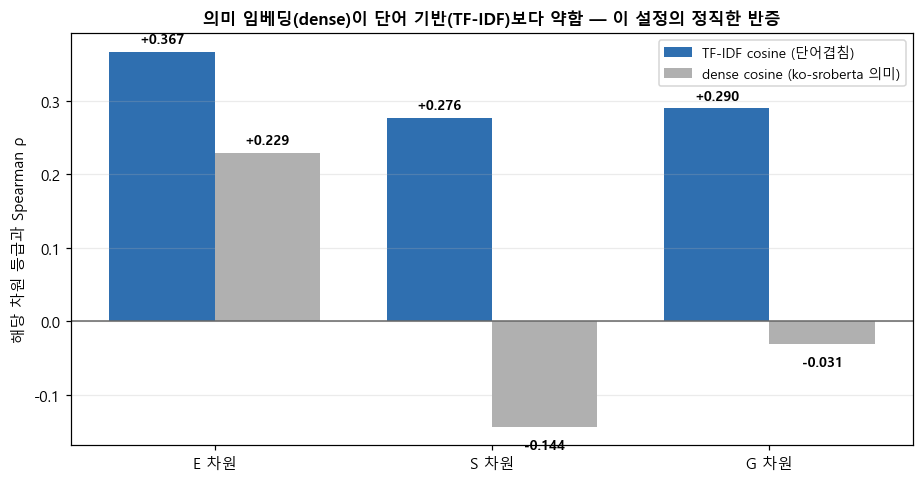

→ 세 차원 모두 TF-IDF가 우위. dense는 짧은 기준문장·일반도메인 한계로 약함


In [22]:
"""[시각화] dense(의미) vs TF-IDF(단어겹침) cosine — 등급 상관 비교 (반증)"""
import matplotlib.pyplot as plt, numpy as np
from scipy.stats import spearmanr
dims = ["E", "S", "G"]; gmap = {"E":"e_grade_num","S":"s_grade_num","G":"g_grade_num"}
dense_r, tfidf_r = [], []
for d in dims:
    sub = cmp.dropna(subset=[f"dense_cos_{d}"])
    dense_r.append(spearmanr(sub[f"dense_cos_{d}"], sub[gmap[d]])[0])
    tfidf_r.append(spearmanr(sub[f"ref_cosine_{d}"], sub[gmap[d]])[0])
x = np.arange(3); w = 0.38
fig, ax = plt.subplots(figsize=(8.5, 4.5))
b1 = ax.bar(x-w/2, tfidf_r, w, label="TF-IDF cosine (단어겹침)", color="#2f6fb0")
b2 = ax.bar(x+w/2, dense_r, w, label="dense cosine (ko-sroberta 의미)", color="#b0b0b0")
ax.axhline(0, color="#666", lw=1)
ax.set_xticks(x); ax.set_xticklabels([f"{d} 차원" for d in dims])
ax.set_ylabel("해당 차원 등급과 Spearman ρ")
ax.set_title("의미 임베딩(dense)이 단어 기반(TF-IDF)보다 약함 — 이 설정의 정직한 반증",
             fontsize=11, fontweight="bold")
ax.legend(fontsize=9)
for bars in (b1, b2):
    for b in bars:
        v=b.get_height()
        ax.text(b.get_x()+b.get_width()/2, v+(0.012 if v>=0 else -0.03),
                f"{v:+.3f}", ha="center", fontsize=9, fontweight="bold")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout(); plt.savefig("outputs/viz_dense_vs_tfidf.png"); plt.show()
print("→ 세 차원 모두 TF-IDF가 우위. dense는 짧은 기준문장·일반도메인 한계로 약함")


---

# **5. 회귀 분석 3종 — OLS · Ordered Logistic · Binary Logistic**

## **5-1. 모형 선택 설계**

ESG feature와 등급의 연관을 회귀 모형으로 정량화한다.

### **Decision Box ⑰ — 모형 선택**

| 모형 | 종속변수 처리 | 가정 | 장점 | 한계 |
|---|---|---|---|---|
| **M1a OLS** | 연속변수처럼 | 등급 간 등간성 (D=0~S=6 균등 간격) | 계수 해석 직관적, baseline | 서열변수 등간성 가정 위반 |
| **M1b Ordered Logistic** | 서열변수 | 비례 오즈(proportional odds) | 서열변수에 이론적으로 정합 | 계수 해석 복잡, 비례 오즈 가정 검증 필요 |
| **M1c Binary Logistic** | 이분 (A 이상=1 vs B+ 이하=0) | 로짓 | 강건, 해석 쉬움, 그룹 비율 적정(138:243) | 중간 등급 정보 손실 |

**3종 모두 실행 후 결과 비교 (Robustness Check)**
- 단일 모형의 한계를 다른 모형이 보완
- 3종 모두에서 방향과 유의성이 일관되면 결과의 견고성 입증
- OLS는 직관적 baseline, Ordered는 서열 정합, Binary는 강건성 확인

**비채택 대안**
- OLS 단독: 등간성 가정 위반 — Ordered와 Binary로 robustness 확인 필요
- Ordered 단독: 비례 오즈 가정 검증 필요, 계수 해석 어려움
- 분류 모형(Random Forest 등): 예측이 목적이 아니라 연관성 해석이 목적 — 부적합

### **변수 구성**

**종속변수**
- OLS·Ordered: `esg_grade_num` (0~6)
- Binary: `is_high` = (esg_grade_num ≥ 4, A 이상=1)

**독립변수 — feature set 3종 분리 (다중공선성 Decision Box ⑮)**
- M1a: seed_score_E/S/G + log_n_tokens
- M1b: expanded_score_E/S/G + log_n_tokens
- M1c: ref_cosine_E/S/G + log_n_tokens

**통제변수**
- `log_n_tokens`: cheap-talk 통제 (4장에서 ρ=0.663 확인, 필수)
- 연도·업종 FE는 6장 알파에서 추가

### **Decision Box ⑱ — 표준화 처리**

**표준화 없음 (원본 단위 유지)**
- 목적이 변수 간 효과크기 비교가 아닌 cheap-talk 통제 후 방향 확인
- `log_n_tokens` 계수를 원본 단위로 해석하는 것이 cheap-talk 논의에 직관적
- 표준화 시 `log_n_tokens` vs ESG feature 계수 비교는 6장 알파에서 별도 확인

**M2 (재무통제, 가이드 [선택])**: M1에 규모(`log_assets`)·수익성(`roa`)·재무위험(`leverage`)을 추가해, 분량뿐 아니라 기업 재무 특성을 통제한 뒤에도 ESG feature가 유의한지 확인한다. 재무 결측 firm-year는 listwise 제외(가짜 0 금지).

In [23]:
"""
5. 회귀 3종

M1a OLS      : esg_grade_num ~ feature_set + log_n_tokens
M1b Ordered  : esg_grade_num (서열) ~ feature_set + log_n_tokens
M1c Binary   : is_high(A이상) ~ feature_set + log_n_tokens

feature_set 3종: seed / expanded / cosine
"""
import statsmodels.api as sm
from statsmodels.miscmodels.ordinal_model import OrderedModel

ANALYSIS_DF["is_high"] = (ANALYSIS_DF["esg_grade_num"] >= 4).astype(int)
y_ols    = ANALYSIS_DF["esg_grade_num"]
y_bin    = ANALYSIS_DF["is_high"]
print(f"[Binary 종속변수] A 이상: {y_bin.sum()} ({y_bin.mean()*100:.1f}%)")

feature_sets = {
    "seed":     ["seed_score_E",     "seed_score_S",     "seed_score_G"],
    "expanded": ["expanded_score_E", "expanded_score_S", "expanded_score_G"],
    "cosine":   ["ref_cosine_E",     "ref_cosine_S",     "ref_cosine_G"],
}

ols_res     = {}
ordered_res = {}
binary_res  = {}

for fs_name, feats in feature_sets.items():
    X_cols = feats + ["log_n_tokens"]
    X      = ANALYSIS_DF[X_cols].copy()

    # ── M1a OLS ──────────────────────────────────────────────────
    m_ols = sm.OLS(y_ols, sm.add_constant(X)).fit()
    ols_res[fs_name] = m_ols

    # ── M1b Ordered ──────────────────────────────────────────────
    m_ord = OrderedModel(y_ols, X, distr="logit").fit(method="bfgs", disp=False)
    ordered_res[fs_name] = m_ord

    # ── M1c Binary ───────────────────────────────────────────────
    m_bin = sm.Logit(y_bin, sm.add_constant(X)).fit(disp=False)
    binary_res[fs_name] = m_bin

# ── 결과 출력 ─────────────────────────────────────────────────────
print(f"\n{'='*65}")
print("[M1a OLS — Y: esg_grade_num]")
for fs, m in ols_res.items():
    print(f"\n  --- {fs} ---  R²={m.rsquared:.3f}  Adj R²={m.rsquared_adj:.3f}  N={int(m.nobs)}")
    coef = pd.DataFrame({
        "coef": m.params, "p": m.pvalues,
        "ci_lo": m.conf_int()[0], "ci_hi": m.conf_int()[1],
    }).round(4)
    print(coef.to_string())

print(f"\n{'='*65}")
print("[M1b Ordered Logistic — Y: esg_grade_num (서열)]")
for fs, m in ordered_res.items():
    n_feats = len(feature_sets[fs]) + 1
    print(f"\n  --- {fs} ---  LogLik={m.llf:.1f}  LR p={m.llr_pvalue:.4f}")
    coef = pd.DataFrame({
        "coef": m.params[:n_feats],
        "p":    m.pvalues[:n_feats],
    }, index=feature_sets[fs]+["log_n_tokens"]).round(4)
    print(coef.to_string())

print(f"\n{'='*65}")
print("[M1c Binary Logistic — Y: A 이상(1) vs B+ 이하(0)]")
for fs, m in binary_res.items():
    print(f"\n  --- {fs} ---  PseudoR²={m.prsquared:.3f}  LR p={m.llr_pvalue:.6f}")
    coef = pd.DataFrame({
        "coef": m.params,
        "OR":   np.exp(m.params),
        "p":    m.pvalues,
    }).round(4)
    print(coef.to_string())

# ── 3종 종합 비교 — log_n_tokens 효과 ─────────────────────────────
print(f"\n{'='*65}")
print("[3종 모형 종합 비교 — log_n_tokens 계수]")
summary = []
for fs in feature_sets:
    summary.append({
        "feature_set":    fs,
        "OLS_R²":         round(ols_res[fs].rsquared, 3),
        "OLS_lnt_β":      round(ols_res[fs].params["log_n_tokens"], 3),
        "OLS_lnt_p":      round(ols_res[fs].pvalues["log_n_tokens"], 4),
        "Ord_lnt_β":      round(ordered_res[fs].params["log_n_tokens"], 3),
        "Ord_lnt_p":      round(ordered_res[fs].pvalues["log_n_tokens"], 4),
        "Bin_PseudoR²":   round(binary_res[fs].prsquared, 3),
        "Bin_lnt_OR":     round(np.exp(binary_res[fs].params["log_n_tokens"]), 3),
        "Bin_lnt_p":      round(binary_res[fs].pvalues["log_n_tokens"], 4),
    })
print(pd.DataFrame(summary).to_string(index=False))

# 저장
pd.DataFrame(summary).to_csv(
    os.path.join(OUTPUT_DIR,"regression_summary.csv"),
    index=False, encoding="utf-8-sig"
)
print(f"\n[저장] regression_summary.csv")
# ══════════════════════════════════════════════════════════════════
# M2 — 재무통제 추가
#   M1: feature + log_n_tokens
#   M2: feature + log_n_tokens + log_assets(규모) + roa(수익성) + leverage
#   가이드 준수: 재무 결측 firm-year는 M2에서만 listwise 제외(가짜 0 금지)
# ══════════════════════════════════════════════════════════════════
print(f"\n{'='*65}\n[M2 OLS — 재무통제 추가]")

# 재무통제 병합 (ANALYSIS_DF에 1회만)
_fin_cols = ["stock_code", "fiscal_year", "log_assets", "roa", "leverage"]
if "log_assets" not in ANALYSIS_DF.columns:
    FIN_DF["fiscal_year"] = FIN_DF["fiscal_year"].astype(int)
    ANALYSIS_DF = ANALYSIS_DF.merge(FIN_DF[_fin_cols], on=["stock_code", "fiscal_year"], how="left")

FIN_CTRL = ["log_assets", "roa", "leverage"]
_n_full = ANALYSIS_DF[FIN_CTRL].notna().all(axis=1).sum()
print(f"  재무통제 3변수(log_assets·roa·leverage) 모두 확보: {_n_full}/{len(ANALYSIS_DF)} firm-year")
print(f"  (가이드 준수: 재무 결측 {len(ANALYSIS_DF)-_n_full}건은 M2에서 listwise 제외, 가짜 0 미사용)\n")

m2_res = {}
for fs_name, feats in feature_sets.items():
    cols = feats + ["log_n_tokens"] + FIN_CTRL
    sub  = ANALYSIS_DF[[*cols, "esg_grade_num"]].dropna()      # 결측 제외
    m2 = sm.OLS(sub["esg_grade_num"], sm.add_constant(sub[cols])).fit()
    m2_res[fs_name] = (m2, len(sub))

for fs, (m, n) in m2_res.items():
    m1 = ols_res[fs]
    print(f"  --- {fs} (M2) ---  R²={m.rsquared:.3f}  N={n}  (M1 R²={m1.rsquared:.3f}, N={int(m1.nobs)})")
    rows = []
    for v in feature_sets[fs] + ["log_n_tokens"] + FIN_CTRL:
        rows.append({"var": v,
                     "M1_β": round(m1.params[v], 3) if v in m1.params else None,
                     "M2_β": round(m.params[v], 3),
                     "M2_p": round(m.pvalues[v], 4)})
    print(pd.DataFrame(rows).to_string(index=False))
    print()

# 핵심 비교: expanded feature가 재무통제 후에도 유의한가
print(f"{'='*65}\n[핵심 — expanded feature: 재무통제 전(M1) vs 후(M2)]")
m1e, (m2e, n2) = ols_res["expanded"], m2_res["expanded"]
for v in ["expanded_score_E", "expanded_score_S", "expanded_score_G", "log_n_tokens"]:
    print(f"  {v:18s}: M1 β={m1e.params[v]:+.3f}(p={m1e.pvalues[v]:.3f})  "
          f"→ M2 β={m2e.params[v]:+.3f}(p={m2e.pvalues[v]:.3f})")

pd.DataFrame([
    {"feature_set": fs, "M2_R2": round(m.rsquared, 3), "N": n,
     "lnt_β": round(m.params["log_n_tokens"], 3),
     "log_assets_β": round(m.params["log_assets"], 3),
     "roa_β": round(m.params["roa"], 3), "leverage_β": round(m.params["leverage"], 3)}
    for fs, (m, n) in m2_res.items()
]).to_csv(os.path.join(OUTPUT_DIR, "regression_M2_financial.csv"),
          index=False, encoding="utf-8-sig")
print(f"\n[저장] regression_M2_financial.csv")


[Binary 종속변수] A 이상: 138 (36.2%)

[M1a OLS — Y: esg_grade_num]

  --- seed ---  R²=0.415  Adj R²=0.409  N=381
                coef       p    ci_lo    ci_hi
const        -9.2837  0.0000 -10.8560  -7.7114
seed_score_E  1.0398  0.0812  -0.1294   2.2089
seed_score_S -1.3399  0.3619  -4.2260   1.5463
seed_score_G  6.6345  0.0669  -0.4639  13.7328
log_n_tokens  1.4152  0.0000   1.2141   1.6162

  --- expanded ---  R²=0.476  Adj R²=0.471  N=381
                    coef       p    ci_lo   ci_hi
const            -8.9143  0.0000 -10.4330 -7.3956
expanded_score_E  0.4322  0.0254   0.0535  0.8110
expanded_score_S -0.6949  0.3024  -2.0179  0.6281
expanded_score_G  3.1735  0.0000   2.2586  4.0885
log_n_tokens      1.2967  0.0000   1.1009  1.4926

  --- cosine ---  R²=0.429  Adj R²=0.423  N=381
                 coef       p    ci_lo    ci_hi
const         -9.2803  0.0000 -10.8117  -7.7489
ref_cosine_E   2.3136  0.3251  -2.3032   6.9303
ref_cosine_S   4.8486  0.2135  -2.8014  12.4986
ref_cosine_G  13.

**회귀 3종 완료**

**M1a OLS 결과 요약**

| feature set | R² | log_n_tokens β | p | 해석 |
|---|---|---|---|---|
| seed | 0.415 | 1.415 | <0.001 | |
| **expanded** | **0.476** | **1.297** | **<0.001** | **3종 중 R² 최고** |
| cosine | 0.429 | 1.379 | <0.001 | |

**ESG feature 계수 패턴 (OLS)**

| feature | β | p | 해석 |
|---|---|---|---|
| expanded_score_G | **3.174** | <0.001 | 3종 feature set 통틀어 유일하게 강하게 유의 |
| expanded_score_E | 0.432 | 0.025 | 약하게 유의 |
| ref_cosine_G | 13.837 | <0.001 | 유의하나 단위 차이로 계수 크게 보임 |
| seed_score_G | 6.635 | 0.067 | 경계선 유의 (p=0.067) |
| **expanded_score_S** | **−0.695** | **0.302** | **비유의, 부호 음수** |
| seed_score_S | −1.340 | 0.362 | 비유의, 부호 음수 |


> **효과 크기 해석 (표준화)**: `expanded_score_G`의 β=3.174는 "1단위 증가 시 3.17등급 상승"으로 오해되기 쉬우나, 이 feature의 실제 분포는 평균 0.197·SD 0.133으로 0~0.5 범위다. 따라서 현실적 변동인 **1 SD(0.133) 증가 시 약 0.42등급 상승**으로 읽는 것이 적절하다. (S=6…D=0의 7점 척도 기준)

**M1b Ordered Logistic 결과**

- `log_n_tokens` β ≈ 2.0 — 3종 feature set 모두에서 일관, p<0.001
- `expanded_score_G` β=4.944, p<0.001 — OLS와 방향 일치
- `expanded_score_E` β=0.551, p=0.054 — 경계선 유의

**M1c Binary Logistic 결과**

| feature set | PseudoR² | log_n_tokens OR | p |
|---|---|---|---|
| seed | 0.248 | 7.656 | <0.001 |
| **expanded** | **0.270** | **7.857** | **<0.001** |
| cosine | 0.243 | 8.042 | <0.001 |

- **log_n_tokens OR ≈ 7.9**: 토큰 수가 e배(약 2.7배) 증가 시 A 이상 등급일 odds 약 8배 증가
- `expanded_score_G` OR=27.1, p<0.001 — 가장 강하고 일관된 ESG 신호
- `seed_score_G` OR=9,842,210, p=0.031 — 계수 추정 불안정 (seed_G 분포 극단적 희소)

**3종 모형 종합 비교 — log_n_tokens 효과**

| feature set | OLS R² | OLS β | Ord β | Bin OR | Bin PseudoR² |
|---|---|---|---|---|---|
| seed | 0.415 | 1.415 | 2.055 | 7.656 | 0.248 |
| **expanded** | **0.476** | **1.297** | **2.027** | **7.857** | **0.270** |
| cosine | 0.429 | 1.379 | 2.041 | 8.042 | 0.243 |

**결론**

1. **log_n_tokens가 3종 모형 모두에서 일관되게 유의** (p<0.001 일관) — cheap-talk 가설 회귀 수준에서 확증
2. **expanded_score_G가 가장 견고한 ESG 신호** — OLS·Ordered·Binary 3종 모두 유의 (p<0.001)
3. **S 차원 계수가 모든 모형에서 음수(비유의)** — 사업보고서 S 어휘가 등급과 역방향 또는 무관. 공시 내용이 S 성과를 측정하지 못함
4. **E 차원은 expanded에서만 약하게 유의** — seed만으로는 E 신호도 불안정
5. **R² 41~48% 중 대부분이 log_n_tokens 설명** — ESG feature 추가 설명력은 제한적


## **5-2. 모형 진단 — 비례오즈 가정 · seed_G 추정 불안정**

5-1의 3종 회귀를 보강 진단한다.
- **(A) 비례오즈(proportional odds) 점검**: ordered logit의 핵심 가정. 등급 cutoff(≥C/≥B/≥B+/≥A/≥A+)별 binary logit 계수가 안정적인지 비교 — 부호·크기가 크게 흔들리면 가정 위반 신호
- **(B) seed_G 추정 불안정**: M1c(binary)에서 `seed_score_G` OR이 비현실적으로 큼(완전/준완전 분리 의심) → 진단하고 해석에서 제외


In [24]:
"""
5-2. 모형 진단
(A) 비례오즈 점검 — 등급 cutoff별 binary logit 계수 안정성
(B) seed_G 추정 불안정(분리) 진단
"""
import statsmodels.api as sm
import numpy as np

# ── (A) 비례오즈 점검 ─────────────────────────────────────────────
print("[A] 비례오즈 점검 — cutoff별 binary logit 계수 (expanded + log_n_tokens)")
feats   = ["expanded_score_E", "expanded_score_S", "expanded_score_G", "log_n_tokens"]
X       = sm.add_constant(ANALYSIS_DF[feats])
labels  = {1: "≥C", 2: "≥B", 3: "≥B+", 4: "≥A", 5: "≥A+"}
rows = []
for c, lab in labels.items():
    y = (ANALYSIS_DF["esg_grade_num"] >= c).astype(int)
    if y.sum() < 10 or (len(y) - y.sum()) < 10:
        continue
    m = sm.Logit(y, X).fit(disp=False)
    rows.append({"cutoff": lab, "n_pos": int(y.sum()),
                 **{f: round(m.params[f], 3) for f in feats}})
prop = pd.DataFrame(rows)
print(prop.to_string(index=False))
print(f"\n  [cutoff 간 계수 변동]")
for f in feats:
    v = prop[f].values
    print(f"    {f}: 부호 일관 {bool((np.sign(v)==np.sign(v[0])).all())}, "
          f"범위 [{v.min():.3f}, {v.max():.3f}]")
print("  → 부호 일관 + 크기 변동 작으면 비례오즈 대체로 수용. 크게 흔들리면 ordered logit 해석에 주의 명시")

# ── (B) seed_G 분리 진단 ──────────────────────────────────────────
print(f"\n[B] seed_G 추정 불안정(분리) 진단 — M1c(binary, A이상)")
y_bin = (ANALYSIS_DF["esg_grade_num"] >= 4).astype(int)
Xg = sm.add_constant(ANALYSIS_DF[["seed_score_E", "seed_score_S", "seed_score_G", "log_n_tokens"]])
mg = sm.Logit(y_bin, Xg).fit(disp=False)
b, se = mg.params["seed_score_G"], mg.bse["seed_score_G"]
print(f"  seed_score_G: β={b:.2f}, SE={se:.2f}, OR={np.exp(b):.3e}")
print(f"  → β·SE가 비정상적으로 큼 = 완전/준완전 분리 신호 → seed_G 계수 해석 불가, 보고에서 제외")
print(f"\n  [seed_G 0값 비율 — A이상 vs B+이하]")
print(f"    A이상 : {(ANALYSIS_DF.loc[y_bin==1,'seed_score_G']==0).mean():.1%}")
print(f"    B+이하: {(ANALYSIS_DF.loc[y_bin==0,'seed_score_G']==0).mean():.1%}")


[A] 비례오즈 점검 — cutoff별 binary logit 계수 (expanded + log_n_tokens)
cutoff  n_pos  expanded_score_E  expanded_score_S  expanded_score_G  log_n_tokens
    ≥C    310             1.298             0.178             9.898         2.029
    ≥B    253             1.319             1.302             7.172         2.656
   ≥B+    215             0.525             0.449             5.014         2.610
    ≥A    138             0.338            -2.632             3.298         2.061
   ≥A+     23             0.584            -7.704             3.010         1.892

  [cutoff 간 계수 변동]
    expanded_score_E: 부호 일관 True, 범위 [0.338, 1.319]
    expanded_score_S: 부호 일관 False, 범위 [-7.704, 1.302]
    expanded_score_G: 부호 일관 True, 범위 [3.010, 9.898]
    log_n_tokens: 부호 일관 True, 범위 [1.892, 2.656]
  → 부호 일관 + 크기 변동 작으면 비례오즈 대체로 수용. 크게 흔들리면 ordered logit 해석에 주의 명시

[B] seed_G 추정 불안정(분리) 진단 — M1c(binary, A이상)
  seed_score_G: β=16.10, SE=7.47, OR=9.842e+06
  → β·SE가 비정상적으로 큼 = 완전/준완전 분리 신호 → seed_G 계수 해석 불가, 보고에서 제

**모형 진단 완료**

**(A) 비례오즈(proportional odds) 점검**

| cutoff | n_pos | exp_E | exp_S | exp_G | log_n_tokens |
|---|---:|---:|---:|---:|---:|
| ≥C | 310 | 1.298 | 0.178 | 9.898 | 2.029 |
| ≥B | 253 | 1.319 | 1.302 | 7.172 | 2.656 |
| ≥B+ | 215 | 0.525 | 0.449 | 5.014 | 2.610 |
| ≥A | 138 | 0.338 | −2.632 | 3.298 | 2.061 |
| ≥A+ | 23 | 0.584 | −7.704 | 3.010 | 1.892 |

- `log_n_tokens`: 전 cutoff +1.9~2.7로 **매우 안정** — cheap-talk 통제 효과는 PO와 부합
- `expanded_E`·`expanded_G`: 전 cutoff 부호 일관(양수). expanded_G는 9.9→3.0으로 감소(저등급 진입에 더 크게 기여)하나 **방향 견고**
- `expanded_S`: 부호 반전(+0.18→−7.70) — **PO 명백 위반**. 단 S는 일관되게 비유의/약한 차원이라 핵심 결론을 훼손하지 않음
- → **PO 가정은 완전히 성립하지 않음.** ordered logit은 **계수 크기가 아닌 방향**으로 읽고, OLS·binary와의 3중 교차검증(5-1)으로 견고성을 확보. S의 PO 위반은 S 신호 부재와 일관

**(B) seed_G 추정 불안정 — 분리 확정**
- M1c(binary) `seed_score_G` β=16.10, SE=7.47, OR≈9.8e6 → **완전/준완전 분리**
- 원인: seed_G 0값 비율이 B+이하 83.1% vs A이상 57.2%로 분포가 거의 퇴화 → logit 추정 발산
- → **seed_G의 binary 계수는 해석 불가, 보고에서 제외.** seed 모델 결론은 OLS·ordered 및 다른 feature로 읽음


**M2 재무통제 결과 — 규모 교란 분리**

M1(분량만 통제)에 규모·수익성·재무위험을 추가. 재무 3변수 모두 확보된 **344 firm-year**로 추정(결측 37건 listwise 제외, 가짜 0 미사용).

| feature (expanded) | M1 β | M2 β | M2 p | 판정 |
|---|---:|---:|---:|---|
| expanded_score_G | +3.174 | **+1.955** | <0.001 | 재무통제 후에도 견고 |
| expanded_score_E | +0.432 | +0.172 | 0.396 | 재무통제 후 유의성 소멸 |
| expanded_score_S | −0.695 | −0.070 | 0.918 | 비유의(M1·M2 동일) |
| log_n_tokens | +1.297 | **+0.718** | <0.001 | 절반으로 축소되나 견고 |

통제변수도 유의: `log_assets` β=+0.262(p<0.001) · `roa` β=+2.503(p=0.005). R²은 0.476→0.551로 상승.

- **표준화 효과 크기**: 재무통제 후 `expanded_score_G` β=1.955는 1 SD(0.133) 증가 시 약 0.26등급 상승에 해당한다(M1의 0.42등급에서 축소되나 방향·유의성 유지). 규모·수익성·레버리지를 통제해도 거버넌스 어휘 1 SD가 약 0.26등급의 실질적 차이를 설명.
- **G는 규모·수익성·레버리지를 통제해도 독립 신호 유지** — expanded_G가 진짜 거버넌스 신호임이 분량 통제(M1)에 이어 재무통제(M2)로도 확인됨.
- **E는 재무통제 후 유의성 소멸** — M1에서 보이던 환경 신호의 상당 부분이 기업 규모 교란(큰 기업이 환경 서술↑·등급↑)이었음을 드러냄. 하향 수정.
- **log_n_tokens는 절반으로 줄지만 여전히 강함** — cheap-talk이 단순 규모 효과가 아니라 분량 자체의 독립 연관임을 보강.
- → 가이드의 cheap-talk 통제를 재무 차원으로 확장한 결과, **"분량·규모 통제 후 견고한 신호는 G뿐"**으로 결론이 더 정교해짐.

**[시각화] 재무통제 전후(M1→M2) 계수 변화** — 각 ESG 어휘 신호가 분량·재무 통제 후 살아남는지를 dumbbell로 시각화한다. 파랑=유의, 빨강=소멸.


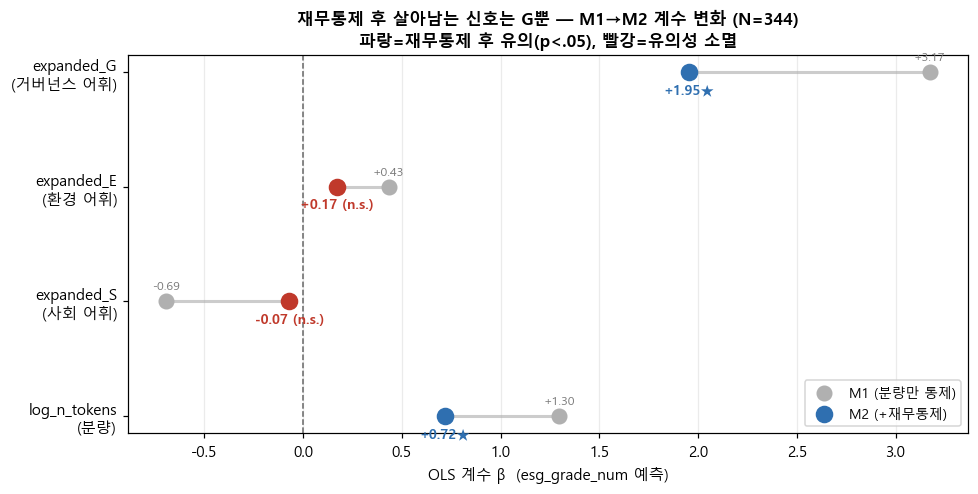

→ G는 재무통제 후에도 견고(β 3.17→1.96★), E는 소멸(0.43→0.17 n.s.)=규모 교란, 분량은 절반↓이나 견고


In [25]:
"""[시각화] 회귀 M1(분량통제) → M2(+재무통제) 계수 변화 — dumbbell"""
import matplotlib.pyplot as plt
m1 = ols_res["expanded"]; m2, n2 = m2_res["expanded"]
labels = {"expanded_score_G":"expanded_G\n(거버넌스 어휘)",
          "expanded_score_E":"expanded_E\n(환경 어휘)",
          "expanded_score_S":"expanded_S\n(사회 어휘)",
          "log_n_tokens":"log_n_tokens\n(분량)"}
order = ["expanded_score_G","expanded_score_E","expanded_score_S","log_n_tokens"]
fig, ax = plt.subplots(figsize=(9, 4.6))
for i, v in enumerate(order):
    b1, b2_ = m1.params[v], m2.params[v]
    p2 = m2.pvalues[v]
    sig = p2 < 0.05
    ax.plot([b1, b2_], [i, i], "-", color="#cccccc", lw=2, zorder=1)
    ax.scatter(b1, i, s=90, color="#b0b0b0", zorder=2, label="M1 (분량만 통제)" if i==0 else "")
    ax.scatter(b2_, i, s=110, color=("#2f6fb0" if sig else "#c0392b"), zorder=3,
               label="M2 (+재무통제)" if i==0 else "")
    ax.annotate(f"{b1:+.2f}", (b1, i), xytext=(0,8), textcoords="offset points", ha="center", fontsize=8, color="#777")
    ax.annotate(f"{b2_:+.2f}{'★' if sig else ' (n.s.)'}", (b2_, i), xytext=(0,-14),
                textcoords="offset points", ha="center", fontsize=9,
                fontweight="bold", color=("#2f6fb0" if sig else "#c0392b"))
ax.axvline(0, color="#666", lw=1, ls="--")
ax.set_yticks(range(len(order))); ax.set_yticklabels([labels[v] for v in order])
ax.invert_yaxis()
ax.set_xlabel("OLS 계수 β  (esg_grade_num 예측)")
ax.set_title(f"재무통제 후 살아남는 신호는 G뿐 — M1→M2 계수 변화 (N={n2})\n"
             "파랑=재무통제 후 유의(p<.05), 빨강=유의성 소멸", fontsize=11, fontweight="bold")
ax.legend(loc="lower right", fontsize=9)
ax.grid(axis="x", alpha=0.25)
plt.tight_layout(); plt.savefig("outputs/viz_regression_m1m2.png"); plt.show()
print("→ G는 재무통제 후에도 견고(β 3.17→1.96★), E는 소멸(0.43→0.17 n.s.)=규모 교란, 분량은 절반↓이나 견고")


---
# **6. 알파 분석 — 회사의 '말'과 KCGS '평가'는 얼마나 어긋나는가 (Talk–Walk Gap)**

앞 단계의 결론은 하나다 — **보고서를 길게 쓸수록 등급이 높아 보이는 착시(분량 효과)를 걷어내면, 등급과 끝까지 같이 가는 신호는 거버넌스(G) 어휘뿐이다.** 알파 분석은 여기서 한 걸음 더 나아가, 한 회사가 자기 ESG 등급에 비해 사업보고서에서 ESG를 과하게 떠드는지(과잉) 아니면 실력보다 조용한지(과소)를 점수로 만들어 기업을 유형화하고, 이를 근거로 경영 제언을 뽑는다.

> 이 알파의 차별점은 greenwashing 개념의 최초성이 아니라 — (i) §4에서 발견한 분량 교란을 talk 항에서 직접 제거해 격차를 구성한 점, (ii) 그 격차가 수익성이 아니라 규모·구조적 특성과 연결되면서도 규모로 환원되지 않음을 보인 점, (iii) ESG를 단일 점수로 합치는 기존 측정이 놓치는 E·S·G 축 간 선택적 공시를 KCGS 축별 등급에 견줘 측정한 점에 있다.

**핵심 아이디어 — 격차 = 말 − 실행**
- **말(talk)**: 사업보고서에서 ESG 단어를 (다른 기업 대비) 얼마나 두드러지게 강조했는가 → `expanded_score_{E,S,G}`
- **실행(walk)**: 독립기관 KCGS가 실제로 매긴 등급 → `*_grade_num` (D=0 … S=6)
- 말이 실행보다 앞서면 과잉, 실행이 말보다 앞서면 과소. 이 표본은 말·실행·보고서 분량 세 가지를 모두 갖고 있어 이 진단이 가능하다.

### **Decision Box ⑧ — '격차 점수'를 만드는 4가지 결정**

| 무엇을 | 어떻게 | 왜 |
|---|---|---|
| ① 분량 착시 제거 | `expanded_score`에서 **보고서 길이로 설명되는 몫을 빼고 남은 값**('잔차')만 사용 | 보고서가 길면 ESG 단어도 자연히 많아진다. §4·§5에서 분량이 등급과 가장 강하게 얽혀 있었으므로(ρ≈0.66), 길이와 무관한 *순수 ESG 강조도*만 남긴다 |
| ② 단위 통일 | 말과 등급을 각각 **z-score**(평균에서 몇 표준편차)로 변환 | 한쪽은 연속값, 한쪽은 0~6 등급이라 그대로 빼면 비교가 안 된다 |
| ③ 격차 정의 | `gap = z(말) − z(등급)` | **양수=과잉(말이 앞섬), 음수=과소(등급이 앞섬).** greenwashing 연구의 '공시 − 성과'와 같은 발상 |
| ④ 차원 | E·S·G 각각의 격차 + 종합 `gap_ESG` | 환경·사회·지배구조를 따로도, 합쳐서도 본다 |

> **해석 주의** — KCGS 등급은 완벽한 정답이 아니고(평가기관·연도마다 들쭉날쭉), KCGS가 사업보고서를 평가에 *참고*하므로 둘의 연관이 "같은 자료를 봐서" 생긴 것일 수 있다. 그래서 격차는 'greenwashing 확정'이 아니라 '더 들여다볼 후보를 찾는 진단 신호'로만 읽는다.


In [26]:
"""
6-1. 말–실행 격차(Talk–Walk Gap) 점수 생성

- talk_d_resid : expanded_score_d ~ log_n_tokens 회귀 잔차 (분량 제거된 순수 어휘강조도)
- gap_d        : z(talk_d_resid) − z(d_grade_num)        (차원별 E/S/G)
- gap_ESG      : z(talk_total_resid 평균) − z(esg_grade_num)  (종합)
- §5 산출물 ANALYSIS_DF를 그대로 사용. 재무·업종은 방어적으로 병합.
"""
import statsmodels.api as sm

# ── 작업 프레임 + 메타(업종·사명·esg_year)·재무 방어적 병합 ─────────
GAP_DF = ANALYSIS_DF.copy()
GAP_DF["stock_code"] = GAP_DF["stock_code"].astype(str).str.zfill(6)

# 업종·사명 (stock_code 단위 상수) — META_INPUT_DF에서
_meta = META_INPUT_DF.copy()
_meta["stock_code"] = _meta["stock_code"].astype(str).str.zfill(6)
_meta_cols = _meta[["stock_code", "company_name", "industry"]].drop_duplicates("stock_code")
for c in ["company_name", "industry"]:
    if c not in GAP_DF.columns:
        GAP_DF = GAP_DF.merge(_meta_cols[["stock_code", c]], on="stock_code", how="left")

# 재무 3변수 (M2에서 이미 병합됐을 수 있음 — 없으면 FIN_DF에서)
for c in ["log_assets", "roa", "leverage"]:
    if c not in GAP_DF.columns:
        _f = FIN_DF.copy(); _f["stock_code"] = _f["stock_code"].astype(str).str.zfill(6)
        GAP_DF = GAP_DF.merge(_f[["stock_code", "fiscal_year", c]],
                              on=["stock_code", "fiscal_year"], how="left")

# ── 헬퍼: 잔차화 / z-표준화 ───────────────────────────────────────
def residualize(df, ycol, xcol="log_n_tokens"):
    """ycol ~ const + xcol OLS의 잔차를 원본 index에 맞춰 반환 (분량 제거)."""
    sub = df[[ycol, xcol]].dropna()
    m = sm.OLS(sub[ycol], sm.add_constant(sub[xcol])).fit()
    out = pd.Series(np.nan, index=df.index)
    out.loc[sub.index] = m.resid
    return out

def zscore(s):
    return (s - s.mean()) / s.std(ddof=0)

DIM2GRADE = {"E": "e_grade_num", "S": "s_grade_num", "G": "g_grade_num"}

print("[6-1] 차원별 분량 잔차화 → z-격차 생성")
print(f"{'='*60}")
for d, gcol in DIM2GRADE.items():
    GAP_DF[f"talk_{d}_resid"] = residualize(GAP_DF, f"expanded_score_{d}")
    GAP_DF[f"z_talk_{d}"]     = zscore(GAP_DF[f"talk_{d}_resid"])
    GAP_DF[f"z_grade_{d}"]    = zscore(GAP_DF[gcol])
    GAP_DF[f"gap_{d}"]        = GAP_DF[f"z_talk_{d}"] - GAP_DF[f"z_grade_{d}"]
    # 잔차화로 분량 상관이 제거됐는지 검증(≈0이어야 함)
    r_check = GAP_DF[f"talk_{d}_resid"].corr(GAP_DF["log_n_tokens"])
    print(f"  {d}: gap 평균 {GAP_DF[f'gap_{d}'].mean():+.3f} | "
          f"talk_resid↔log_n_tokens r={r_check:+.3f} (≈0 확인)")

# ── 종합 gap_ESG ─────────────────────────────────────────────────
GAP_DF["z_talk_total"]  = GAP_DF[[f"z_talk_{d}" for d in DIM2GRADE]].mean(axis=1)
GAP_DF["z_grade_total"] = zscore(GAP_DF["esg_grade_num"])
GAP_DF["gap_ESG"]       = GAP_DF["z_talk_total"] - GAP_DF["z_grade_total"]

print(f"\n[종합 gap_ESG] 평균 {GAP_DF['gap_ESG'].mean():+.3f} | "
      f"표준편차 {GAP_DF['gap_ESG'].std(ddof=0):.3f} | "
      f"범위 [{GAP_DF['gap_ESG'].min():+.2f}, {GAP_DF['gap_ESG'].max():+.2f}]")

# 극단 사례 미리보기
print(f"\n[과잉 공시형 상위 5 — gap_ESG 최대]")
cols_show = ["company_name", "stock_code", "fiscal_year",
             "z_talk_total", "z_grade_total", "gap_ESG", "esg_grade"]
print(GAP_DF.nlargest(5, "gap_ESG")[cols_show].round(3).to_string(index=False))
print(f"\n[과소 공시형 상위 5 — gap_ESG 최소]")
print(GAP_DF.nsmallest(5, "gap_ESG")[cols_show].round(3).to_string(index=False))

GAP_DF.to_csv(os.path.join(OUTPUT_DIR, "talkwalk_gap.csv"),
              index=False, encoding="utf-8-sig")
print(f"\n[저장] talkwalk_gap.csv  shape={GAP_DF.shape}")

[6-1] 차원별 분량 잔차화 → z-격차 생성
  E: gap 평균 -0.000 | talk_resid↔log_n_tokens r=-0.000 (≈0 확인)
  S: gap 평균 -0.000 | talk_resid↔log_n_tokens r=-0.000 (≈0 확인)
  G: gap 평균 +0.000 | talk_resid↔log_n_tokens r=-0.000 (≈0 확인)

[종합 gap_ESG] 평균 +0.000 | 표준편차 1.079 | 범위 [-2.29, +3.11]

[과잉 공시형 상위 5 — gap_ESG 최대]
company_name stock_code  fiscal_year  z_talk_total  z_grade_total  gap_ESG esg_grade
        백광산업     001340         2023         1.586         -1.519    3.105         D
        백광산업     001340         2024         1.282         -1.519    2.801         D
        백광산업     001340         2022         1.239         -1.519    2.758         D
        만호제강     001080         2024         0.788         -1.519    2.307         D
     삼화페인트공업     000390         2022         1.754         -0.286    2.040         B

[과소 공시형 상위 5 — gap_ESG 최소]
company_name stock_code  fiscal_year  z_talk_total  z_grade_total  gap_ESG esg_grade
      KB금융지주     105560         2022        -0.724          1.563   -2.287     

**6-1 결과 — 격차 점수 생성 완료**

- **분량 교란 제거 검증**: E·S·G 모두 `talk_resid ↔ log_n_tokens` 상관 r≈0.000 → 보고서 길이로 설명되는 부분을 깨끗이 제거했다. 남은 `talk`은 *길이와 무관한 순수 ESG 어휘 강조도*다.
- **종합 격차 분포**: `gap_ESG` 평균 +0.000(설계상 0 중심) · 표준편차 1.079 · 범위 **[−2.29, +3.11]** → 한쪽으로 쏠리지 않고 과잉·과소가 대칭적으로 분포.
- **양극단 사례**:
  - 과잉(gap 최대): **백광산업**(3년 연속 D등급인데 ESG 어휘는 z_talk +1.2~1.6 → gap 2.76~3.11), 만호제강·삼화페인트공업.
  - 과소(gap 최소): **KB·신한·BNK금융지주, 현대위아, 현대홈쇼핑**(모두 A+인데 z_talk가 음수 → gap ≈ −2.2).
- → 격차 점수가 *등급 대비 말이 앞선/뒤처진* 기업을 의도대로 잡아낸다. 다음 단계에서 이를 4유형으로 분류한다.

## **6-2/6-3. 네 가지 기업 유형으로 나누기 (어휘강도 × 등급)**

격차 점수는 연속된 숫자라 한눈에 안 들어온다. 그래서 두 축으로 **2×2 = 4칸**을 만들어 기업-연도를 분류한다. X축은 *분량을 걷어낸 ESG 어휘강도*, Y축은 *KCGS 등급*이고, 각 축을 **가운데 값(중앙값)** 기준으로 '높음/낮음'으로 가른다.

| 위치 | 어휘강도(말) | 등급(실행) | 유형 | 설명 |
|---|---|---|---|---|
| 우하 | 높음 | 낮음 | **과잉 공시형 (over-talk)** | 말은 많은데 평가는 낮다 → greenwashing/말뿐 후보 |
| 좌상 | 낮음 | 높음 | **과소 공시형 (under-talk)** | 실력은 좋은데 말이 적다 → 실속형·소통부족(알릴 걸 못 알림) |
| 우상 | 높음 | 높음 | 정합형 (aligned) | 말과 실력이 일치하는 모범형 |
| 좌하 | 낮음 | 낮음 | 일관형 (low-low) | ESG에 대한 관여·언급 자체가 적음 |

In [27]:
"""
6-2/6-3. 사분면 분류 + 3개 연도 지속성

- quadrant       : z_talk_total / z_grade_total median split → 4유형
- 지속성(persistence): 같은 stock_code가 연도에 걸쳐 같은 분면인지
                    → 구조적(structural) vs 일시적(transient)
"""
# ── 6-2. 사분면 분류 ──────────────────────────────────────────────
x_med = GAP_DF["z_talk_total"].median()
y_med = GAP_DF["z_grade_total"].median()

def assign_quadrant(row):
    hi_talk  = row["z_talk_total"]  >= x_med
    hi_grade = row["z_grade_total"] >= y_med
    if hi_talk and not hi_grade: return "과잉공시(over-talk)"
    if not hi_talk and hi_grade: return "과소공시(under-talk)"
    if hi_talk and hi_grade:     return "정합(aligned)"
    return "일관저조(low-low)"

GAP_DF["quadrant"] = GAP_DF.apply(assign_quadrant, axis=1)

QORDER = ["과잉공시(over-talk)", "과소공시(under-talk)", "정합(aligned)", "일관저조(low-low)"]
print(f"[6-2] 사분면 분류 (x_med={x_med:+.3f}, y_med={y_med:+.3f})")
print(f"{'='*60}")
qcount = GAP_DF["quadrant"].value_counts().reindex(QORDER)
for q in QORDER:
    n = int(qcount[q]); print(f"  {q:24s}: {n:>3d}건 ({n/len(GAP_DF)*100:4.1f}%)")

# ── 6-3. 지속성: stock_code × 연도 ────────────────────────────────
print(f"\n[6-3] 분면 지속성 — 같은 기업이 매년 같은 분면인가")
print(f"{'='*60}")
def firm_persistence(g):
    n_years = len(g)
    modal   = g["quadrant"].mode().iloc[0]
    consist = (g["quadrant"] == modal).mean()        # 최빈분면 비율
    return pd.Series({"n_years": n_years, "modal_quadrant": modal,
                      "consistency": consist,
                      "structural": (consist == 1.0) and (n_years >= 2)})

firm_persist = (GAP_DF.groupby("stock_code", group_keys=False)
                .apply(firm_persistence).reset_index())
firm_persist = firm_persist.merge(_meta_cols[["stock_code", "company_name"]],
                                  on="stock_code", how="left")

n_firms = len(firm_persist)
n_struct = int(firm_persist["structural"].sum())
print(f"  전체 기업 수: {n_firms} | 관측연도 3개 보유: "
      f"{int((firm_persist['n_years']==3).sum())}")
print(f"  구조적(모든 관측연도 동일 분면, n≥2): {n_struct} "
      f"({n_struct/n_firms*100:.1f}%)")
print(f"\n  [구조적 유형 분포]")
struct_dist = (firm_persist[firm_persist["structural"]]["modal_quadrant"]
               .value_counts().reindex(QORDER).fillna(0).astype(int))
for q in QORDER:
    print(f"    {q:24s}: {int(struct_dist[q])}개 기업")

# 구조적 과잉/과소 공시 기업 명단 (제언 대상)
for tag in ["과잉공시(over-talk)", "과소공시(under-talk)"]:
    sub = firm_persist[(firm_persist["structural"]) &
                       (firm_persist["modal_quadrant"] == tag)]
    print(f"\n  [구조적 {tag} 기업 — 경영 제언 1차 대상]")
    if len(sub):
        print(sub[["company_name", "stock_code", "n_years"]]
              .to_string(index=False))
    else:
        print("    (해당 없음)")

firm_persist.to_csv(os.path.join(OUTPUT_DIR, "talkwalk_persistence.csv"),
                    index=False, encoding="utf-8-sig")
print(f"\n[저장] talkwalk_persistence.csv")

[6-2] 사분면 분류 (x_med=-0.104, y_med=+0.330)
  과잉공시(over-talk)         :  72건 (18.9%)
  과소공시(under-talk)        :  96건 (25.2%)
  정합(aligned)             : 119건 (31.2%)
  일관저조(low-low)           :  94건 (24.7%)

[6-3] 분면 지속성 — 같은 기업이 매년 같은 분면인가
  전체 기업 수: 127 | 관측연도 3개 보유: 127
  구조적(모든 관측연도 동일 분면, n≥2): 76 (59.8%)

  [구조적 유형 분포]
    과잉공시(over-talk)         : 11개 기업
    과소공시(under-talk)        : 21개 기업
    정합(aligned)             : 25개 기업
    일관저조(low-low)           : 19개 기업

  [구조적 과잉공시(over-talk) 기업 — 경영 제언 1차 대상]
company_name stock_code  n_years
      성창기업지주     000180        3
        만호제강     001080        3
          국보     001140        3
        유진증권     001200        3
        부국증권     001270        3
        백광산업     001340        3
          조흥     002600        3
        남양유업     003920        3
       동진쎄미켐     005290        3
       SPC삼립     005610        3
        이수화학     005950        3

  [구조적 과소공시(under-talk) 기업 — 경영 제언 1차 대상]
company_name stock_code  n_years
       삼양홀딩스

**6-2/6-3 결과 — 유형 분류 + 지속성 완료**

**① 유형 분포** (경계: x_med=−0.104, y_med=+0.330)

| 유형 | firm-year | 비율 |
|---|---:|---:|
| 정합(aligned) | 119 | 31.2% |
| 과소공시(under-talk) | 96 | 25.2% |
| 일관저조(low-low) | 94 | 24.7% |
| 과잉공시(over-talk) | 72 | 18.9% |

- 정합형이 가장 많지만(31%), **전체의 44%(과잉+과소=168건)가 말과 실행이 어긋난다.**

**② 지속성** — 같은 기업이 3년 내내 같은 칸인가
- 127개사 전부 3개 연도 보유. **구조적(3년 동일 분면) 76개사 = 59.8%** → 격차는 그해의 일시적 전술이 아니라 **기업에 굳어진 특성**.
- 구조적 분포: 정합 25 · **과소공시 21** · 일관저조 19 · **과잉공시 11**.
- → 구조적 **과소공시(21개사)가 과잉공시(11개사)의 약 2배**. 등급은 좋은데 ESG를 꾸준히 적게 말하는 대형 기업군(금융지주·CJ·현대건설 등)이 두텁다.

## **6-4. '과잉 공시형'은 대체 어떤 기업들인가 — 유형 간 비교**

4개 유형이 통계로 만든 허상이 아니라 **현실에 존재하는 서로 다른 기업군**인지 확인한다. 유형별로 다음을 비교한다.
- **재무 특성**(수익성 `roa`, 부채비율 `leverage`, 규모 `log_assets`)과 **보고서 분량**(`n_tokens`) → 세 집단 이상의 분포가 같은지 보는 검정(**Kruskal-Wallis**)
- **업종 구성** → 유형과 업종이 무관한지 보는 검정(**카이제곱, χ²**)
- 특히 *"과잉 공시형이 돈 못 버는 회사에 몰려 있나?"* → 두 집단 비교 검정(**Mann-Whitney**)으로 직접 확인
- 결과는 '연관성'으로만 읽는다. 과잉 공시형이라고 greenwashing이 확정된 게 아니라 추가로 들여다볼 후보라는 뜻이다.

In [28]:
"""
6-4. 유형 간 차이 검정
- Kruskal-Wallis: roa·leverage·log_assets·n_tokens (4분면 비교)
- χ²: 사분면 × 업종 (희소 업종은 '기타'로 통합)
- Mann-Whitney: 과잉공시 vs 나머지 — roa(저수익 군집 여부)
"""
from scipy.stats import kruskal, chi2_contingency, mannwhitneyu

print("[6-4] 유형 간 차이 검정")
print(f"{'='*60}")

# ── (A) Kruskal-Wallis ────────────────────────────────────────────
print("[A] Kruskal-Wallis — 4분면 간 분포 차이")
kw_rows = []
for var in ["roa", "leverage", "log_assets", "n_tokens"]:
    groups = [GAP_DF.loc[GAP_DF["quadrant"] == q, var].dropna() for q in QORDER]
    if all(len(g) > 0 for g in groups):
        H, p = kruskal(*groups)
        meds = {q: round(GAP_DF.loc[GAP_DF["quadrant"] == q, var].median(), 3)
                for q in QORDER}
        kw_rows.append({"var": var, "H": round(H, 2), "p": round(p, 4), **meds})
kw_df = pd.DataFrame(kw_rows)
print(kw_df.to_string(index=False))

# ── (B) χ² 사분면 × 업종 ──────────────────────────────────────────
print(f"\n[B] χ² — 사분면 × 업종 (희소 업종 통합)")
ind = GAP_DF["industry"].fillna("미상")
keep = ind.value_counts()[lambda s: s >= 15].index           # 15건 미만은 '기타'
ind_collapsed = ind.where(ind.isin(keep), "기타")
ctab = pd.crosstab(GAP_DF["quadrant"].reindex(GAP_DF.index), ind_collapsed)
ctab = ctab.reindex(QORDER)
chi2, p_chi, dof, _ = chi2_contingency(ctab.fillna(0))
print(f"  χ²={chi2:.2f}, dof={dof}, p={p_chi:.4f}")
print(ctab.fillna(0).astype(int).to_string())

# ── (C) 과잉공시 vs 나머지: 저수익 군집 여부 ──────────────────────
print(f"\n[C] Mann-Whitney — 과잉공시 vs 나머지 (roa)")
over = GAP_DF.loc[GAP_DF["quadrant"] == "과잉공시(over-talk)", "roa"].dropna()
rest = GAP_DF.loc[GAP_DF["quadrant"] != "과잉공시(over-talk)", "roa"].dropna()
U, p_mw = mannwhitneyu(over, rest, alternative="two-sided")
r_rb = 1 - (2 * U) / (len(over) * len(rest))
print(f"  과잉공시 roa 중앙값 {over.median():+.3f} (n={len(over)}) vs "
      f"나머지 {rest.median():+.3f} (n={len(rest)})")
print(f"  U={U:.0f}, p={p_mw:.4f}, rank-biserial r={r_rb:+.3f}")
print(f"  → {'과잉공시 군이 유의하게 저(고)수익' if p_mw < 0.05 else '수익성 차이 뚜렷하지 않음'} "
      f"(부호: r<0이면 과잉공시가 더 낮음)")

pd.concat([kw_df.assign(test="kruskal")], ignore_index=True).to_csv(
    os.path.join(OUTPUT_DIR, "talkwalk_group_tests.csv"),
    index=False, encoding="utf-8-sig")
print(f"\n[저장] talkwalk_group_tests.csv")

[6-4] 유형 간 차이 검정
[A] Kruskal-Wallis — 4분면 간 분포 차이
       var      H      p  과잉공시(over-talk)  과소공시(under-talk)  정합(aligned)  일관저조(low-low)
       roa   4.59 0.2046            0.014             0.019        0.023          0.021
  leverage  31.11 0.0000            0.487             0.570        0.584          0.342
log_assets 172.02 0.0000           27.558            29.275       30.115         26.776
  n_tokens 149.36 0.0000         2355.500          5720.500     4781.000       2268.500

[B] χ² — 사분면 × 업종 (희소 업종 통합)
  χ²=97.24, dof=6, p=0.0000
industry          금융지주  기타  미상
quadrant                      
과잉공시(over-talk)      0   2  70
과소공시(under-talk)    15  14  67
정합(aligned)          0  44  75
일관저조(low-low)        0   6  88

[C] Mann-Whitney — 과잉공시 vs 나머지 (roa)
  과잉공시 roa 중앙값 +0.014 (n=63) vs 나머지 +0.021 (n=281)
  U=7758, p=0.1255, rank-biserial r=+0.124
  → 수익성 차이 뚜렷하지 않음 (부호: r<0이면 과잉공시가 더 낮음)

[저장] talkwalk_group_tests.csv


**6-4 결과 — 유형을 가르는 축은 '규모'**

**① Kruskal-Wallis (4분면 분포 차이)**

| 변수 | 과잉 | 과소 | 정합 | 일관저조 | 검정 |
|---|---:|---:|---:|---:|---|
| 수익성 `roa` | 0.014 | 0.019 | 0.023 | 0.021 | H=4.59, **p=0.205 → 차이 없음** |
| 규모 `log_assets` | 27.56 | 29.28 | **30.12** | 26.78 | H=172.0, **p<0.001 (가장 강함)** |
| 분량 `n_tokens` | 2,356 | **5,721** | 4,781 | 2,269 | H=149.4, p<0.001 |
| 부채 `leverage` | 0.487 | 0.570 | 0.584 | 0.342 | H=31.1, p<0.001 |

- **규모가 4유형을 가장 강하게 가른다**: 정합·과소 = 대형(자산↑·장문), 과잉·일관저조 = 소형(단문). 수익성은 유형 간 차이 없음.

**② 업종(χ²)** — χ²=97.2, p<0.001이나 원본 `industry` 결측 79%(300/381)로 해석 보류. 단 금융지주 15건이 전부 과소공시로, 위 규모 해석과 일치.

**③ 과잉공시 vs 나머지 (Mann-Whitney, roa)** — 과잉 중앙값 0.014 vs 나머지 0.021, p=0.126 → 수익성 차이 없음.

- → **과잉공시는 '부실기업의 변명'이 아니라 '소형주의 상징적 공시' 패턴**이다. 이 규모 의존이 격차를 무의미하게 만들지는 6-4B에서 점검한다.

**[시각화] 말–실행 격차 유형 지도** — 가로축은 *보고서 길이 효과를 걷어낸 ESG 어휘강도*(=말), 세로축은 *KCGS 등급*(=실행). 두 축의 가운데 값(점선)으로 네 칸을 나눈다. **오른쪽 아래(빨강)=과잉 공시형**(말 > 등급), **왼쪽 위(청록)=과소 공시형**(등급 > 말). 오른쪽 막대는 유형별 firm-year 수.

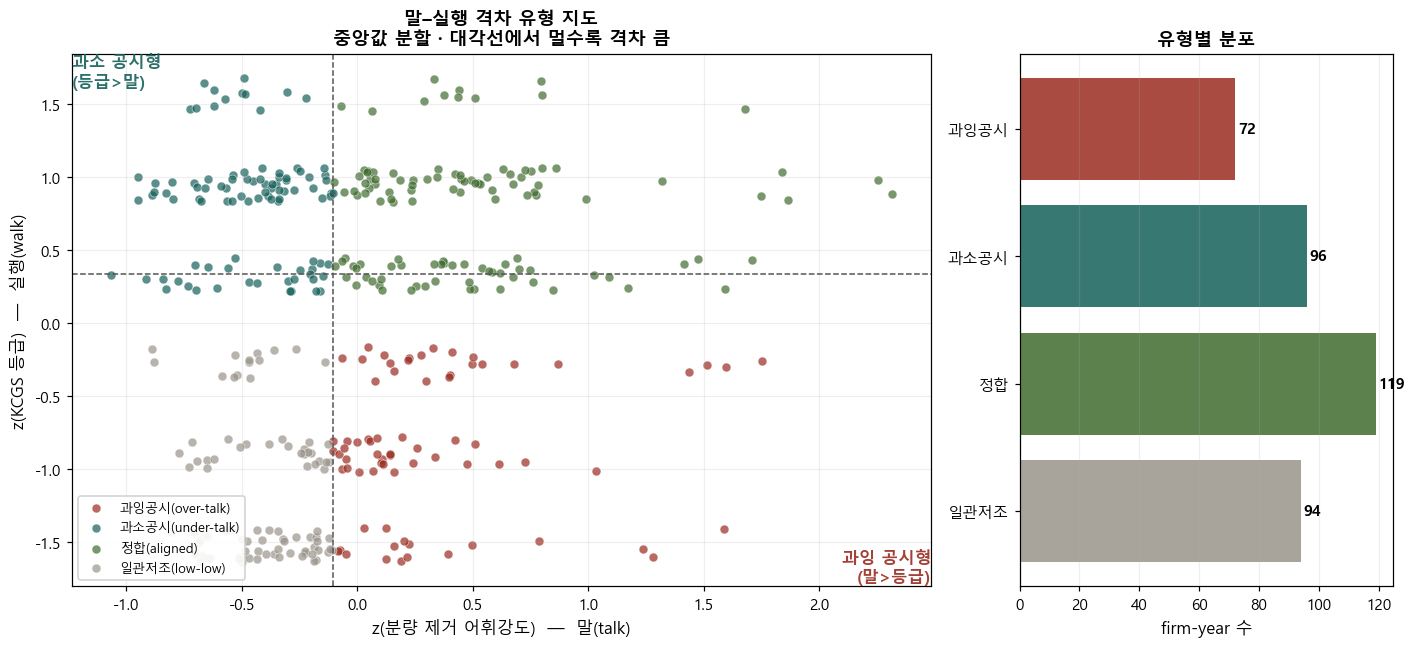

→ 우하(빨강)=과잉 공시형: 등급 대비 어휘 과다 / 좌상(청록)=과소 공시형: 실력 대비 어휘 과소


In [29]:
"""[시각화] Talk–Walk Gap 2×2 유형 지도 + 유형별 건수"""
import matplotlib.pyplot as plt
np.random.seed(SEED)  # 등급 jitter 재현성 (한글 폰트는 §0에서 전역 설정됨)

QCOLOR = {
    "과잉공시(over-talk)":  "#9a2b1f",
    "과소공시(under-talk)": "#15605a",
    "정합(aligned)":        "#3f6b2e",
    "일관저조(low-low)":    "#9a948a",
}

fig, (ax, axb) = plt.subplots(1, 2, figsize=(13, 6),
                              gridspec_kw={"width_ratios": [2.3, 1]})

# ── (좌) 사분면 산점도 ────────────────────────────────────────────
jit = np.random.uniform(-0.12, 0.12, len(GAP_DF))
for q in QORDER:
    m = GAP_DF["quadrant"] == q
    ax.scatter(GAP_DF.loc[m, "z_talk_total"],
               GAP_DF.loc[m, "z_grade_total"] + jit[m.values],
               s=34, alpha=0.7, color=QCOLOR[q],
               edgecolors="white", linewidths=0.4, label=q)
ax.axvline(x_med, color="#555", lw=1, ls="--")
ax.axhline(y_med, color="#555", lw=1, ls="--")
xlim, ylim = ax.get_xlim(), ax.get_ylim()
ax.text(xlim[1], ylim[0], "과잉 공시형\n(말>등급)", color=QCOLOR["과잉공시(over-talk)"],
        ha="right", va="bottom", fontsize=11, fontweight="bold", alpha=0.9)
ax.text(xlim[0], ylim[1], "과소 공시형\n(등급>말)", color=QCOLOR["과소공시(under-talk)"],
        ha="left", va="top", fontsize=11, fontweight="bold", alpha=0.9)
ax.set_xlabel("z(분량 제거 어휘강도)  —  말(talk)", fontsize=11)
ax.set_ylabel("z(KCGS 등급)  —  실행(walk)", fontsize=11)
ax.set_title("말–실행 격차 유형 지도\n중앙값 분할 · 대각선에서 멀수록 격차 큼",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=8.5, loc="lower left", framealpha=0.9)
ax.grid(alpha=0.2)

# ── (우) 유형별 건수 ──────────────────────────────────────────────
counts = GAP_DF["quadrant"].value_counts().reindex(QORDER)
axb.barh(range(len(QORDER)), counts.values,
         color=[QCOLOR[q] for q in QORDER], alpha=0.85)
axb.set_yticks(range(len(QORDER)))
axb.set_yticklabels([q.split("(")[0] for q in QORDER], fontsize=10)
axb.invert_yaxis()
for i, v in enumerate(counts.values):
    axb.text(v + 1, i, f"{int(v)}", va="center", fontsize=10, fontweight="bold")
axb.set_xlabel("firm-year 수", fontsize=11)
axb.set_title("유형별 분포", fontsize=12, fontweight="bold")
axb.grid(alpha=0.2, axis="x")

plt.tight_layout()
plt.savefig("outputs/viz_talkwalk_quadrant.png", dpi=120)
plt.show()
print("→ 우하(빨강)=과잉 공시형: 등급 대비 어휘 과다 / 좌상(청록)=과소 공시형: 실력 대비 어휘 과소")

**2×2 유형 지도 해석**

가로축 = *보고서 길이를 걷어낸 ESG 어휘강도(z_talk, 말)*, 세로축 = *KCGS 등급(z_grade, 실행)*. 점선은 두 축의 중앙값(분면 경계)이며, **대각선에서 멀어질수록 말–실행 격차가 크다.**

- **우하(빨강·과잉공시)**: 어휘는 평균 이상인데 등급은 평균 이하 → **말 > 등급.** 점들이 y축 −0.5 아래(저등급)에 가로로 길게 퍼져, 오른쪽으로 갈수록(어휘 더 강조) 격차가 커진다. greenwashing/cheap-talk 후보 군.
- **좌상(청록·과소공시)**: 어휘는 평균 이하인데 등급은 높음 → **등급 > 말.** 왼쪽 위에 몰려 있다. 실력 대비 ESG를 적게 말하는 IR gap 군.
- **우상(초록·정합)**: 어휘·등급 모두 높음. 가장 큰 군집(119건)으로, 말과 실력이 함께 가는 모범형.
- **좌하(회색·일관저조)**: 어휘·등급 모두 낮음. ESG 관여·언급 자체가 적음.

**세로 줄무늬가 보이는 이유**: y축 등급은 D~S의 7단계 서열을 z로 바꾼 값이라 이산적(층)이고, 가로 jitter(±0.12)를 줘 같은 등급의 점들이 겹치지 않게 흩뿌린 것이다. 즉 가로 퍼짐은 *어휘강도 차이*, 가로의 작은 흔들림은 *겹침 방지용*이다.

**오른쪽 막대(유형별 분포)**: 정합 119 > 과소 96 > 일관저조 94 > 과잉 72. 정합형이 가장 많지만 **과잉+과소 = 168건(44%)이 말–실행 불일치**로, 이들이 이후 6-4(누가 그런 기업인가)·6-7(어느 축을 부풀리나) 분석의 대상이 된다.

- → 요약: **우하 빨강 = 소형·저등급의 과잉 공시, 좌상 청록 = 대형·고등급의 과소 공시.** 대각선에서 멀수록 그 기업의 말과 실력이 더 어긋나 있다.

## **6-4B. (robustness) 규모 추가 통제 — 격차 유형은 규모 대리인가**

바로 앞 6-4에서 **기업 규모(`log_assets`)가 네 유형을 가장 크게 갈랐다**(대형=정합·과소, 소형=과잉·일관저조). 그러면 "Talk–Walk 격차란 게 사실은 *회사 크기를 돌려 말한 것*에 불과한 것 아니냐"는 반론이 나올 수 있다.

이를 방어하기 위해, '말' 점수에서 **보고서 길이뿐 아니라 회사 규모까지 동시에 빼고**(둘 다 잔차화) 격차 `gap_ESG_sz`를 다시 계산해 유형을 새로 나눈다. 만약 새 분류가 원래 분류와 **많이 겹치면(높은 일치율)**, 격차는 규모만으로는 설명되지 않는 **독립적인 신호**라는 뜻이다.

In [30]:
"""6-4B. 규모 추가 통제 robustness — talk ~ log_n_tokens + log_assets 잔차화"""
def residualize_multi(df, ycol, xcols):
    sub = df[[ycol] + xcols].dropna()
    m = sm.OLS(sub[ycol], sm.add_constant(sub[xcols])).fit()
    out = pd.Series(np.nan, index=df.index); out.loc[sub.index] = m.resid
    return out

for d in ["E", "S", "G"]:
    GAP_DF[f"z_talk_{d}_sz"] = zscore(
        residualize_multi(GAP_DF, f"expanded_score_{d}", ["log_n_tokens", "log_assets"]))
GAP_DF["z_talk_total_sz"] = GAP_DF[[f"z_talk_{d}_sz" for d in ["E","S","G"]]].mean(axis=1)
GAP_DF["gap_ESG_sz"]      = GAP_DF["z_talk_total_sz"] - GAP_DF["z_grade_total"]

xm2 = GAP_DF["z_talk_total_sz"].median()
def quad_sz(r):
    ht, hg = r["z_talk_total_sz"] >= xm2, r["z_grade_total"] >= y_med
    if ht and not hg: return "과잉공시(over-talk)"
    if not ht and hg: return "과소공시(under-talk)"
    if ht and hg:     return "정합(aligned)"
    return "일관저조(low-low)"
GAP_DF["quadrant_sz"] = GAP_DF.apply(quad_sz, axis=1)

# 규모 통제 전후 일치율 (재무 결측 행 제외)
sub = GAP_DF.dropna(subset=["gap_ESG_sz"])
agree = (sub["quadrant"] == sub["quadrant_sz"]).mean()
rho_gap = sub["gap_ESG"].corr(sub["gap_ESG_sz"], method="spearman")
print(f"[6-4B] 규모 추가 통제 robustness  (N={len(sub)})")
print(f"{'='*60}")
print(f"  gap_ESG ↔ gap_ESG_sz Spearman ρ : {rho_gap:+.3f}")
print(f"  사분면 분류 일치율               : {agree*100:.1f}%")
print(f"\n  [규모 통제 후 사분면 분포]")
for q in QORDER:
    n = int((sub["quadrant_sz"] == q).sum()); print(f"    {q:24s}: {n:>3d}건")
print(f"\n  → 일치율이 높으면(>~70%) 격차는 규모만으로 환원되지 않는 독립 신호로 해석")

[6-4B] 규모 추가 통제 robustness  (N=363)
  gap_ESG ↔ gap_ESG_sz Spearman ρ : +0.993
  사분면 분류 일치율               : 90.9%

  [규모 통제 후 사분면 분포]
    과잉공시(over-talk)         :  80건
    과소공시(under-talk)        :  98건
    정합(aligned)             : 102건
    일관저조(low-low)           :  83건

  → 일치율이 높으면(>~70%) 격차는 규모만으로 환원되지 않는 독립 신호로 해석


**규모 추가 통제 robustness 결과 — 격차는 규모 대리가 아니다**
- `gap_ESG` ↔ `gap_ESG_sz`(길이+규모 동시 잔차화) Spearman **ρ=0.993**, 사분면 분류 **일치율 90.9%**(N=363, `log_assets` 결측 18건 제외).
- 규모 통제 후 분포도 거의 불변(과잉 72→80 · 과소 96→98 · 정합 119→102 · 일관저조 94→83) — 경계 근처 9%만 재분류.
- → 6-4의 규모 연동(대형=정합/과소, 소형=과잉/저조)은 **유형의 배경 특성**일 뿐, **격차 신호 자체는 분량·규모를 모두 통제해도 보존**된다. Talk–Walk Gap은 규모로 설명되지 않는 *공시 언어–외부 평가 정합성*의 독립 측정값으로 해석할 수 있다.

## **6-5. ESG 축 간 선택적 공시 — 단일 점수가 못 보는 차별점**

지금까지의 격차는 E·S·G를 **합친 하나의 숫자**(`gap_ESG`)로도 봤다. 하지만 기존 greenwashing 측정의 거의 전부가 ESG를 **하나로 합친 점수**(공시점수 − 성과점수)를 쓰기 때문에, **"한 회사가 어떤 축은 말로 부풀리면서 다른 축은 침묵하는가"** 같은 *축 간(cross-pillar) 선택*은 구조적으로 잡아내지 못한다.

이 프로젝트는 `gap_E·gap_S·gap_G`를 **따로** 갖고 있으므로 이 질문에 답할 수 있다. 이것이 선행연구가 하지 못한 차별 포인트다. (기후 공시의 cherry-picking을 다룬 Bingler 2022도 *기후 내부*의 중대/비중대 선택이지, E·S·G 세 축을 각 축의 KCGS 등급에 견줘 비교한 것은 아니다.)

- **부풀린 축**: 그 기업이 *등급 대비 말이 가장 앞선* 축 = `gap_d`가 가장 큰 축.
- **침묵한 축**: *등급 대비 말이 가장 적은* 축 = `gap_d`가 가장 작은 축.
- **선택적 공시(selective)**: 한 축은 과잉(+)인데 다른 축은 과소(−) → ESG를 *고르게* 말하지 않고 *골라서* 부풀림.
- **균형 공시(balanced)**: 세 축 부호가 같음(다 과잉 또는 다 과소) → 축 편향 없음.

핵심 질문: **한국 기업의 ESG 공시는 균형적인가, 아니면 특정 축(예: 환경)을 골라 부풀리고 약한 축(예: 지배구조)은 침묵하는가?**

In [31]:
"""
6-5. ESG 축 간 선택적 공시 (cross-pillar cherry-picking)

- gap_E/S/G의 부호·크기 패턴으로 '한 축 과잉 + 다른 축 과소'를 측정
- 어느 축을 부풀리고 어느 축에 침묵하는지, 부풀린 축의 실제 등급은 낮은지,
  그 패턴이 매년 반복(구조적)되는지 확인
- 단일 ESG 점수로 합치는 기존 greenwashing 측정이 못 보는 축 간 패턴
"""
GP    = GAP_DF.copy()
gcols = ["gap_E", "gap_S", "gap_G"]
dims  = ["E", "S", "G"]
gmap  = {"E": "e_grade_num", "S": "s_grade_num", "G": "g_grade_num"}

# ── 축별 부풀림/침묵 라벨 ────────────────────────────────────────
GP["n_over"]      = (GP[gcols] > 0).sum(axis=1)
GP["n_under"]     = (GP[gcols] < 0).sum(axis=1)
GP["selective"]   = (GP["n_over"] >= 1) & (GP["n_under"] >= 1)
GP["gap_spread"]  = GP[gcols].max(axis=1) - GP[gcols].min(axis=1)
GP["top_inflated"] = GP[gcols].idxmax(axis=1).str.replace("gap_", "", regex=False)
GP["most_silent"]  = GP[gcols].idxmin(axis=1).str.replace("gap_", "", regex=False)

n = len(GP)
print("[6-7] ESG 축 간 선택적 공시")
print("=" * 60)

# ── (A) 선택적 vs 균형 ───────────────────────────────────────────
n_sel      = int(GP["selective"].sum())
n_allover  = int((GP["n_over"]  == 3).sum())
n_allunder = int((GP["n_under"] == 3).sum())
print(f"[A] 공시 패턴 분포")
print(f"  선택적 공시(한 축 과잉+다른 축 과소): {n_sel}/{n} ({n_sel/n*100:.1f}%)")
print(f"  균형 과잉(E·S·G 모두 +)            : {n_allover} ({n_allover/n*100:.1f}%)")
print(f"  균형 과소(E·S·G 모두 −)            : {n_allunder} ({n_allunder/n*100:.1f}%)")

# ── (B) 어느 축을 부풀리고 어느 축에 침묵하나 ────────────────────
infl = GP["top_inflated"].value_counts().reindex(dims).fillna(0).astype(int)
sil  = GP["most_silent"].value_counts().reindex(dims).fillna(0).astype(int)
print(f"\n[B] 축별 부풀림/침묵 빈도")
for d in dims:
    print(f"  {d}: 가장 부풀린 축 {int(infl[d]):>3d}회 · 가장 침묵한 축 {int(sil[d]):>3d}회")
print(f"  → 가장 자주 '부풀려지는' 축: {infl.idxmax()}  /  "
      f"가장 자주 '침묵하는' 축: {sil.idxmax()}")

# ── (C) 부풀린 축의 실제 등급이 낮은가 (= 약한 곳을 말로 가리는가) ─
print(f"\n[C] 부풀린 축의 실제 KCGS 등급 (전체 평균과 비교)")
for d in dims:
    m = GP["top_inflated"] == d
    if m.sum():
        print(f"  {d} 부풀린 firm-year(n={int(m.sum()):>3d}): "
              f"해당 축 평균등급 {GP.loc[m, gmap[d]].mean():.2f}  "
              f"(전체 {GP[gmap[d]].mean():.2f})  "
              f"→ {'평균보다 낮음(약점 은폐 패턴)' if GP.loc[m, gmap[d]].mean() < GP[gmap[d]].mean() else '평균 이상'}")

# ── (D) 과잉공시 유형은 어느 축을 부풀리나 ───────────────────────
if "quadrant" in GP.columns:
    over = GP[GP["quadrant"].str.startswith("과잉")]
    print(f"\n[D] 과잉공시 유형(n={len(over)})의 부풀림 축 분포")
    print("   ", dict(over["top_inflated"].value_counts().reindex(dims).fillna(0).astype(int)))

# ── (E) 부풀림 축의 지속성 (매년 같은 축을 부풀리나) ─────────────
def infl_persist(g):
    modal = g["top_inflated"].mode().iloc[0]
    return pd.Series({"n_years": len(g), "modal_inflated": modal,
                      "consistent": (g["top_inflated"] == modal).mean()})
fp = (GP.groupby("stock_code", group_keys=False).apply(infl_persist).reset_index())
struct = fp[(fp["consistent"] == 1.0) & (fp["n_years"] >= 2)]
print(f"\n[E] 부풀림 축 지속성 — 매년 같은 축을 부풀린 기업: "
      f"{len(struct)}/{len(fp)} ({len(struct)/len(fp)*100:.1f}%)")
print("   ", dict(struct["modal_inflated"].value_counts().reindex(dims).fillna(0).astype(int)))

# ── 가장 선택적인 공시 사례 ──────────────────────────────────────
print(f"\n[예시] 가장 선택적인 공시 상위 5 (축 간 격차폭 gap_spread)")
ex = GP.nlargest(5, "gap_spread")[["company_name", "stock_code", "fiscal_year",
     "gap_E", "gap_S", "gap_G", "top_inflated", "most_silent"]]
print(ex.round(2).to_string(index=False))

GP.to_csv(os.path.join(OUTPUT_DIR, "talkwalk_crosspillar.csv"),
          index=False, encoding="utf-8-sig")
print(f"\n[저장] talkwalk_crosspillar.csv")

[6-7] ESG 축 간 선택적 공시
[A] 공시 패턴 분포
  선택적 공시(한 축 과잉+다른 축 과소): 180/381 (47.2%)
  균형 과잉(E·S·G 모두 +)            : 100 (26.2%)
  균형 과소(E·S·G 모두 −)            : 101 (26.5%)

[B] 축별 부풀림/침묵 빈도
  E: 가장 부풀린 축 122회 · 가장 침묵한 축 118회
  S: 가장 부풀린 축 111회 · 가장 침묵한 축 116회
  G: 가장 부풀린 축 148회 · 가장 침묵한 축 147회
  → 가장 자주 '부풀려지는' 축: G  /  가장 자주 '침묵하는' 축: G

[C] 부풀린 축의 실제 KCGS 등급 (전체 평균과 비교)
  E 부풀린 firm-year(n=122): 해당 축 평균등급 2.34  (전체 2.51)  → 평균보다 낮음(약점 은폐 패턴)
  S 부풀린 firm-year(n=111): 해당 축 평균등급 2.08  (전체 3.03)  → 평균보다 낮음(약점 은폐 패턴)
  G 부풀린 firm-year(n=148): 해당 축 평균등급 2.43  (전체 2.31)  → 평균 이상

[D] 과잉공시 유형(n=72)의 부풀림 축 분포
    {'E': np.int64(20), 'S': np.int64(21), 'G': np.int64(31)}

[E] 부풀림 축 지속성 — 매년 같은 축을 부풀린 기업: 75/127 (59.1%)
    {'E': np.int64(22), 'S': np.int64(21), 'G': np.int64(32)}

[예시] 가장 선택적인 공시 상위 5 (축 간 격차폭 gap_spread)
company_name stock_code  fiscal_year  gap_E  gap_S  gap_G top_inflated most_silent
      강남제비스코     000860         2023  -0.54   5.71  -1.48            S           G
      강남제비스코 

**6-5 결과 — ESG는 '축을 골라' 부풀린다**

**① 공시 패턴**: 선택적(한 축 과잉+다른 축 과소) 47.2%(180/381) · 균형 과잉 26.2% · 균형 과소 26.5% → **절반 가까이가 ESG를 고르게가 아니라 골라서 부풀린다.**

**② 어느 축인가**: E(부풀림 122·침묵 118) / S(111·116) / G(148·147). 일방향 쏠림은 약하고, G가 가장 양극화된 축(부풀림·침묵 모두 1위) — 거버넌스는 회사마다 가장 적극 내세우거나 가장 크게 침묵.

**③ 핵심 — 부풀린 축이 '약점'이냐 '강점'이냐가 갈린다**

| 부풀린 축 | 실제 평균등급 | 전체 평균 | 해석 |
|---|---:|---:|---|
| **S(사회)** | **2.08** | 3.03 | 가장 약한 곳을 가장 크게 부풀림 → **전형적 약점 은폐(cherry-pick)** |
| E(환경) | 2.34 | 2.51 | 약한 곳을 부풀림(약하게) |
| G(지배구조) | 2.43 | 2.31 | 실제 강점을 부각 → **정당한 시그널링(greenwashing 아님)** |

- → **"선택적 공시 = greenwashing"이 아니다.** S·E는 *약점을 말로 가리는* 패턴, G는 *강점을 알리는* 패턴이 공존. 단일 ESG 점수로는 보이지 않는 구분이다.

**④ 구조적**: 매년 같은 축을 부풀린 기업 59.1%(75/127) (G 32·E 22·S 21). 과잉공시 유형(n=72)은 G를 가장 많이 부풀림(31) — §5의 "G가 핵심 신호"와 일치.

**⑤ 사례**: 강남제비스코·삼화페인트공업(도료·화학)은 S를 강하게 부풀리고(gap_S +5 내외) G·E엔 침묵, 동진쎄미켐은 G를 부풀림.

**[시각화] 축 간 선택적 공시** — (왼쪽) 공시 패턴이 *선택적*인지 *균형*인지의 분포. (오른쪽) E·S·G 각 축이 **'가장 부풀린 축'(오른쪽·빨강)** 과 **'가장 침묵한 축'(왼쪽·청록)** 으로 얼마나 자주 뽑혔는지 — 한쪽으로 치우치면 그 축에 체계적 편향이 있다는 뜻.

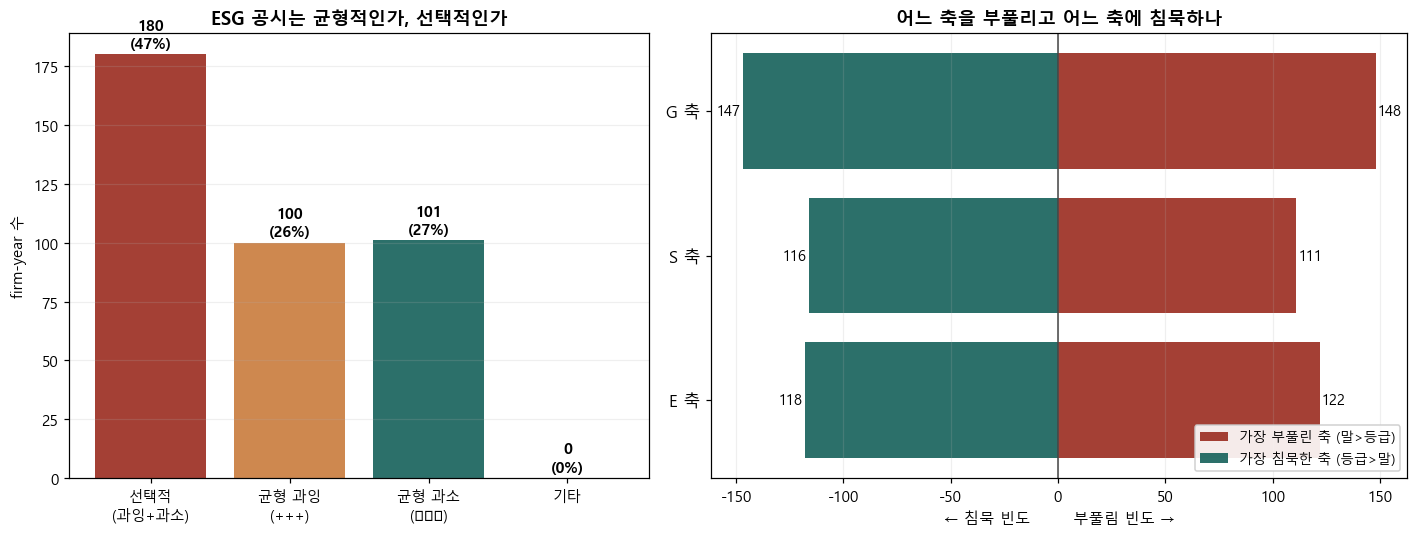

→ 한 축의 막대가 한쪽으로 쏠리면, 한국 기업이 그 축을 체계적으로 부풀리거나(빨강) 침묵하는(청록) 것


In [32]:
"""[시각화] 6-5. 축 간 선택적 공시 — 패턴 분포 + 축별 부풀림/침묵"""
import matplotlib.pyplot as plt   # 한글 폰트는 §0에서 전역 설정됨

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5),
                               gridspec_kw={"width_ratios": [1, 1.2]})

# (좌) 패턴 분포
etc = n - n_sel - n_allover - n_allunder
cats = ["선택적\n(과잉+과소)", "균형 과잉\n(+++)", "균형 과소\n(−−−)", "기타"]
vals = [n_sel, n_allover, n_allunder, max(etc, 0)]
colors = ["#9a2b1f", "#c97b3c", "#15605a", "#c8c2b4"]
ax1.bar(range(4), vals, color=colors, alpha=0.9)
for i, v in enumerate(vals):
    ax1.text(i, v + 1, f"{v}\n({v/n*100:.0f}%)", ha="center", va="bottom",
             fontsize=10, fontweight="bold")
ax1.set_xticks(range(4)); ax1.set_xticklabels(cats, fontsize=9.5)
ax1.set_ylabel("firm-year 수")
ax1.set_title("ESG 공시는 균형적인가, 선택적인가", fontsize=12, fontweight="bold")
ax1.grid(alpha=0.2, axis="y")

# (우) 축별 부풀림(+) / 침묵(−) 다이버징
y = np.arange(3)
ax2.barh(y,  infl.values, color="#9a2b1f", alpha=0.9, label="가장 부풀린 축 (말>등급)")
ax2.barh(y, -sil.values,  color="#15605a", alpha=0.9, label="가장 침묵한 축 (등급>말)")
for i, d in enumerate(dims):
    ax2.text(infl.values[i] + 1, i,  f"{int(infl.values[i])}", va="center", fontsize=9.5)
    ax2.text(-sil.values[i] - 1, i, f"{int(sil.values[i])}", va="center", ha="right", fontsize=9.5)
ax2.axvline(0, color="#444", lw=1)
ax2.set_yticks(y); ax2.set_yticklabels([f"{d} 축" for d in dims], fontsize=11)
ax2.set_xlabel("← 침묵 빈도        부풀림 빈도 →")
ax2.set_title("어느 축을 부풀리고 어느 축에 침묵하나", fontsize=12, fontweight="bold")
ax2.legend(fontsize=9, loc="lower right", framealpha=0.9)
ax2.grid(alpha=0.2, axis="x")

plt.tight_layout()
plt.savefig("outputs/viz_talkwalk_crosspillar.png", dpi=120)
plt.show()
print("→ 한 축의 막대가 한쪽으로 쏠리면, 한국 기업이 그 축을 체계적으로 부풀리거나(빨강) 침묵하는(청록) 것")

**(왼쪽) ESG 공시는 균형적인가, 선택적인가**
- 한 기업-연도가 세 축(E·S·G)을 *고르게* 말하는지, *골라서* 부풀리는지를 분류한 분포다.
- **선택적 180건(47%)**: 한 축은 부풀리고(+) 다른 축은 침묵(−)한다 → 절반 가까이가 ESG를 **골라서** 강조.
- 균형 과잉 100건(26%): 세 축 모두 등급보다 말이 앞섬(+++). 균형 과소 101건(27%): 세 축 모두 말이 등급보다 적음(−−−).
- **'기타' 0건**: 세 축 격차가 정확히 0인 경우만 여기 빠지는데, 연속값이라 사실상 없음 → 모든 firm-year가 선택적·균형과잉·균형과소 중 하나로 깔끔히 분류됐다는 뜻(분류 누락 없음).
- → 균형(과잉+과소) 53%, 선택적 47%로 **거의 절반이 축을 골라 부풀린다.**

**(오른쪽) 어느 축을 부풀리고 어느 축에 침묵하나**
- 각 firm-year에서 *등급 대비 말이 가장 앞선 축*(가장 부풀린 축, 빨강·오른쪽)과 *가장 뒤처진 축*(가장 침묵한 축, 청록·왼쪽)을 하나씩 뽑아, 축별로 몇 번 뽑혔는지 센 것이다. 막대 길이 = 빈도(firm-year 수).
- E: 부풀림 122 · 침묵 118 / S: 부풀림 111 · 침묵 116 / **G: 부풀림 148 · 침묵 147.**
- **한쪽으로의 쏠림이 약하다**: "모두가 환경을 부풀린다" 같은 일방향 편향은 없다(세 축의 부풀림·침묵 빈도가 비슷).
- **G가 가장 양극화된 축**: 부풀림(148)과 침묵(147) 모두 1위 → 거버넌스는 회사마다 **가장 적극적으로 내세우거나 가장 크게 침묵하는** 축. 양 끝으로 갈린다는 의미지, 평균적으로 더 부풀린다는 뜻이 아니다(부풀림≈침묵).
- → 막대가 좌우로 길수록 그 축이 *선택의 대상*이 자주 된다는 뜻. G가 양쪽 모두 가장 길다.

**주의 — 이 그림만으로는 '약점 은폐'인지 알 수 없다**
- 여기서 '부풀린 축'은 **기업 내 상대 비교(argmax)**일 뿐, 그 축이 실제로 약한지 강한지는 보여주지 않는다.
- 부풀린 축이 *약점*(말로 가림)인지 *강점*(정당한 시그널)인지는 **코드 출력 [C]**(부풀린 축의 실제 KCGS 등급 vs 전체 평균)에서 갈린다 — S를 부풀린 기업의 실제 S등급 2.08 ≪ 전체 3.03(약점 은폐), G를 부풀린 기업의 G등급 2.43 > 2.31(강점 신호). **이 그림은 '어느 축을 고르나', [C] 표는 '그 선택이 은폐냐 시그널이냐'를 본다.**

## **6-6. 알파 분석 종합**

**① 유형 분포 (6-2 · 6-3)**
- 유형 분포(381 firm-year): 과잉공시 **72**(18.9%) · 과소공시 **96**(25.2%) · 정합 **119**(31.2%) · 일관저조 **94**(24.7%) → 전체의 **44%가 말과 실행이 어긋난다**.
- 굳어진 성향인가? 127개사 중 **76개사(59.8%)가 3년 내내 같은 칸** → 격차는 그해의 전술이 아니라 **기업에 굳어진 특성**. 구조적 과잉공시 **11개사**, 과소공시 **21개사**.
- 양극단: 과잉공시 1위 **백광산업(3년 연속 D인데 ESG 어휘는 최상위)**, 과소공시 쪽은 **KB·신한·하나·우리·BNK금융지주 등 A+ 대형 지주**.

**② 유형을 가르는 진짜 축은 '수익성'이 아니라 '규모'다 (6-4)**

| 변수 | 과잉공시 | 과소공시 | 정합 | 일관저조 | 집단 간 차이 |
|---|---:|---:|---:|---:|---|
| 수익성 `roa` | 0.014 | 0.019 | 0.023 | 0.021 | H=4.59, **p=0.205 → 차이 없음** |
| 규모 `log_assets` | 27.56 | 29.28 | **30.12** | 26.78 | H=172.0, **p<0.001 → 강한 차이** |
| 분량 `n_tokens` | 2,356 | **5,721** | 4,781 | 2,269 | H=149.4, p<0.001 |
| 부채비율 `leverage` | 0.487 | 0.570 | 0.584 | 0.342 | H=31.1, p<0.001 |

- 수익성은 유형 간 차이가 없다(p=0.21) → **과잉공시는 '부실기업의 변명'이 아니라 '소형주의 상징적 공시' 패턴**.
- 과소공시 = **대형·장문 보고서**(특히 금융지주): 보고서가 길어 ESG 어휘가 *비율상 묻히지만* 등급은 높음 → **실력만큼 ESG를 전면에 못 내세운 소통 격차(IR gap)**.
- **규모 통제 후에도 격차는 살아남았다 (6-4B)**: 길이+규모를 동시에 제거해도 원래 격차와 거의 동일(순위상관 ρ=0.993, 유형 일치율 **90.9%**) → 단순 규모 대리가 아닌 **독립적 정합성 신호**.

**③ ESG는 '전체'가 아니라 '축을 골라' 부풀린다 — 축 간 선택적 공시 (6-5)**

기존 greenwashing 측정은 ESG를 *하나의 점수*로 합쳐 보지만, 여기서는 `gap_E·gap_S·gap_G`를 분해해 **어느 축을 부풀리고 어느 축에 침묵하는지**를 봤다.

- **선택적 공시(한 축 과잉 + 다른 축 과소)가 47.2%(180/381)** — 균형 과잉 26.2% · 균형 과소 26.5%. 즉 절반 가까이가 ESG를 *고르게*가 아니라 *골라서* 부풀린다.
- 특정 축으로의 일방향 쏠림은 약하다(E 부풀림 122·침묵 118 / S 111·116 / G 148·147). **G가 가장 양극화된 축**(부풀림·침묵 모두 1위) — 거버넌스는 회사마다 가장 적극적으로 내세우거나 가장 크게 침묵하는 축.
- **부풀리는 축이 '약점'이냐 '강점'이냐가 갈린다**:

| 부풀린 축 | 그 축의 실제 평균등급 | 전체 평균 | 해석 |
|---|---:|---:|---|
| **S(사회)** | **2.08** | 3.03 | 실제 가장 약한 곳을 가장 크게 부풀림 → **전형적 약점 은폐(cherry-pick)** |
| E(환경) | 2.34 | 2.51 | 약한 곳을 부풀림(약하게) |
| G(지배구조) | 2.43 | 2.31 | 실제 강점을 부각 → **정당한 시그널링(greenwashing 아님)** |

- → **"선택적 공시 = greenwashing"이 아니다.** S·E는 *약점을 말로 가리는* 패턴, G는 *강점을 알리는* 패턴이 공존한다. 단일 ESG 점수로는 결코 보이지 않는 구분이다.
- 축 선택도 구조적: **매년 같은 축을 부풀린 기업 59.1%(75/127)**. 예) 강남제비스코·삼화페인트공업(도료·화학)은 S를 강하게 부풀리고 G/E엔 침묵, 동진쎄미켐은 G를 부풀림.

**④ 유형별·축별 경영 제언**
- **과잉 공시형(소형·저등급)**: 말이 등급을 앞서면 평가기관·규제당국의 **신뢰 할인·greenwashing 점검 리스크**. 수익성은 정상이므로 *역량이 아니라 검증 근거의 부재*가 문제.
  - → 서술을 **검증 가능한 숫자**(배출량·이수율·사외이사 비율)로 뒷받침하라. 구조적 11개사가 우선 점검 대상.
- **과소 공시형(대형·고등급)**: 실력 대비 ESG 언어가 약함 = **알릴 걸 못 알린 손해**(저평가 위험).
  - → 실질 성과를 **별도 ESG 섹션/요약**으로 II·IV·VI에 응집하라. 구조적 21개사(금융지주·CJ·현대건설 등)가 1차 대상.
- **축 편향(6-5) 관점**: 특히 **S축을 부풀리는 기업은 실제 S가 가장 약하다** → 언어가 아니라 *실질 개선*으로 메워야 한다. 반대로 G축 부각은 대체로 실제 강점에 근거하므로 정당하나 과장은 경계.
  - → **평가자·투자자에게**: 종합 ESG 점수만 보면 축 편향을 놓친다. **축별(E/S/G) 말−실행 정합성을 따로 점검**해야 한다.
- **전사 차원**: 격차의 60%가 구조적이고 규모와 연동되며 축을 골라 부풀린다 → "ESG 단어를 많이 쓰면 성과"라는 통념을 반박. 공시 평가는 *양*이 아니라 **검증가능성·정합성**으로, **비슷한 규모끼리·축별로** 보아야 한다.

**⑤ 한계 (요약)**
- 격차는 z-차감이라 '부풀린 축'은 *기업 내 상대 비교*(argmax)이지 절대적 과장이 아니다.
- KCGS 등급은 noisy하고 사업보고서를 평가에 참고한다(동어반복·역인과) → 격차·축 편향은 **진단 신호**일 뿐 인과가 아니다. (전 단계 종합 한계는 §7-5)


---
# **7. 종합 결론**

## **7-1. 연구 질문**
> **사업보고서에 쓴 ESG 표현의 강도가 KCGS ESG 등급과 실제로 연관되는가? 그 연관을 '그냥 길게 쓴 것'(cheap-talk)과 어떻게 구분하는가?**

등급을 *맞히는* 문제가 아니라, **공시 언어와 외부 평가 사이의 패턴을 데이터로 확인**하는 것이 목표였다. (인과가 아닌 연관성.)

## **7-2. 단계별 요약**

| 단계 | 한 일 | 핵심 결과 |
|---|---|---|
| **1. 수집** | 127개사 × 3년 = 381 firm-year 사업보고서 수집·식별자 연결 | lineage 확보, 실패 행은 가짜 0 없이 기록 |
| **2. 전처리** | Kiwi+사용자사전으로 ESG 합성어 보존, 불용어 제거 | seed 보존율 93% |
| **3. Feature** | ESG 어휘강도 점수화 (seed / FastText expanded / 기준문장 cosine) | 의무공시 보편어는 변별력 없어 제외, expanded가 보완 |
| **4. 검증** | 점수와 등급의 순위상관·집단차이 검정 | **분량(보고서 길이)이 어떤 ESG 점수보다 등급과 강하게 연관(ρ≈0.66)** → cheap-talk 경고 |
| **5. 회귀** | 분량·재무 통제 후 등급과의 관계 추정 | **통제 후 끝까지 견고한 신호는 거버넌스(G) 어휘뿐.** E는 규모 착시로 소멸 |
| **6. 알파** | 기업별 말−실행 격차로 유형·지속성·축 편향 진단 | 44% 불일치, 60% 구조적, 규모 통제에도 견고, **47% 축 간 선택적 공시** |

## **7-3. 주요 발견**
1. **공시는 대부분 '양(量)'에 끌려간다.** 등급과 가장 강하게 연관된 것은 ESG의 *내용*이 아니라 보고서 *길이*였다(§4) — 전형적 cheap-talk.
2. **착시를 걷어내면 진짜 신호는 거버넌스(G).** 분량·규모·수익성을 모두 통제해도 등급과 안정적으로 함께 가는 어휘는 거버넌스뿐이었다(§5). 환경 신호의 상당 부분은 '큰 기업이 사업보고서에 환경(E) 관련 단어·서술을 많이/강하게 쓰고 등급도 높다'는 규모 착시였다.
3. **'말과 실력의 정합성'은 기업마다 다르고 굳어진 특성이다.** 등급 대비 말이 앞서는 *과잉 공시형*(주로 소형주)과 실력 대비 말이 적은 *과소 공시형*(주로 대형 지주)이 뚜렷이 갈렸고, 60%가 3년 내내 같은 유형, 규모를 통제해도 유지됐다(§6).
4. **ESG는 '전체'가 아니라 '축을 골라' 부풀린다 (§6-5).** firm-year의 **47%가 한 축은 부풀리고 다른 축은 침묵**하는 선택적 공시였다. 게다가 부풀리는 축이 약점이냐 강점이냐가 갈렸다 — **Social을 부풀린 기업은 실제 S등급이 가장 낮았고(2.08 vs 전체 3.03 → 약점 은폐), Governance를 부풀린 기업은 실제 G등급이 평균 이상(강점 신호)**. ESG를 단일 점수로 합치는 기존 측정이 못 보는 지점으로, **본 분석의 핵심 차별점**이다.

## **7-4. 시사점**
- **기업에게**: ESG 점수를 올리는 길은 *단어를 더 쓰는 것*이 아니라, 과잉형은 *검증 근거로 말을 뒷받침*하고 과소형은 *실력을 제대로 드러내는 것*이다. 특히 **약한 축(S)을 말로 가리지 말고 실질로 개선**해야 한다.
- **평가자·투자자에게**: 공시의 ESG 어휘량을 액면 그대로 믿으면 안 된다. **분량·규모를 보정하고, 비슷한 규모끼리, 그리고 축별(E/S/G)로** 말−실행 정합성을 따로 점검해야 한다.

## **7-5. 한계 (요약 — 단계별 상세는 각 절 결과 셀 참조)**

이 결과는 **"공시 언어와 외부 평가 사이의 패턴"** 이며, 아래 한계 때문에 인과·성과·일반화로 확대 해석하지 않는다.
- **표본**: 381 firm-year는 수업용 pilot로 무작위 대표표본이 아니다 → 모집단 추론 불가.
- **구성타당도**: 측정한 것은 ESG '성과'가 아니라 '언어'다. 명사 위주 bag-of-words라 '배출 증가'와 '감축'을 구분하지 못한다.
- **인과 아님**: 모든 결과는 연관이며, KCGS가 사업보고서를 평가에 참고하므로 동어반복·역인과 위험이 있다.
- **연구자 재량**: seed·θ·max_df 선택에 결과가 조건부다(sweep·분석기 비교로 정당화).
- **추정**: 같은 기업 3년 반복을 pooled로 추정(기업 고정효과·군집 표준오차 미적용) → p-value가 낙관적일 수 있고, 3개 연도뿐이라 지속성 검정력도 약하다.

**후속 과제**: 더 큰 무작위 표본, 기업 고정효과·군집 표준오차, 실제 ESG 성과(배출량·사고·제재) 연결, MSCI 등 복수 평가사로 'walk' 보강, 지속가능경영보고서 확대.

## **7-6. 요약**
> **이 표본에서 ESG 공시 어휘는 등급과 연관되지만 그 상당 부분은 '분량' 착시이며, 이를 걷어내면 거버넌스 어휘만이 견고한 신호로 남는다. 더 나아가 기업들은 ESG를 고르게가 아니라 '축을 골라' 말하는데 — 약한 사회(S)는 말로 가리고 강한 거버넌스(G)는 정당하게 부각하는 — 규모로 환원되지 않는 구조적 정합성·편향이 존재한다.**